In [ ]:
# @title ✅ VERIFY FIXES — run first to confirm Drive has the latest code
# Greps the actual files Colab executes for each fix marker (excludes THIS cell
# so its own marker strings can't mask a missing fix). All green = good to run.
import os, json, datetime
try:
    from google.colab import drive
    if not os.path.exists('/content/gdrive/MyDrive'):
        drive.mount('/content/gdrive')
except Exception:
    pass

BASE  = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG'
NB    = f'{BASE}/Colab Notebooks/notebooks/EEG_Data_Analysis_binary_classification_claude.ipynb'
BRAIN = f'{BASE}/TD_BRAIN_code'

checks = {
    NB: [
        ('confusion_matrix import (real ROC/F1/PR)', 'average_precision_score, confusion_matrix', 2),
        ('Wilcoxon crash fix',                       'pvals.append(p)',                          1),
        ('NaN-proba safety net',                     'nan_to_num',                               1),
        ('cache ENABLED',                            'USE_PREPROCESS_CACHE = True',              1),
        ('GPU banner',                               'good for Group-1 speedup',                 1),
        ('batch-size lock',                          'FIXED for reproducibility',                1),
        ('auto-archive guard',                       'archived previous ',                       1),
        ('launcher path fixed',                      'notebooks/EEG_Data_Analysis_binary',       1),
        ('repro globals() fix (Issue 15)',           'in globals() else',                        2),
        ('best-model checkpointing (Issue 14)',      '_ckpt_best',                               1),
        ('reviewer metrics cell (Issue 10/11)',      'Reviewer metrics',                         1),
        ('saliency cell (Issue 14)',                 'Integrated Gradients',                     1),
        ('LOSO full-cohort CI + errors (Issue 1)',   '_loso_boot_ci',                            1),
        ('pre-flight runtime guard (Issue 1)',       'PRE-FLIGHT',                               1),
        ('Option B Healthy-swap cell (MI2)',         'CONTROL_GROUP',                            1),
        ('CV score-saving for DeLong (MI8)',         'MI8 DeLong',                               1),
        ('DeLong test cell (MI8)',                  '_fast_delong',                             1),
        ('learning curves cell (MI5)',              'Learning curve',                           1),
    ],
    f'{BRAIN}/end2end_alphaPowerandiAPF.py': [
        ('hann -> windows', 'from scipy.signal.windows import hann', 1),
        ('np.int removed',  'int(len(power)/2)',                     1),
    ],
    f'{BRAIN}/BRAIN_code/autopreprocess_pipeline.py': [
        ('missing-eeg-folder guard', 'no eeg folder', 1),
    ],
    f'{BRAIN}/BRAIN_code/autopreprocessing.py': [
        ('empty-Asamps guard', 'if len(Asamps) == 0:', 1),
    ],
}

def read_text(path):
    if path == NB:
        nbj = json.load(open(path, encoding='utf-8'))
        parts = []
        for c in nbj.get('cells', []):
            src = ''.join(c.get('source', []))
            if 'VERIFY FIXES' in src:
                continue
            parts.append(src)
        return '\n'.join(parts)
    return open(path, encoding='utf-8', errors='ignore').read()

all_ok = True
for path, markers in checks.items():
    exists = os.path.exists(path)
    mt = datetime.datetime.utcfromtimestamp(os.path.getmtime(path)).isoformat()+'Z' if exists else 'MISSING'
    print(f'\n{os.path.basename(path)}   (modified {mt})')
    if not exists:
        print('   FILE NOT FOUND'); all_ok = False; continue
    txt = read_text(path)
    for name, needle, want in markers:
        n = txt.count(needle); ok = n >= want; all_ok &= ok
        print(f'   {"OK " if ok else "XX "} {name:<40} found {n} (need >= {want})')

print('\n' + ('ALL FIXES PRESENT - Drive is current.' if all_ok
             else 'SOME FIXES MISSING - Drive not fully synced; wait for the desktop client and re-run this cell.'))


EEG_Data_Analysis_binary_classification_claude.ipynb   (modified MISSING)
   FILE NOT FOUND

end2end_alphaPowerandiAPF.py   (modified MISSING)
   FILE NOT FOUND

autopreprocess_pipeline.py   (modified MISSING)
   FILE NOT FOUND

autopreprocessing.py   (modified MISSING)
   FILE NOT FOUND

SOME FIXES MISSING - Drive not fully synced; wait for the desktop client and re-run this cell.


## Batch Launcher — Run Tasks Across Multiple Runtimes

**Colab Pro (recommended):** Set `TASKS_TO_RUN = [1, 2]` † Run † **close tab** (runtime stays alive) † reopen notebook † set `[3, 4]` † Run. Two runtimes, each writing to the shared `experiment_log.jsonl`.

**Single runtime / free Colab:** Set `TASKS_TO_RUN = [1, 2, 3, 4]` † Run † walk away. Fully unattended sequential execution.

> š  **Standalone cell** — run *only* this cell. Do not run Cells 0—9 individually at the same time.

In [ ]:
# =============================================================================
# BATCH LAUNCHER — Run multiple tasks automatically (unattended)
#
# ─── Choose your approach ────────────────────────────────────────────────────
#
#  A) COLAB PRO — 2 runtimes in parallel (recommended)
#     Pro gives 2 concurrent runtimes; Pro+ gives 3.
#     Step 1: Set TASKS_TO_RUN = [1, 2] here † Run this cell † CLOSE this tab
#             (the runtime keeps running in the background)
#     Step 2: Reopen the notebook in a new tab † set TASKS_TO_RUN = [3, 4]
#             † Run this cell † keep this tab open to monitor progress
#     Both runtimes write to the same experiment_log.jsonl on Drive.
#     After both finish: open any tab † run Cell 8 (Analysis Report).
#
#  B) SINGLE RUNTIME — sequential, fully unattended (free Colab / Pro)
#     Set TASKS_TO_RUN = [1, 2, 3, 4] † run this cell † walk away.
#     Each task runs after the previous one completes.
#     CONTINUE_ON_ERROR=True means a failed task doesn't stop the rest.
#
#  C) VERTEX AI — true 4-way parallel on GCP (see submit_to_vertex.py)
#     Requires a GCP project. Submits each task as a separate managed job.
#
# š   STANDALONE CELL — run ONLY this cell, not Cells 0—9 individually.
#    Papermill drives the full notebook pipeline internally for each task.
# =============================================================================

# —— Which tasks to run in THIS runtime ───────────────────────────────────────
# Pro tip: set [1,2] here, close tab, reopen and set [3,4] † 2 speedup
TASKS_TO_RUN        = [1, 2, 3, 4]   # e.g. [1, 2] for first runtime slot

# —— Shared settings (same for all tasks in this batch) ───────────────────────
BATCH_SMOKE_TEST    = False           # False = full research run
BATCH_MODELS        = [               # models to run across all tasks
    'EEGNet',
    'ShallowConvNet',
    'Deep4Net',
]
# BATCH_N_SUBJECTS    = 20          # subjects per category (None = all available)
BATCH_N_SUBJECTS    = 2             # subjects per category: dry run (None = all available)
BATCH_STRATEGY      = 'class_weight' # imbalance strategy
CONTINUE_ON_ERROR   = True           # skip failed tasks rather than aborting

# —— Per-task overrides (optional) ────────────────────────────────────────────
# Add entries here to customise individual tasks without changing the defaults
TASK_OVERRIDES = {
    # 4: {'BATCH_MODELS': ['EEGNet']},   # example: lighter model for task 4
}

# —— Paths ─────────────────────────────────────────────────────────────────────
import os
GDRIVE_PATH     = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/'
NOTEBOOK_PATH   = GDRIVE_PATH + 'Colab Notebooks/notebooks/EEG_Data_Analysis_binary_classification_claude.ipynb'
OUTPUT_DIR      = GDRIVE_PATH + 'EEG_Analysis_Output/'
EXECUTED_NB_DIR = OUTPUT_DIR + 'executed_notebooks/'
os.makedirs(EXECUTED_NB_DIR, exist_ok=True)

# Auto-archive previous append-only results (prevents cross-run contamination).
# Results are written only at task completion, so archiving at launch never loses
# current-session data; in parallel-tab mode the first tab moves the old files and
# the second (starting seconds later) finds nothing to archive.
import shutil as _shutil, datetime as _dtA
_archive_ts  = _dtA.datetime.utcnow().strftime('%Y%m%d_%H%M%S')
_archive_dir = os.path.join(OUTPUT_DIR, 'archive_' + _archive_ts)
for _stale in ('all_results.csv', 'experiment_log.jsonl'):
    _sp = os.path.join(OUTPUT_DIR, _stale)
    if os.path.exists(_sp):
        try:
            os.makedirs(_archive_dir, exist_ok=True)
            _shutil.move(_sp, os.path.join(_archive_dir, _stale))
            print('  archived previous ' + _stale + ' -> ' + _archive_dir)
        except Exception as _ae:
            print('  archive skipped for ' + _stale + ': ' + str(_ae))

# —— Install papermill ─────────────────────────────────────────────────────────
import subprocess, sys
_r = subprocess.run([sys.executable, '-m', 'pip', 'install', 'papermill', '-q'],
                    capture_output=True, text=True)
print("œ papermill ready" if _r.returncode == 0 else f"pip failed:\n{_r.stderr}")

import papermill as pm
import datetime, traceback

# —— Runtime identity (helps distinguish logs from parallel runtimes) ──────────
RUNTIME_LABEL = f"tasks_{'_'.join(str(t) for t in TASKS_TO_RUN)}"
print(f"\n{'='*70}")
print(f"BATCH  [{RUNTIME_LABEL}] — {len(TASKS_TO_RUN)} task(s)  {len(BATCH_MODELS)} model(s)")
print(f"Smoke  : {BATCH_SMOKE_TEST}   |   Subjects/class: {BATCH_N_SUBJECTS or 'ALL'}")
print(f"{'='*70}\n")

#  Tee stdout  log file
import sys as _sys
class _Tee:
    def __init__(self, *files): self.files = files
    def write(self, d): [(f.write(d), f.flush()) for f in self.files]
    def flush(self):    [f.flush() for f in self.files]
    def isatty(self):   return False

_ts = datetime.datetime.utcnow().strftime('%Y%m%d_%H%M%S')
_task_str = '_'.join(str(t) for t in TASKS_TO_RUN)
_log_path = os.path.join(OUTPUT_DIR, f'run_{_ts}_tasks_{_task_str}.log')
_log_fh   = open(_log_path, 'w', encoding='utf-8')
_orig_stdout = _sys.stdout
_sys.stdout  = _Tee(_orig_stdout, _log_fh)
print(f'Log: {_log_path}')
import logging as _logging
_pm_log = _logging.getLogger('papermill')
_pm_log.setLevel(_logging.INFO)
_pm_h = _logging.StreamHandler(_sys.stdout)
_pm_h.setFormatter(_logging.Formatter('%(message)s'))
_pm_log.handlers = [_pm_h]
#

results_log = []

for task_id in TASKS_TO_RUN:
    t0     = datetime.datetime.utcnow()
    out_nb = os.path.join(EXECUTED_NB_DIR, f'task{task_id}_executed.ipynb')

    params = {
        'TASK_ID'                 : task_id,
        'SMOKE_TEST'              : BATCH_SMOKE_TEST,
        'MODELS_TO_RUN'           : BATCH_MODELS,
        'N_SUBJECTS_PER_CATEGORY' : BATCH_N_SUBJECTS,
        'IMBALANCE_STRATEGY'      : BATCH_STRATEGY,
    }
    params.update(TASK_OVERRIDES.get(task_id, {}))

    print(f"¶  Task {task_id}  ({t0.strftime('%H:%M:%S')} UTC)")
    print(f"   † {out_nb}")

    try:
        pm.execute_notebook(
            NOTEBOOK_PATH, out_nb,
            parameters   = params,
            kernel_name  = 'python3',
            progress_bar = True,
            request_save_on_cell_execute = True,
            log_output   = True,
        )
        elapsed = (datetime.datetime.utcnow() - t0).total_seconds() / 60
        print(f"œ  Task {task_id} complete — {elapsed:.1f} min\n")
        results_log.append({'task_id': task_id, 'status': 'success',
                            'elapsed_min': round(elapsed, 1)})

    except pm.exceptions.PapermillExecutionError as e:
        elapsed = (datetime.datetime.utcnow() - t0).total_seconds() / 60
        print(f"œ  Task {task_id} FAILED after {elapsed:.1f} min — {e.ename}: {e.evalue}")
        results_log.append({'task_id': task_id, 'status': 'failed',
                            'error': str(e.evalue), 'elapsed_min': round(elapsed, 1)})
        if not CONTINUE_ON_ERROR:
            print("   Stopping batch (CONTINUE_ON_ERROR=False).")
            break
        print("   Continuing with next task...\n")

    except Exception as e:
        elapsed = (datetime.datetime.utcnow() - t0).total_seconds() / 60
        print(f"œ  Task {task_id} FAILED (unexpected) after {elapsed:.1f} min: {e}")
        traceback.print_exc()
        results_log.append({'task_id': task_id, 'status': 'failed',
                            'error': str(e), 'elapsed_min': round(elapsed, 1)})
        if not CONTINUE_ON_ERROR:
            break

# —— Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"BATCH COMPLETE  [{RUNTIME_LABEL}]")
print(f"{'='*70}")
for r in results_log:
    icon = "œ" if r['status'] == 'success' else "œ"
    err  = f"  † {r['error'][:60]}" if r.get('error') else ""
    print(f"  {icon} Task {r['task_id']}  {r['elapsed_min']:>6.1f} min  {r['status']}{err}")

total = sum(r['elapsed_min'] for r in results_log)
ok    = sum(1 for r in results_log if r['status'] == 'success')
print(f"\n  {ok}/{len(results_log)} tasks succeeded  |  Total: {total:.1f} min ({total/60:.1f} hr)")
print(f"\n  Experiment log : {OUTPUT_DIR}experiment_log.jsonl")
print(f"  Executed nbs   : {EXECUTED_NB_DIR}")
import json as _json_x
for _tid in TASKS_TO_RUN:
    _enb = os.path.join(EXECUTED_NB_DIR, f'task{_tid}_executed.ipynb')
    if not os.path.exists(_enb): continue
    try:
        _nbj = _json_x.load(open(_enb, encoding='utf-8'))
        _buf = []
        for _cc in _nbj.get('cells', []):
            for _oo in _cc.get('outputs', []):
                if _oo.get('output_type') == 'stream': _buf.append(''.join(_oo.get('text', [])))
                elif _oo.get('output_type') == 'error':
                    for _t in _oo.get('traceback', []): _buf.append(_t)
        with open(os.path.join(OUTPUT_DIR, f'task{_tid}.log'), 'w', encoding='utf-8') as _wf: _wf.write(''.join(_buf))
        print(f'  task {_tid} log extracted -> task{_tid}.log')
    except Exception as _e: print(f'  log extract failed task {_tid}: {_e}')
try:
    _sys.stdout = _orig_stdout
    _log_fh.flush(); _log_fh.close()
    print(f'  Console log saved: {_log_path}')
except Exception: pass
print(f"\n  ¶ Open any tab and run Cell 8 (Analysis Report) to review all results.")


/tmp/ipykernel_4694/779252828.py:62: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  _archive_ts  = _dtA.datetime.utcnow().strftime('%Y%m%d_%H%M%S')


œ papermill ready

BATCH  [tasks_1_2_3_4] — 4 task(s)  3 model(s)
Smoke  : False   |   Subjects/class: 2

Log: /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/run_20260905_171541_tasks_1_2_3_4.log
¶  Task 1  (17:15:41 UTC)
   † /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/executed_notebooks/task1_executed.ipynb
Input Notebook:  /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/Colab Notebooks/notebooks/EEG_Data_Analysis_binary_classification_claude.ipynb


/tmp/ipykernel_4694/779252828.py:98: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  _ts = datetime.datetime.utcnow().strftime('%Y%m%d_%H%M%S')
/tmp/ipykernel_4694/779252828.py:116: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  t0     = datetime.datetime.utcnow()
INFO:papermill:Input Notebook:  /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/Colab Notebooks/notebooks/EEG_Data_Analysis_binary_classification_claude.ipynb


Output Notebook: /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/executed_notebooks/task1_executed.ipynb


INFO:papermill:Output Notebook: /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/executed_notebooks/task1_executed.ipynb


...

INFO:papermill:WARNING:papermill:WARNING:papermill:INFO:papermill:Passed unknown parameter: IMBALANCE_STRATEGY










INFO:papermill:INFO:papermill:WARNING:papermill:WARNING:papermill:INFO:papermill:Passed unknown parameter: IMBALANCE_STRATEGY










INFO:papermill:WARNING:papermill:WARNING:papermill:WARNING:papermill:INFO:papermill:Passed unknown parameter: IMBALANCE_STRATEGY










INFO:papermill:WARNING:papermill:WARNING:papermill:WARNING:papermill:INFO:papermill:Passed unknown parameter: IMBALANCE_STRATEGY










INFO:papermill:WARNING:papermill:WARNING:papermill:WARNING:papermill:WARNING:papermill:INFO:papermill:Passed unknown parameter: IMBALANCE_STRATEGY










In [ ]:
from google.colab import files
uploaded = files.upload()
# Upload all 4: task1_loso.csv, task2_loso.csv, task3_loso.csv, task4_loso.csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base = "/content/drive/MyDrive/01_Reasearch/01_Neuro_EEG/EEG_Analysis_Output/00_Final_Results_0816/_vs_Healthy_2/"

In [ ]:
import pandas as pd
import numpy as np

base = "/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/"  # adjust to your Drive path

loso_files = {
    1: base + "task1_loso.csv",
    2: base + "task2_loso.csv",
    3: base + "task3_loso.csv",
    4: base + "task4_loso.csv",
}

task_names = {1:"OCD vs. Healthy", 2:"MDD vs. Healthy",
              3:"ADHD vs. Healthy", 4:"OCD vs. MDD"}

rng = np.random.default_rng(42)
N_BOOT = 9999

for task_id, path in loso_files.items():
    df = pd.read_csv(path)
    c0 = df[df.true_label==0].correct.values
    c1 = df[df.true_label==1].correct.values

    # Bootstrap balanced accuracy
    s0 = rng.choice(c0, size=(N_BOOT, len(c0)), replace=True).mean(axis=1)
    s1 = rng.choice(c1, size=(N_BOOT, len(c1)), replace=True).mean(axis=1)
    boot = (s0 + s1) / 2

    bal_acc = (c0.mean() + c1.mean()) / 2
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

    print(f"Task {task_id} ({task_names[task_id]}):")
    print(f"  N subjects: {len(df)}  (label 0: {len(c0)}, label 1: {len(c1)})")
    print(f"  LOSO balanced accuracy: {bal_acc:.4f} (95% CI: {ci_lo:.4f}–{ci_hi:.4f})")
    print(f"  Sensitivity (label 0): {c0.mean():.4f}   Specificity (label 1): {c1.mean():.4f}")
    print()

FileNotFoundError: [Errno 2] No such file or directory: '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/task1_loso.csv'

Run first:

In [ ]:
from google.colab import drive
try:
    drive.flush_and_unmount()
except Exception:
    pass
!fusermount -u /content/gdrive 2>/dev/null
!rm -rf /content/gdrive
drive.mount('/content/gdrive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/gdrive


In [ ]:
import shutil, sys, os

!pip install -q mne braindecode scikit-learn imbalanced-learn pandas matplotlib seaborn

local_path = '/content/src'
if os.path.exists(local_path):
    shutil.rmtree(local_path)
shutil.copytree(
    '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/Colab Notebooks/src',
    local_path
)
sys.path.insert(0, '/content')
print("Copied. Trying import...")

from src.preprocessing.eeg_dl_preprocess_tdbrain import preprocess_tdbrain_with_official_pipeline
print("Success!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 156.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.2/679.2 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 19.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
Copied. Trying import...
config.py updated with corrected NOTCH_FREQS.
eeg_loader_FIXED.py loaded with flexible column detection!
Success!


In [ ]:
from braindecode.models import EEGConformer
import torch
model = EEGConformer(n_chans=26, n_outputs=2, n_times=500)
total = sum(p.numel() for p in model.parameters())
print(f'EEG-Conformer parameters: {total:,}')

## Cell 0: Central Configuration
Change `TASK_ID` here to switch tasks. Everything else adapts automatically.

In [ ]:
import os

GDRIVE_PATH         = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/'
GDRIVE_OUTPUT_PATH  = GDRIVE_PATH + 'EEG_Analysis_Output/'
OUTPUT_PATH         = GDRIVE_OUTPUT_PATH

os.makedirs(OUTPUT_PATH, exist_ok=True)
print(os.listdir(OUTPUT_PATH))

In [ ]:
import pandas as pd, os
df = pd.read_csv(os.path.join(OUTPUT_PATH, 'all_results.csv'))
pivot = df.groupby(['task_id','model'])['roc_auc'].mean().unstack().round(3)
print(pivot.to_string())
print("\nMean per task:")
print(pivot.mean(axis=1).round(3))

FileNotFoundError: [Errno 2] No such file or directory: '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/all_results.csv'

In [1]:
# =============================================================================
# CENTRAL CONFIGURATION  † Only cell you need to edit between runs
# =============================================================================

# —— Run mode ─────────────────────────────────────────────────────────────────
# Set SMOKE_TEST = True for minimal end-to-end validation (fast, ~5 min on CPU)
# Set SMOKE_TEST = False for full research runs
SMOKE_TEST = False  # † FULL RUN: set True only for quick end-to-end checks

# —— Quick scan mode ──────────────────────────────────────────────────────────
# QUICK_SCAN = True  † single stratified holdout (75/25 subject split), no LOSO
#                       ~6 min/task (vs ~8.5 hr for full pipeline at 100 subjects/class)
#                       Use to check whether any model detects signal before committing
#                       to the full 5-fold + LOSO run.
# QUICK_SCAN = False † full GroupKFold + LOSO pipeline (publication-ready)
QUICK_SCAN          = False   # False = full 5-fold + LOSO pipeline
QUICK_SCAN_EPOCHS   = 20    # max epochs in quick scan — log shows best_epoch never exceeded 5
QUICK_SCAN_PATIENCE = 10    # early-stop patience in quick scan
QUICK_SCAN_TEST_SIZE= 0.25  # fraction of subjects held out for evaluation

# —— SKIP_LOSO mode ───────────────────────────────────────────────────────────
# True  † KFold CV only, no LOSO  (intermediate mode between QUICK_SCAN & full)
#          ~2—15 min/task on GPU  (vs ~45 min full with sampled LOSO)
#          Use after QUICK_SCAN confirms a signal, before committing to LOSO.
# False † run full LOSO after KFold  (requires QUICK_SCAN=False)
SKIP_LOSO           = True

# —— LOSO_SAMPLE_SIZE — stratified sampling to speed up LOSO ──────────────────
# None = use ALL subjects (publication-quality, slow on CPU)
# 20   = 20 subjects/class † 40 LOSO folds  (~3 faster,  0.04 AUC vs full)
# 10   = 10 subjects/class † 20 LOSO folds  (~7 faster,  0.08 AUC vs full)
# Subjects are stratified-sampled by class; seed = RANDOM_STATE (reproducible).
LOSO_SAMPLE_SIZE    = None    # 20/class † 40 LOSO iterations ‰ˆ 30 min/task on T4
                            # None = all subjects (can be 100s of hours for large tasks)
                            # Use None only after LOSO_SAMPLE_SIZE=20 confirms signal

# —— LOSO model ensemble ──────────────────────────────────────────────────────
# Models to use for LOSO evaluation — ensemble by soft-vote (average probas).
# EEGTCNet + EEG_Conformer are consistently top-2 across Tasks 2—4.
# Models not in MODELS_TO_RUN will still be trained at LOSO time.
LOSO_MODELS = ['EEGTCNet', 'EEG_Conformer']

# —— Task 4 age-matching ───────────────────────────────────────────────────────
# Task 4 (OCD vs MDD): confirmed age confound — OCD mean=34.2, MDD mean=42.9,
# Cohen d=0.678, p<0.001. Trim both groups to overlapping age range to remove
# age as a confound. Reduces n but produces a controlled comparison.
# True = filter; False = use all subjects (original, confounded behaviour).
TASK4_AGE_MATCH = True

# —— Preprocessing cache ───────────────────────────────────────────────────────
# Set USE_PREPROCESS_CACHE = True after running eeg_preprocess_cache_builder.py
# once on the full dataset. This skips the 25—60 min preprocessing pipeline by
# loading pre-saved .npz files from NPZ_CACHE_DIR instead.
#
# Cache builder script: Colab Notebooks/eeg_preprocess_cache_builder.py
# Run it once (all subjects, ~1.5—3 h), then flip this flag to True.
#
# USE_PREPROCESS_CACHE = False † run preprocessing normally (safe default)
# USE_PREPROCESS_CACHE = True  † load from cache (fast, requires cache to exist)
USE_PREPROCESS_CACHE = True   # † set True after eeg_preprocess_cache_builder.py run

# Directory containing {OCD,MDD,ADHD,SMC}_cache.npz  and  cache_manifest.json
# Must match CACHE_DIR in eeg_preprocess_cache_builder.py
NPZ_CACHE_DIR = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/preprocess_cache/'

# —— Task selection (Table 3 from research scope) ──────────────────────────────
# 1 = OCD  vs. SMC (Healthy Controls)   (core OCD biomarker benchmark)
# 2 = MDD  vs. SMC (Healthy Controls)   (frontal alpha asymmetry)
# 3 = ADHD vs. SMC (Healthy Controls)   (theta-beta ratio)
# 4 = OCD  vs. MDD                      (transdiagnostic differential)
# 5 = OCD  vs. ADHD                     (high comorbidity overlap)
# 6 = MDD  vs. ADHD                     (frequent misdiagnosis)
# —— Multi-task configuration ─────────────────────────────────────────────────
# TASKS_TO_RUN: which tasks to execute in the Multi-Task Loop cell.
# To run a single task manually (Cells 2—7), just set TASK_ID below.
TASKS_TO_RUN = [1, 2, 3, 4]   # tasks to execute when running Multi-Task Loop
# TASKS_TO_RUN = [1]   # sks to execute when running Multi-Task Loop

TASK_ID = 1   # used only when running individual Cells 2—7 manually

# —— Models to run (Table 4 priority order) ───────────────────────────────────
# Comment out models to skip; first entry runs first
MODELS_TO_RUN = [
    'EEGNet',           # Priority 1 — compact CNN baseline (fastest)
    'ShallowConvNet',   # Priority 2 — FBCSP-inspired
    'Deep4Net',         # Priority 3 — 4-block deep CNN
    'EEG_Conformer',    # Priority 4 — CNN + Transformer
    'EEGTCNet',         # Priority 5 — CNN + TCN
    # 'FBCNet',         # Priority 6 — filter bank CNN  (enable when available)
    # 'EEGMiner',       # Priority 7 — interpretable    (enable when available)
    # 'BIOT',           # Priority 8 — foundation model (enable when available)
]

# —— Class imbalance strategy ─────────────────────────────────────────────────
# 'class_weight' — inverse frequency weighting in CrossEntropyLoss (recommended start)
# 'focal_loss'   — down-weights easy majority samples
# 'smote'        — synthetic minority oversampling
IMBALANCE_STRATEGY = 'class_weight'

# —— Training hyperparameters ──────────────────────────────────────────────────
N_FOLDS            = 5      # GroupKFold folds (strict subject-level) — overridden to 2 in SMOKE_TEST
MAX_EPOCHS         = 60     # per fold; warmup(5)+cosine decays fully within 60 ep — 200 was wasted budget
BATCH_SIZE         = 256   # FIXED for reproducibility: changing this moves ALL reported numbers (Group 2). Keep constant across GPUs; only lower if OOM.
LEARNING_RATE      = 1e-3   # global fallback; per-model values in PER_MODEL_OVERRIDES
WEIGHT_DECAY       = 1e-4   # global fallback; literature uses 0—1e-4 (see PER_MODEL_OVERRIDES)
EARLY_STOP_PATIENCE= 8      # epochs without improvement; 8 lets warmup settle (5 ep) + 3 post-peak checks without over-extending
                             # log analysis: best_epoch avg=2.4; warmup+cosine schedule now needs patience‰¥15

# —— Per-model hyperparameter overrides ───────────────────────────────────────
# Derived from original papers and braindecode reproduction benchmarks.
# These replace the global LEARNING_RATE / WEIGHT_DECAY for each model.
# Literature sources:
#   EEGNet        — Lawhern et al. 2018 (J. Neural Eng.): Adam defaults, no WD
#   ShallowConvNet— Schirrmeister et al. 2017 (HBM): originally AdaGrad;
#                   Adam repros (braindecode, Gemein et al. 2020) use lr‰ˆ6.25e-4
#   Deep4Net      — same paper/setting as ShallowConvNet
#   EEGConformer  — Song et al. 2022: transformer blocks need lower LR + mild WD;
#                   lr=1e-4 prevents attention-head collapse, wd=1e-4 for stability
#   EEGTCNet      — Ingolfsson et al. 2020: Adam 1e-3, no WD (same regime as EEGNet)
#   FBCNet        — Wang et al. 2022: Adam 1e-3, no WD
# None = fall back to global LEARNING_RATE / WEIGHT_DECAY
PER_MODEL_OVERRIDES = {
    'EEGNet':         {'lr': 1e-3,    'wd': 0.0  },   # Lawhern 2018 Adam defaults
    'ShallowConvNet': {'lr': 6.25e-4, 'wd': 0.0  },   # Schirrmeister 2017 / Gemein 2020
    'Deep4Net':       {'lr': 6.25e-4, 'wd': 1e-4 },   # added wd=1e-4: 4-block depth needs regularisation on small per-fold N
    'EEG_Conformer':  {'lr': 1e-4,    'wd': 1e-4 },   # Song 2022 — transformer stability
    'EEGTCNet':       {'lr': 1e-3,    'wd': 0.0  },   # Ingolfsson 2020
    'FBCNet':         {'lr': 1e-3,    'wd': 0.0  },   # Wang 2022
}

# —— LR Finder (auto-calibration) ─────────────────────────────────────────────
# Implements Leslie Smith's LR Range Test (arXiv:1506.01186).
# When LR_FINDER_ENABLED=True, sweeps LR over LR_FINDER_STEPS mini-batches on
# fold-0 data before the full training loop, then overrides PER_MODEL_OVERRIDES.
# Adds ~30—60 s per model per task but finds the optimal LR for your exact data.
LR_FINDER_ENABLED  = False    # True = auto-tune; False = use PER_MODEL_OVERRIDES
                             # Recommended: enable for Task 3 (ADHD) to explore LR space around 1e-3
LR_FINDER_MIN      = 1e-6    # LR sweep start
LR_FINDER_MAX      = 1e-1    # LR sweep end
LR_FINDER_STEPS    = 100     # mini-batches to sweep

TARGET_SFREQ       = 250    # Hz — resample all data to this
WINDOW_DURATION_SEC= 2.0    # seconds
RANDOM_STATE       = 42

# —— Dataset limits ────────────────────────────────────────────────────────────
# None = use all available subjects (full research run)
# 1    = smallest possible end-to-end smoke test (overridden below if SMOKE_TEST=True)
N_SUBJECTS_PER_CATEGORY = 75    # † recommended minimum for reliable results
# N_SUBJECTS_PER_CATEGORY = 25    # † recommended minimum for reliable results
# Œ— Subject count guide ──────────────────────────────────────────────────────
# ‚ Why not None? With None, preprocessing extracts all subjects from ZIP     ‚
# ‚ (~345 for Task 2). At ~10 s/subject = 58 min just for preprocessing.      ‚
# ‚ n=75: preprocess 150 subjects † ~25 min first run, fast on cached runs.   ‚
# ‚       Each KFold fold has ~60 train / ~15 val subjects — adequate power.  ‚
# ‚ n=50: works but lower power; AUC may be 3—5 points below full-data run.  ‚
# ‚ n=30: minimum viable — only if Colab CPU (no T4) or very tight on time.  ‚
# ‚ None: use only if preprocessed CSVs are already cached on GDrive.        ‚
# ────────────────────────────────────────────────────────────────────────────˜


# —— Runtime / GPU guard ───────────────────────────────────────────────────────
# REQUIRE_GPU = True  † raise an error and stop if no GPU is detected.
#                       Prevents silent multi-hour CPU runs.
# REQUIRE_GPU = False † warn but continue (useful on local machines with no GPU).
REQUIRE_GPU = True

import torch as _torch
_device_type = 'cuda' if _torch.cuda.is_available() else 'cpu'
if _device_type == 'cuda':
    _gpu_name = _torch.cuda.get_device_name(0)
    print(f"\033[92mœ GPU detected: {_gpu_name}\033[0m")
    if 'T4' not in _gpu_name and 'A100' not in _gpu_name and 'V100' not in _gpu_name:
        print(f"\033[93mš  GPU is {_gpu_name} — expected T4. Training will still run but may be slower.\033[0m")
else:
    _msg = (
        "\n\033[91m\033[1m" + ""*68 + "\033[0m\n"
        "\033[91m\033[1m  › No GPU detected — runtime is CPU\033[0m\n"
        "\033[93m  This will make each task take 7—17 hours instead of ~90 min.\033[0m\n"
        "\033[93m  †³ Fix: Runtime † Change runtime type † Hardware accelerator † T4 GPU\033[0m\n"
        "\033[93m  †³ Then: Runtime † Run all  (re-run from the top)\033[0m\n"
        "\033[91m" + ""*68 + "\033[0m\n"
    )
    print(_msg)
    if REQUIRE_GPU:
        raise RuntimeError(
            "No GPU found. Set REQUIRE_GPU = False to override and run on CPU (very slow), "
            "or switch to a T4 GPU runtime via Runtime † Change runtime type."
        )
del _torch, _device_type

# -- Issue 10: model parameter counts (run once after Cell 8 is loaded)
# print({m: sum(p.numel() for p in build_model(m,26,500).parameters()) for m in MODELS_TO_RUN})

# —— Internal: task † category mapping (do not edit) ─────────────────────────
TASK_CATEGORIES = {
    1: ('OCD',  'Healthy'),     # SMC = Subjective Memory Complaints (healthy controls in TDBRAIN)
    2: ('MDD',  'Healthy'),
    3: ('ADHD', 'Healthy'),
    4: ('OCD',  'MDD'),
    5: ('OCD',  'ADHD'),
    6: ('MDD',  'ADHD'),
}
TASK_NAMES = {
    1: 'OCD vs. Healthy',
    2: 'MDD vs. Healthy',
    3: 'ADHD vs. Healthy',
    4: 'OCD vs. MDD',
    5: 'OCD vs. ADHD',
    6: 'MDD vs. ADHD',
}

# —— Per-task model hyperparameter overrides ──────────────────────────────────
# Extends PER_MODEL_OVERRIDES for specific tasks where defaults are suboptimal.
# Format: {task_id: {model_name: {param: value, ...}}}
# Applied in Cell 7 stage_train() if TASK_ID matches.
TASK_MODEL_OVERRIDES = {
    1: {
        # Deep4Net collapses on Task 1 (OCD, fewest subjects) with wd=1e-4.
        # Stronger regularisation stabilises 4-block depth on small folds.
        'Deep4Net': {'wd': 1e-3, 'lr': 5e-4},  # lr halved: wd alone insufficient, model stops at ep 1-3 on small folds
    },
}

# —— Smoke-test overrides ──────────────────────────────────────────────────────
if SMOKE_TEST:
    N_SUBJECTS_PER_CATEGORY = 10  # 1 subject per class † smallest possible dataset
    N_FOLDS                 = 2   # minimum GroupKFold folds (needs ‰¥2 subjects total)
    MAX_EPOCHS              = 3   # just enough to confirm training loop runs
    EARLY_STOP_PATIENCE     = 2
    MODELS_TO_RUN           = ['EEGNet']   # fastest model only
    SKIP_LOSO               = True        # LOSO meaningless at 1-subject scale
    print("š¡ SMOKE TEST MODE — minimal data, 1 model, 3 epochs")
    print("   Switch SMOKE_TEST = False for full research runs.")

assert TASK_ID in TASK_CATEGORIES, f"TASK_ID must be 1-6, got {TASK_ID}"  # single-task mode only
CAT_A, CAT_B = TASK_CATEGORIES[TASK_ID]

print(f"{'='*70}")
print(f"TASK {TASK_ID}: {TASK_NAMES[TASK_ID]}")
print(f"  Class A : {CAT_A}  (label=0)")
print(f"  Class B : {CAT_B}  (label=1)")
print(f"  Models  : {MODELS_TO_RUN}")
print(f"  Subjects/class : {N_SUBJECTS_PER_CATEGORY or 'ALL'}")
print(f"  Imbalance strategy : {IMBALANCE_STRATEGY}")
print(f"  CV folds: {N_FOLDS}  |  Max epochs: {MAX_EPOCHS}  |  Target sfreq: {TARGET_SFREQ} Hz")
print(f"{'='*70}")


œ GPU detected: NVIDIA L4
š  GPU is NVIDIA L4 — expected T4. Training will still run but may be slower.
TASK 1: OCD vs. Healthy
  Class A : OCD  (label=0)
  Class B : Healthy  (label=1)
  Models  : ['EEGNet', 'ShallowConvNet', 'Deep4Net', 'EEG_Conformer', 'EEGTCNet']
  Subjects/class : 75
  Imbalance strategy : class_weight
  CV folds: 5  |  Max epochs: 60  |  Target sfreq: 250 Hz


In [ ]:
import sys
sys.path.insert(0, '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/Colab Notebooks')
from src.preprocessing.eeg_dl_preprocess_tdbrain import preprocess_tdbrain_with_official_pipeline

ModuleNotFoundError: No module named 'src'

## Cell 1: Setup — Install Libraries, Mount Drive, Load Modules

In [2]:
# =============================================================================
# Cell 1: Setup — install, mount Google Drive, define paths, load modules
# =============================================================================

!pip install -q mne braindecode scikit-learn imbalanced-learn pandas matplotlib seaborn

import os, sys, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

# —— Logging config ────────────────────────────────────────────────────────────
import warnings, logging

# MNE is very chatty — INFO messages fire once per window inside create_from_X_y
# (e.g. "Creating RawArray with float64 data, n_channels=26, n_times=500").
# Two calls are needed: mne.set_log_level() controls MNE's own print system;
# logging.getLogger() covers the Python logging handler MNE also writes to.
import mne
mne.set_log_level('WARNING')
logging.getLogger('mne').setLevel(logging.WARNING)

# Braindecode uses MNE internally — same treatment.
logging.getLogger('braindecode').setLevel(logging.WARNING)

# Python warnings: show all warnings once (default behaviour).
# Cell 7 overrides specific noisy categories only — everything else stays visible.
warnings.filterwarnings('default')

# —— Paths ─────────────────────────────────────────────────────────────────────
GDRIVE_PATH         = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/'
GDRIVE_OUTPUT_PATH  = GDRIVE_PATH + 'EEG_Analysis_Output/'
GDRIVE_COLAB_PATH   = GDRIVE_PATH + 'Colab Notebooks'
TDBRAIN_CODE_PATH   = GDRIVE_PATH + 'TD_BRAIN_code'
sys.path.append(TDBRAIN_CODE_PATH) # Added: Add TD_BRAIN_code to system path
TDBRAIN_ZIP_PATH    = '/content/gdrive/MyDrive/TD_Brain_Derived_Dataset/TDBRAIN-dataset-derivatives.zip'
PARTICIPANTS_TSV    = '/content/gdrive/MyDrive/TD_Brain_Dataset/participants.tsv'
OUTPUT_PATH         = GDRIVE_OUTPUT_PATH

os.makedirs(OUTPUT_PATH, exist_ok=True)

from google.colab import drive
try:
    drive.flush_and_unmount()
except Exception:
    pass
!fusermount -u /content/gdrive 2>/dev/null
!rm -rf /content/gdrive
drive.mount('/content/gdrive')

import sys
sys.path.insert(0, '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/Colab Notebooks')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.2/679.2 kB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 20.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Mounted at /content/gdrive


## Multi-Task Loop — Run All Tasks Sequentially (No Restart Needed)

Run **Cell 1 (Setup)** first, then run **only this cell**.
It executes the full pipeline (preprocess † merge † imbalance † train † LOSO † save) for every task in `TASKS_TO_RUN`, saving separate result files per task.

After completion, run **Cell 8 (Analysis Report)** for the cross-task comparison.

> „¹ï¸ **Individual Cells 2—7** remain available for step-by-step debugging of a single task. Set `TASK_ID` in Cell 0 and run them as before.

In [3]:
# @title Setup — Imports, Device & Logging (run once)
# =============================================================================
# Multi-Task Loop — Run all tasks sequentially in one shot
#
# Usage:  Run Cell 1 (Setup) first, then run THIS cell only.
#         Individual Cells 2—7 are for manual debugging; skip them here.
#
# After all tasks complete, run Cell 8 (Analysis Report) for cross-task view.
# =============================================================================

import os, json as _json, datetime as _dt, warnings, math
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                              f1_score, average_precision_score, confusion_matrix)
from scipy.signal import resample as scipy_resample
from collections import Counter
import inspect, traceback
# Suppress only known noisy-but-harmless categories; all others remain visible.
warnings.filterwarnings('ignore', category=FutureWarning)          # numpy/sklearn API churn
warnings.filterwarnings('ignore', category=DeprecationWarning)     # braindecode internal
warnings.filterwarnings('ignore', message='.*n_fft.*')             # scipy signal edge cases
warnings.filterwarnings('ignore', message='.*divide by zero.*')    # empty-fold edge case
warnings.filterwarnings('ignore', message='.*invalid value.*')     # NaN in metric edge case
# Suppress sklearn per-subject LOSO metrics warnings (single-class prediction
# is expected for some subjects with very few windows — handled in metrics code)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', message='.*Only one class is present.*')
warnings.filterwarnings('ignore', message='.*No positive class found.*')
warnings.filterwarnings('ignore', message='.*single label was found.*')
warnings.filterwarnings('ignore', message='.*y_pred contains classes not in y_true.*')
# UserWarning (non-sklearn), RuntimeWarning, and all others are shown as normal

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True   # auto-tune cuDNN kernels for fixed input shapes (EEG windows are constant size)
    _gname = torch.cuda.get_device_name(0)
    _gvram = torch.cuda.get_device_properties(0).total_memory / 1e9
    _gfast = any(g in _gname for g in ('A100', 'L4', 'V100', 'A10', 'H100'))
    _bs = BATCH_SIZE if 'BATCH_SIZE' in dir() else '?'
    print(f'  GPU : {_gname}  ({_gvram:.0f} GB)  |  AMP on  |  batch={_bs}')
    print('  ' + ('fast GPU - good for Group-1 speedup' if _gfast else 'standard T4 - pick L4/A100 in Runtime > Change runtime type for 1.5-3x'))

# —— Logging helpers ───────────────────────────────────────────────────────────
_C = {
    'ok'   : '\033[92m',   # green
    'warn' : '\033[93m',   # yellow
    'error': '\033[91m',   # red
    'head' : '\033[96m',   # cyan
    'reset': '\033[0m',
    'bold' : '\033[1m',
}

def _log(msg, level='info', indent=2):
    pad = ' ' * indent
    icons = {'ok': '✔', 'warn': '⚠', 'error': '⛔', 'skip': '↷', 'info': '·'}
    colours = {'ok': _C['ok'], 'warn': _C['warn'], 'error': _C['error'],
               'skip': _C['warn'], 'info': '·', 'head': _C['head']}
    col = colours.get(level, '')
    icon = icons.get(level, ' ')
    print(f"{pad}{col}{icon} {msg}{_C['reset']}")

# —— Reproducibility: software versions + hardware (Issue 15) ─────────────────
import importlib.metadata as _imeta
SW_VERSIONS = {}
for _pkg in ['torch', 'braindecode', 'mne', 'scikit-learn', 'numpy', 'scipy']:
    try:    SW_VERSIONS[_pkg] = _imeta.version(_pkg)
    except: SW_VERSIONS[_pkg] = 'unknown'
HARDWARE = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f"  SW : {SW_VERSIONS}")
print(f"  HW : {HARDWARE}")

def _log_error(title, detail=None, hint=None):
    """Visually distinct error block — stands out from normal output."""
    W = 68
    print(f"\n{_C['error']}{_C['bold']}{''*W}{_C['reset']}")
    print(f"{_C['error']}{_C['bold']}  › {title}{_C['reset']}")
    if detail:
        for line in str(detail).split('\n'):
            print(f"{_C['error']}     {line}{_C['reset']}")
    if hint:
        print(f"{_C['warn']}  †³  {hint}{_C['reset']}")
    print(f"{_C['error']}{''*W}{_C['reset']}\n")

def _log_task_header(task_id, task_name, cat_a, cat_b, t0):
    print(f"\n{_C['head']}{_C['bold']}{''*68}{_C['reset']}")
    print(f"{_C['head']}{_C['bold']}  TASK {task_id}: {task_name}{_C['reset']}")
    print(f"{_C['head']}  {cat_a} (0) vs {cat_b} (1)  |  {t0.strftime('%H:%M:%S')} UTC{_C['reset']}")
    print(f"{_C['head']}{''*68}{_C['reset']}")

def _log_task_done(task_id, elapsed_min, agg):
    print(f"\n{_C['ok']}{_C['bold']}  œ TASK {task_id} COMPLETE — {elapsed_min:.1f} min{_C['reset']}")
    if agg is not None and not agg.empty and 'model' in agg.columns:
        cols = ['model','bal_acc_mean','roc_auc_mean','f1_mean','pr_auc_mean']
        print(agg[cols].to_string(index=False))

def _log_fold(fi, n_folds, n_tr_win, n_tr_s, n_va_win, n_va_s):
    print(f"    Fold {fi+1}/{n_folds} | "
          f"train {n_tr_win}w/{n_tr_s}s  val {n_va_win}w/{n_va_s}s", end=' ')

def _log_step(step, total, label):
    print(f"\n{_C['bold']}  [{step}/{total}] {label}{_C['reset']}")




  GPU : NVIDIA L4  (24 GB)  |  AMP on  |  batch=256
  fast GPU - good for Group-1 speedup
  SW : {'torch': '2.11.0+cu128', 'braindecode': '1.8.1', 'mne': '1.12.1', 'scikit-learn': '1.6.1', 'numpy': '2.1.3', 'scipy': '1.16.3'}
  HW : NVIDIA L4


In [4]:
# @title Pipeline Functions — Stage definitions (run once to load)
# PIPELINE FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def _get_dataset_info(windows_dataset, n_channels):
    sfreq = TARGET_SFREQ
    ch_names = [f'ch_{i}' for i in range(n_channels)]
    if not hasattr(windows_dataset, 'datasets') or not windows_dataset.datasets:
        return sfreq, ch_names
    first = windows_dataset.datasets[0]
    for attr in ('windows', 'raw'):
        if hasattr(first, attr):
            try:
                info = getattr(first, attr).info
                return float(info['sfreq']), list(info['ch_names'])
            except Exception:
                pass
    return sfreq, ch_names

def _rebuild_subject_ids(result, n_windows):
    keys = list(result.get('subject_mapping', {}).keys())
    if not keys:
        return np.array(['subj_0'] * n_windows)
    base, rem = divmod(n_windows, len(keys))
    ids = []
    for i, s in enumerate(keys):
        ids.extend([s] * (base + (1 if i < rem else 0)))
    return np.array(ids[:n_windows])


def stage_preprocess(task_id, cat_a, cat_b):
    from src.preprocessing.eeg_dl_preprocess_tdbrain import preprocess_tdbrain_with_official_pipeline

    def _load_from_cache(cat):
        """Load pre-built .npz cache file produced by eeg_preprocess_cache_builder.py."""
        import json as _json
        npz_path      = os.path.join(NPZ_CACHE_DIR, f'{cat}_cache.npz')
        manifest_path = os.path.join(NPZ_CACHE_DIR, 'cache_manifest.json')

        if not os.path.exists(npz_path):
            raise FileNotFoundError(
                f"Cache file not found: {npz_path}\n"
                f"Run eeg_preprocess_cache_builder.py first, or set USE_PREPROCESS_CACHE=False."
            )

        # Validate manifest params (warn if stale)
        if os.path.exists(manifest_path):
            with open(manifest_path, 'r') as _mf:
                mdata = _json.load(_mf)
            stored = mdata.get('params', {})
            mismatches = {k: (stored.get(k), v) for k, v in [
                ('low_cut_hz', 0.5), ('high_cut_hz', 45.0),
                ('window_duration_sec', WINDOW_DURATION_SEC),
            ] if stored.get(k) != v}
            if mismatches:
                _log(f'Cache manifest param mismatch for {cat}: {mismatches} — '
                     f'cache may be stale. Set USE_PREPROCESS_CACHE=False to rebuild.', 'warn')

        _log(f'Loading {cat} from cache: {npz_path}', 'info', indent=4)
        data       = np.load(npz_path, allow_pickle=True)
        X          = data['X'].astype(np.float32)         # (n_windows, n_ch, n_times)
        subject_ids = data['subject_ids'].astype(str)
        sfreq      = float(data['sfreq'][0])
        ch_names   = list(data['ch_names'].astype(str))

        # If N_SUBJECTS_PER_CATEGORY is set, subsample to that many subjects
        if N_SUBJECTS_PER_CATEGORY is not None:
            unique_subj = np.unique(subject_ids)
            if len(unique_subj) > N_SUBJECTS_PER_CATEGORY:
                rng = np.random.default_rng(RANDOM_STATE)
                keep_subj = set(rng.choice(unique_subj, N_SUBJECTS_PER_CATEGORY, replace=False))
                mask = np.array([s in keep_subj for s in subject_ids])
                X           = X[mask]
                subject_ids = subject_ids[mask]
                _log(f'Subsampled to {N_SUBJECTS_PER_CATEGORY} subjects '
                     f'({len(unique_subj)} in cache)', 'info', indent=4)

        n_subj = len(np.unique(subject_ids))
        print(f"{_C['ok']}œ (cache){_C['reset']} {X.shape[0]} windows | {X.shape[1]} ch | "
              f"{sfreq:.0f} Hz | {n_subj} subjects")
        return {'X': X, 'subject_ids': subject_ids, 'sfreq': sfreq,
                'ch_names': ch_names, 'category': cat}

    def _load_from_pipeline(cat):
        """Run full preprocessing pipeline (original behaviour)."""
        print(f"    Loading {cat}...", end=' ', flush=True)
        result = preprocess_tdbrain_with_official_pipeline(
            tdbrain_path              = TDBRAIN_ZIP_PATH,
            categories_of_interest    = [cat],
            tdbrain_preproc_repo_path = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/TD_BRAIN_code',
            task                      = 'restEC',
            zip_password              = '!Bra1n$Rgr3at:)',
            participants_tsv_path     = PARTICIPANTS_TSV,
            n_subjects_per_category   = N_SUBJECTS_PER_CATEGORY,
            use_braindecode_prep      = True,
            low_cut_hz                = 0.5,
            high_cut_hz               = 45.0,
            window_duration_sec       = WINDOW_DURATION_SEC,
            output_format             = 'windows_dataset',
        )
        if result is None:
            raise RuntimeError(f"Preprocessing returned None for {cat}")
        wd = result['windows_dataset']
        X_list = [x for x, _, _ in wd]
        if not X_list:
            raise RuntimeError(f"No windows extracted for {cat}")
        X = np.stack(X_list, axis=0)
        all_ids = result.get('all_subject_ids', None)
        if all_ids is not None and len(all_ids) == X.shape[0]:
            subj = np.array(all_ids)
        else:
            subj = _rebuild_subject_ids(result, X.shape[0])
        sfreq, ch_names = _get_dataset_info(wd, X.shape[1])
        if 'sfreq' in result:      sfreq    = float(result['sfreq'])
        if result.get('ch_names'): ch_names = list(result['ch_names'])
        n_subj = len(np.unique(subj))
        print(f"{_C['ok']}œ{_C['reset']} {X.shape[0]} windows | {X.shape[1]} ch | "
              f"{sfreq:.0f} Hz | {n_subj} subjects")
        return {'X': X, 'subject_ids': subj, 'sfreq': sfreq,
                'ch_names': ch_names, 'category': cat}

    def _load(cat):
        _use_cache = False
        try:
            _use_cache = USE_PREPROCESS_CACHE
        except NameError:
            pass   # USE_PREPROCESS_CACHE not defined in older config — default False
        if _use_cache:
            return _load_from_cache(cat)
        else:
            return _load_from_pipeline(cat)

    return _load(cat_a), _load(cat_b)


def stage_merge(ds_a, ds_b):
    def _resample(X, src, tgt):
        if abs(src - tgt) < 0.1: return X
        return scipy_resample(X, int(round(X.shape[2] * tgt / src)), axis=2)

    def _align_ch(Xa, ca, Xb, cb):
        common = [c for c in ca if c in cb]
        if not common:
            m = min(Xa.shape[1], Xb.shape[1])
            _log(f"No common channel names — trimming to {m} channels by index", 'warn')
            return Xa[:,:m,:], Xb[:,:m,:], [f'ch_{i}' for i in range(m)]
        return (Xa[:, [ca.index(c) for c in common], :],
                Xb[:, [cb.index(c) for c in common], :], common)

    Xa = _resample(ds_a['X'].copy(), ds_a['sfreq'], TARGET_SFREQ)
    Xb = _resample(ds_b['X'].copy(), ds_b['sfreq'], TARGET_SFREQ)
    if Xa.shape[1] != Xb.shape[1] or ds_a['ch_names'] != ds_b['ch_names']:
        Xa, Xb, ch = _align_ch(Xa, ds_a['ch_names'], Xb, ds_b['ch_names'])
    else:
        ch = ds_a['ch_names']

    ya   = np.zeros(Xa.shape[0], dtype=np.int64)
    yb   = np.ones (Xb.shape[0], dtype=np.int64)
    sa   = np.array([f'A_{s}' for s in ds_a['subject_ids']])
    sb   = np.array([f'B_{s}' for s in ds_b['subject_ids']])
    X    = np.concatenate([Xa, Xb])
    y    = np.concatenate([ya, yb])
    subj = np.concatenate([sa, sb])
    idx  = np.random.default_rng(RANDOM_STATE).permutation(len(y))
    n0, n1 = int(np.sum(y==0)), int(np.sum(y==1))
    ratio = max(n0, n1) / max(min(n0, n1), 1)
    imbal = f"  {_C['warn']}š  imbalanced (1:{ratio:.1f}){_C['reset']}" if ratio > 2 else ""
    _log(f"Merged: {X.shape[0]} windows | {X.shape[1]} ch | "
         f"{len(np.unique(subj))} subjects | class {n0} vs {n1}{imbal}", 'ok')
    return {'X': X[idx], 'y': y[idx], 'subject_ids': subj[idx],
            'ch_names': ch, 'n_channels': X.shape[1], 'n_times': X.shape[2]}


# —— Task 4 age-matching ──────────────────────────────────────────────────────
def _age_match_datasets(ds_a, ds_b, participants_tsv, random_state=RANDOM_STATE):
    """
    For Task 4 (OCD vs MDD), trim both groups to the overlapping age range and
    downsample the larger group to the smaller one to remove the age confound.

    Confirmed confound: OCD mean=34.2  12.1, MDD mean=42.9  13.1,
    Cohen d=0.678, p<0.001.  Separate recording cohorts (OCD dataset vs MDD-rTMS).
    Age-matching resolves the age confound; inter-cohort acquisition differences
    remain and cannot be removed without new data.

    Returns (ds_a_matched, ds_b_matched) with filtered X and subject_ids.
    Falls back to original datasets if TSV lookup fails for >50% of subjects.
    """
    try:
        import pandas as _pd
        _df = _pd.read_csv(participants_tsv, sep='\t')
        # Normalise age: comma decimal separator † float
        _df['age'] = (
            _pd.to_numeric(
                _df['age'].astype(str).str.replace(',', '.', regex=False),
                errors='coerce'
            )
        )
        _df = _df[_df['age'].notna()]

        # —— Auto-detect participant ID column (TDBRAIN uses 'participants_id') ——
        _id_col = None
        for _cand in ('participants_id', 'participant_id', 'subject_id', 'subject', 'sub'):
            if _cand in _df.columns:
                _id_col = _cand
                break
        if _id_col is None:
            # Last resort: first column that looks like subject IDs
            for _c in _df.columns:
                if _df[_c].astype(str).str.contains('sub-', na=False).any():
                    _id_col = _c
                    break
        if _id_col is None:
            raise KeyError(f"Cannot find participant ID column. "
                           f"Columns found: {list(_df.columns)}")
        print(f'[age-match] ID column detected: {repr(_id_col)}')

        def _subj_ages(ds):
            """Return {subj_id: age} for subjects in this dataset."""
            unique_ids = np.unique(ds['subject_ids'])
            ages = {}
            for sid in unique_ids:
                # Try exact match, then suffix/numeric variants
                _sid = str(sid)
                row = _df[_df[_id_col] == _sid]
                if row.empty:
                    row = _df[_df[_id_col].astype(str).str.endswith(_sid)]
                if row.empty:
                    try:
                        row = _df[_df[_id_col].astype(str).str.lstrip('sub-').str.lstrip('0')
                                  == _sid.lstrip('0')]
                    except Exception:
                        pass
                if not row.empty:
                    ages[sid] = float(row.iloc[0]['age'])
            return ages

        ages_a = _subj_ages(ds_a)   # OCD ages
        ages_b = _subj_ages(ds_b)   # MDD ages

        # Warn and fall back if lookup rate is too low
        n_a, n_b = len(np.unique(ds_a['subject_ids'])), len(np.unique(ds_b['subject_ids']))
        hit_a = len(ages_a) / max(n_a, 1)
        hit_b = len(ages_b) / max(n_b, 1)
        print(f'[age-match] TSV age lookup: OCD {len(ages_a)}/{n_a} ({hit_a:.0%}) '
              f'MDD {len(ages_b)}/{n_b} ({hit_b:.0%})')
        if n_a != n_b:
            print(f'[age-match] š  Asymmetric counts (OCD={n_a}, MDD={n_b}) — '
                  f'likely due to preprocessing failures. Age-match will still run.')
        if hit_a < 0.5 or hit_b < 0.5:
            _log(f'age-match TSV lookup too sparse (A:{hit_a:.0%} B:{hit_b:.0%}) — skipping', 'warn')
            print(f'[age-match] œ Lookup too sparse — skipping match')
            return ds_a, ds_b

        # Overlapping age range
        age_lo = max(min(ages_a.values()), min(ages_b.values()))
        age_hi = min(max(ages_a.values()), max(ages_b.values()))
        _log(f'Age-match: overlapping range [{age_lo:.1f}, {age_hi:.1f}]', 'info')

        # Keep subjects within range
        keep_a = [s for s, age in ages_a.items() if age_lo <= age <= age_hi]
        keep_b = [s for s, age in ages_b.items() if age_lo <= age <= age_hi]

        # Downsample larger group to smaller (reproducible)
        n_min = min(len(keep_a), len(keep_b))
        rng = np.random.default_rng(random_state)
        if len(keep_a) > n_min:
            keep_a = rng.choice(keep_a, size=n_min, replace=False).tolist()
        if len(keep_b) > n_min:
            keep_b = rng.choice(keep_b, size=n_min, replace=False).tolist()

        if n_min < 5:
            _log(f'age-match left only {n_min} subjects/class — too few, skipping', 'warn')
            return ds_a, ds_b

        def _filter_ds(ds, keep_ids):
            keep_set = set(keep_ids)
            mask = np.array([s in keep_set for s in ds['subject_ids']])
            return {**ds, 'X': ds['X'][mask], 'subject_ids': ds['subject_ids'][mask]}

        ds_a_m = _filter_ds(ds_a, keep_a)
        ds_b_m = _filter_ds(ds_b, keep_b)
        _log(f'Age-matched: A(OCD) {len(keep_a)} subj  B(MDD) {len(keep_b)} subj  '
             f'(was A:{n_a}  B:{n_b})', 'ok')
        _log('Note: inter-cohort recording difference remains — '
             'results still reflect cohort+age, not pure pathology', 'warn')
        return ds_a_m, ds_b_m

    except Exception as _e:
        _log(f'age-match failed ({_e}) — using full unmatched dataset', 'warn')
        return ds_a, ds_b


def stage_imbalance(merged):
    X, y = merged['X'], merged['y']
    counts  = Counter(y.tolist())
    n_total = len(y)
    n_cls   = len(counts)
    weights = torch.tensor([n_total / (n_cls * counts[c])
                             for c in sorted(counts)], dtype=torch.float32).to(DEVICE)  # must match model device (GPU/CPU)

    class FocalLoss(nn.Module):
        def __init__(self, alpha=None, gamma=2.0):
            super().__init__(); self.alpha=alpha; self.gamma=gamma
        def forward(self, inp, tgt):
            ce = F.cross_entropy(inp, tgt, weight=self.alpha, reduction='none')
            return ((1-torch.exp(-ce))**self.gamma * ce).mean()

    if IMBALANCE_STRATEGY == 'smote':
        X_tr, y_tr = X.copy(), y.copy()
    else:
        X_tr, y_tr = X, y

    if IMBALANCE_STRATEGY == 'class_weight':
        criterion = nn.CrossEntropyLoss(weight=weights)
        _log(f"class_weight | weights: {weights.cpu().numpy().round(3)}", 'ok')
    elif IMBALANCE_STRATEGY == 'focal_loss':
        criterion = FocalLoss(alpha=weights, gamma=2.0)
        _log(f"focal_loss (gamma=2) | weights: {weights.cpu().numpy().round(3)}", 'ok')
    elif IMBALANCE_STRATEGY == 'smote':
        # Separate import check from usage so ImportError is not confused
        # with runtime errors (e.g. ValueError when k_neighbors > n_samples).
        try:
            from imblearn.over_sampling import SMOTE as _SMOTE
        except ImportError:
            _log("imbalanced-learn not installed — falling back to class_weight", 'warn')
            criterion = nn.CrossEntropyLoss(weight=weights)
        else:
            try:
                nw, nc, nt = X.shape
                subj_1d = merged['subject_ids']
                X2, y2  = _SMOTE(random_state=RANDOM_STATE).fit_resample(X.reshape(nw,-1), y)
                X_tr    = X2.reshape(-1, nc, nt); y_tr = y2
                n_synth = len(y2) - nw
                synth_ids = np.array([f'synth_{i}' for i in range(n_synth)])
                merged['subject_ids'] = np.concatenate([subj_1d, synth_ids])
                criterion = nn.CrossEntropyLoss()
                _log(f"SMOTE: {nw} † {X_tr.shape[0]} windows (+{n_synth} synthetic)", 'ok')
            except Exception as _smote_err:
                _log(f"SMOTE failed ({_smote_err}) — falling back to class_weight", 'warn')
                X_tr, y_tr = X, y  # reset to unaugmented data
                criterion = nn.CrossEntropyLoss(weight=weights)
    else:
        _log(f"Unknown strategy '{IMBALANCE_STRATEGY}' — using unweighted CrossEntropyLoss", 'warn')
        criterion = nn.CrossEntropyLoss()

    return X_tr, y_tr, criterion


def _resolve_model_kwargs(model_cls, n_chans, n_times, n_classes, sfreq, extra=None):
    try:
        params = set(inspect.signature(model_cls.__init__).parameters)
    except Exception:
        params = set()
    kw = {}
    if   'n_chans'  in params: kw['n_chans']  = n_chans
    elif 'in_chans' in params: kw['in_chans'] = n_chans
    if   'n_times'              in params: kw['n_times'] = n_times
    elif 'input_window_samples' in params: kw['input_window_samples'] = n_times
    elif 'input_window_seconds' in params:
        kw['input_window_seconds'] = n_times / sfreq; kw['sfreq'] = sfreq
    if   'n_outputs' in params: kw['n_outputs'] = n_classes
    elif 'n_classes' in params: kw['n_classes'] = n_classes
    if 'sfreq' in params and 'sfreq' not in kw: kw['sfreq'] = sfreq
    if extra:
        for k, v in extra.items():
            if k in params: kw[k] = v
    return kw

def build_model(model_name, n_chans, n_times, n_classes=2, sfreq=None):
    sfreq = sfreq or TARGET_SFREQ
    MODEL_MAP = {
        'EEGNet'        : ('braindecode.models', 'EEGNet',         {'final_conv_length':'auto'}),
        'ShallowConvNet': ('braindecode.models', 'ShallowFBCSPNet',{'final_conv_length':'auto'}),
        'Deep4Net'      : ('braindecode.models', 'Deep4Net',       {'final_conv_length':'auto'}),
        'EEG_Conformer' : ('braindecode.models', 'EEGConformer',   {}),
        'EEGTCNet'      : ('braindecode.models', 'EEGTCNet',       {}),
        'FBCNet'        : ('braindecode.models', 'FBCNet',         {}),
    }
    if model_name not in MODEL_MAP:
        raise ValueError(f"Unknown model: {model_name}")
    mod_path, cls_name, extra = MODEL_MAP[model_name]
    import importlib
    mod = importlib.import_module(mod_path)
    if not hasattr(mod, cls_name) and cls_name == 'EEGNet':
        cls_name = 'EEGNetv4'  # braindecode < 0.9 fallback
    cls = getattr(mod, cls_name)
    return cls(**_resolve_model_kwargs(cls, n_chans, n_times, n_classes, sfreq, extra))



# —— LR Range Test (Leslie Smith, arXiv:1506.01186) ───────────────────────────
def find_lr(model_name, X_tr, y_tr, criterion, n_channels, n_times):
    """Sweeps LR from LR_FINDER_MIN † LR_FINDER_MAX over LR_FINDER_STEPS
    mini-batches, returns the LR at the point of steepest loss descent.
    Uses exponential LR ramp + exponential-moving-average loss smoothing.
    Only called when LR_FINDER_ENABLED=True."""
    _log(f"LR Finder running for {model_name} —¦", 'info', indent=6)
    model = build_model(model_name, n_channels, n_times).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR_FINDER_MIN, weight_decay=0)
    _drop = len(X_tr) >= BATCH_SIZE * 2
    _pin  = DEVICE.type == 'cuda'
    ld    = DataLoader(
        TensorDataset(torch.from_numpy(X_tr).float(), torch.from_numpy(y_tr).long()),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=_drop, pin_memory=_pin)

    steps   = LR_FINDER_STEPS
    mult    = (LR_FINDER_MAX / LR_FINDER_MIN) ** (1.0 / steps)
    lr_curr = LR_FINDER_MIN
    best_loss, avg_loss = float('inf'), 0.0
    beta  = 0.98          # EMA smoothing factor
    lrs, losses = [], []
    model.train()
    loader_iter = iter(ld)
    for step in range(steps):
        # advance LR
        for g in opt.param_groups:
            g['lr'] = lr_curr
        try:
            Xb, yb = next(loader_iter)
        except StopIteration:
            loader_iter = iter(ld)
            Xb, yb = next(loader_iter)
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        out = model(Xb)
        if isinstance(out, (tuple, list)): out = out[0]
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        # EMA-smoothed loss
        avg_loss = beta * avg_loss + (1 - beta) * loss.item()
        smooth   = avg_loss / (1 - beta ** (step + 1))   # bias correction
        if smooth < best_loss:
            best_loss = smooth
        # divergence guard — stop if 4 best loss
        if step > 5 and smooth > 4 * best_loss:
            break
        lrs.append(lr_curr)
        losses.append(smooth)
        lr_curr *= mult

    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    if len(losses) < 5:
        _log(f"LR Finder inconclusive (only {len(losses)} steps) — using default", 'warn', indent=6)
        return None

    # Find LR with steepest negative gradient
    grads = np.gradient(losses)
    best_idx = int(np.argmin(grads))
    found_lr = lrs[best_idx]
    _log(f"LR Finder † suggested lr={found_lr:.2e}  (steepest descent at step {best_idx})", 'ok', indent=6)
    return found_lr

def train_one_fold(model, X_tr, y_tr, X_val, y_val, criterion,
                   max_epochs=None, batch_size=None, lr=None,
                   wd=None, patience=None):
    if max_epochs is None: max_epochs = MAX_EPOCHS
    if batch_size is None: batch_size = BATCH_SIZE
    if lr         is None: lr         = LEARNING_RATE
    if wd         is None: wd         = WEIGHT_DECAY
    if patience   is None: patience   = EARLY_STOP_PATIENCE

    model  = model.to(DEVICE)
    _drop  = len(X_tr) >= batch_size * 2
    _pin   = DEVICE.type == 'cuda'   # pinned memory † faster CPU†GPU transfer
    tr_ld  = DataLoader(TensorDataset(torch.from_numpy(X_tr).float(),
                                      torch.from_numpy(y_tr).long()),
                        batch_size=batch_size, shuffle=True,
                        drop_last=_drop, pin_memory=_pin)
    va_ld  = DataLoader(TensorDataset(torch.from_numpy(X_val).float(),
                                      torch.from_numpy(y_val).long()),
                        batch_size=batch_size, shuffle=False, pin_memory=_pin)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    # Warmup (5 ep LinearLR 0.1†1.0) then CosineAnnealingLR.
    # T_max=200 was a no-op (LR at 99.4% by ep10). T_max now tracks
    # the post-warmup budget so cosine decay actually reaches eta_min.
    _warmup_ep = min(5, max(1, max_epochs // 10))
    _cosine_ep = max(max_epochs - _warmup_ep, 10)
    _warmup_sched = torch.optim.lr_scheduler.LinearLR(
        opt, start_factor=0.1, end_factor=1.0, total_iters=_warmup_ep)
    _cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=_cosine_ep, eta_min=lr * 0.01)
    sched = torch.optim.lr_scheduler.SequentialLR(
        opt, schedulers=[_warmup_sched, _cosine_sched], milestones=[_warmup_ep])
    _use_amp = DEVICE.type == 'cuda'   # mixed precision: ~1.5—2 faster on T4/A100
    scaler   = torch.cuda.amp.GradScaler(enabled=_use_amp)

    _null  = {'balanced_acc': 0.0, 'roc_auc': 0.5, 'f1_macro': 0.0, 'pr_auc': 0.0}
    best_acc, best_ep, pat_ctr, best_state = -1, 1, 0, None
    best_metrics = _null.copy()

    def _safe(v):
        try: return None if (math.isnan(v) or math.isinf(v)) else round(float(v), 8)
        except: return None

    for ep in range(1, max_epochs+1):
        model.train()
        for Xb, yb in tr_ld:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=_use_amp):
                out = model(Xb)
                if isinstance(out, (tuple,list)): out = out[0]
                loss = criterion(out, yb)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
        sched.step()

        model.eval()
        preds, probas, trues = [], [], []
        with torch.no_grad():
            for Xb, yb in va_ld:
                out = model(Xb.to(DEVICE))
                if isinstance(out, (tuple,list)): out = out[0]
                probas.extend(torch.softmax(out,1)[:,1].cpu().numpy())
                preds .extend(torch.argmax(out,1).cpu().numpy())
                trues .extend(yb.cpu().numpy())
        preds  = np.array(preds); probas = np.array(probas); trues = np.array(trues)
        probas = np.nan_to_num(probas, nan=0.5, posinf=1.0, neginf=0.0)
        acc    = balanced_accuracy_score(trues, preds)
        if acc > best_acc:
            best_acc, best_ep, pat_ctr = acc, ep, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            try:
                _cm = confusion_matrix(trues, preds, labels=[0,1])
                _tn, _fp, _fn, _tp = _cm.ravel() if _cm.size == 4 else (0,0,0,1)
                best_metrics = {
                    'balanced_acc': _safe(acc),
                    'roc_auc'     : _safe(roc_auc_score(trues, probas)),
                    'f1_macro'    : _safe(f1_score(trues, preds, average='macro', zero_division=0)),
                    'pr_auc'      : _safe(average_precision_score(trues, probas)),
                    'sensitivity' : _safe(_tp / (_tp + _fn)) if (_tp + _fn) > 0 else 0.0,
                    'specificity' : _safe(_tn / (_tn + _fp)) if (_tn + _fp) > 0 else 0.0,
                    'confusion_matrix': _cm.tolist(),
                }
            except Exception:
                best_metrics = {'balanced_acc': _safe(acc), 'roc_auc': 0.5,
                                'f1_macro': 0.0, 'pr_auc': 0.0,
                                'sensitivity': 0.0, 'specificity': 0.0,
                                'confusion_matrix': [[0,0],[0,0]]}
        else:
            pat_ctr += 1
        # —— Minimum epoch guard: never stop inside warmup + 5-ep buffer ──────
        # Analysis showed mean best_ep=1.2—5.5 with warmup=5; cosine decay was
        # never reached.  Floor ensures ‰¥(warmup+5) epochs before patience fires.
        if ep < _warmup_ep + 5:
            pat_ctr = 0   # warmup epochs don't count toward patience
            continue
        if pat_ctr >= patience:
            print(f'      Early stop @ epoch {ep}  '
                  f'(best epoch {best_ep}  bal_acc={best_acc:.4f})')
            break

    if best_state:
        model.load_state_dict(best_state)
    return best_metrics, best_ep, model


def stage_train(X_tr, y_tr, subject_ids, n_channels, n_times, criterion):
    gkf = GroupKFold(n_splits=N_FOLDS)
    all_fold_results = []
    _cv_scores = {}   # MI8 DeLong: per-model out-of-fold (idx,true,score)

    for model_name in MODELS_TO_RUN:
        print(f"\n    {_C['bold']}{model_name}{_C['reset']}")
        fold_metrics = []
        _ckpt_best = -1.0   # Issue 14: best-fold tracker for saliency checkpoint

        # —— Per-model LR / WD from literature (or global fallback) ──────────
        _ovr  = PER_MODEL_OVERRIDES.get(model_name, {})
        _lr   = _ovr.get('lr', LEARNING_RATE)
        _wd   = _ovr.get('wd', WEIGHT_DECAY)
        # —— Per-task model overrides (e.g. Deep4Net wd=1e-3 on Task 1) ──────
        _task_ovr = {}
        try: _task_ovr = TASK_MODEL_OVERRIDES.get(TASK_ID, {}).get(model_name, {})
        except NameError: pass   # TASK_MODEL_OVERRIDES not defined (older config)
        if _task_ovr:
            _lr = _task_ovr.get('lr', _lr)
            _wd = _task_ovr.get('wd', _wd)
            _log(f'Task override for {model_name}: lr={_lr:.2e}  wd={_wd:.2e}', 'info', indent=4)

        # —— Optional LR Range Test (runs once per model, uses fold-0 data) ——
        if LR_FINDER_ENABLED:
            # gather fold-0 training indices to run the finder
            _splits = list(gkf.split(X_tr, y_tr, groups=subject_ids[:len(X_tr)]))
            if _splits:
                _f0_tr_idx = _splits[0][0]
                _Xf0, _yf0 = X_tr[_f0_tr_idx], y_tr[_f0_tr_idx]
                if len(np.unique(_yf0)) >= 2:
                    _found = find_lr(model_name, _Xf0, _yf0, criterion, n_channels, n_times)
                    if _found is not None:
                        _lr = _found
                        _log(f"LR Finder overrides: lr={_lr:.2e}", 'ok', indent=4)

        for fi, (tr_idx, va_idx) in enumerate(
                gkf.split(X_tr, y_tr, groups=subject_ids[:len(X_tr)])):
            Xf_tr, Xf_va = X_tr[tr_idx], X_tr[va_idx]
            yf_tr, yf_va = y_tr[tr_idx], y_tr[va_idx]
            n_tr_s = len(np.unique(subject_ids[tr_idx]))
            n_va_s = len(np.unique(subject_ids[va_idx]))
            _log_fold(fi, N_FOLDS, len(yf_tr), n_tr_s, len(yf_va), n_va_s)

            # —— Golden-fold diagnostic: warn if val set is heavily imbalanced ——
            _va_cls, _va_cnt = np.unique(yf_va, return_counts=True)
            if len(_va_cls) >= 2:
                _va_dom = _va_cnt.max() / _va_cnt.sum()  # fraction of majority class
                if _va_dom > 0.80:
                    print(f'  {_C["warn"]}š  Fold {fi+1} val imbalance: '
                          f'{dict(zip(_va_cls.tolist(), _va_cnt.tolist()))} '
                          f'({_va_dom:.0%} majority) — AUC may be inflated{_C["reset"]}')

            if len(np.unique(yf_tr)) < 2:
                print(f"{_C['warn']}† SKIPPED — train fold has only 1 class "
                      f"(need ‰¥{N_FOLDS+1} subjects/class){_C['reset']}")
                continue
            try:
                import time as _time
                model = build_model(model_name, n_channels, n_times)
                _t0_fold = _time.time()
                metrics, best_ep, model = train_one_fold(
                    model, Xf_tr, yf_tr, Xf_va, yf_va, criterion,
                    lr=_lr, wd=_wd)
                _fold_sec = round(_time.time() - _t0_fold, 1)
                bal = metrics.get('balanced_acc') or 0
                if bal > _ckpt_best:
                    _ckpt_best = bal
                    try:
                        _ck_dir = os.path.join(OUTPUT_PATH, 'checkpoints')
                        os.makedirs(_ck_dir, exist_ok=True)
                        torch.save({'state_dict': {k: v.cpu() for k, v in model.state_dict().items()}, 'model_name': model_name, 'task_id': TASK_ID, 'n_channels': int(n_channels), 'n_times': int(n_times), 'fold': fi + 1, 'balanced_acc': float(bal)}, os.path.join(_ck_dir, f'task{TASK_ID}_{model_name}.pt'))
                    except Exception as _ce:
                        print(f'  checkpoint save failed: {_ce}')
                col = _C['ok'] if bal >= 0.6 else (_C['warn'] if bal >= 0.5 else _C['error'])
                print(f"{col}† bal_acc={bal:.4f}  ep={best_ep}  {_fold_sec}s{_C['reset']}")
                # Issue 6: subject-level majority-vote balanced accuracy
                model.eval()
                _val_preds = []; _val_probas = []
                with torch.no_grad():
                    for (_Xb,) in DataLoader(TensorDataset(torch.from_numpy(Xf_va).float()), batch_size=BATCH_SIZE):
                        _out = model(_Xb.to(DEVICE))
                        if isinstance(_out, (tuple, list)): _out = _out[0]
                        _val_preds.extend(torch.argmax(_out, 1).cpu().numpy())
                        _val_probas.extend(torch.softmax(_out, 1)[:, 1].cpu().numpy())
                _subj_df = pd.DataFrame({'subj': subject_ids[va_idx], 'pred': _val_preds, 'true': yf_va})
                _subj_agg = _subj_df.groupby('subj').agg(
                    pred=('pred', lambda x: x.value_counts().index[0]), true=('true', 'first'))
                _subj_bal = balanced_accuracy_score(_subj_agg['true'], _subj_agg['pred']) if len(_subj_agg) >= 2 else None
                try:
                    _sd = _cv_scores.setdefault(model_name, {'idx': [], 'true': [], 'score': []})
                    _sd['idx'].extend(np.asarray(va_idx).tolist()); _sd['true'].extend(np.asarray(yf_va).tolist()); _sd['score'].extend([float(_p) for _p in _val_probas])
                except Exception as _e: print(f'[cv_scores accum error task {TASK_ID} fold {fi+1} model {model_name}]: {_e}')
                fold_metrics.append(metrics)
                all_fold_results.append({
                    'model': model_name, 'fold': fi+1,
                    'best_epoch': best_ep, 'train_sec': _fold_sec,
                    'subj_balanced_acc': round(_subj_bal, 4) if _subj_bal is not None else None,
                    **metrics,
                })
            except Exception as e:
                print(f"{_C['error']}† FAILED{_C['reset']}")
                _log_error(f"{model_name} Fold {fi+1} failed", str(e))
            finally:
                try: del model
                except NameError: pass
                if torch.cuda.is_available(): torch.cuda.empty_cache()

        if fold_metrics:
            df_f  = pd.DataFrame(fold_metrics)
            mean  = df_f['balanced_acc'].mean()
            col   = _C['ok'] if mean >= 0.6 else (_C['warn'] if mean >= 0.5 else _C['error'])
            # Issue 8: 95% CI via t-distribution over fold ROC-AUC values
            _roc_vals = df_f['roc_auc'].dropna().values
            if len(_roc_vals) >= 2:
                from scipy.stats import t as _tdist, sem as _sem
                _ci = _tdist.interval(0.95, df=len(_roc_vals)-1, loc=_roc_vals.mean(), scale=_sem(_roc_vals))
                _ci_str = f"  roc_ci=[{_ci[0]:.3f},{_ci[1]:.3f}]"
            else:
                _ci_str = ""
            print(f"    {col}Summary  bal_acc={mean:.4f}{df_f['balanced_acc'].std():.3f}"
                  f"  roc={df_f['roc_auc'].mean():.4f}{_ci_str}{_C['reset']}")
        else:
            _log(f"{model_name}: all folds skipped/failed — "
                 f"need ‰¥{N_FOLDS+1} subjects/class with N_FOLDS={N_FOLDS}", 'warn')

    try:
        _sc_dir = os.path.join(OUTPUT_PATH, 'cv_scores'); os.makedirs(_sc_dir, exist_ok=True)
        for _mn, _sd in _cv_scores.items():
            _idx = np.asarray(_sd['idx']); _ord = np.argsort(_idx)
            np.savez(os.path.join(_sc_dir, f'task{TASK_ID}_{_mn}.npz'), idx=_idx[_ord], true=np.asarray(_sd['true'])[_ord], score=np.asarray(_sd['score'])[_ord])
        print(f'    saved CV scores (DeLong): {list(_cv_scores)}')
    except Exception as _se:
        print(f'    CV score save failed: {_se}')
    return all_fold_results


def stage_model_comparison(fold_results):
    """
    Issue 4: Pairwise Wilcoxon signed-rank test on per-fold balanced accuracy.
    Uses fold results already collected by stage_train — zero extra compute.
    Applies Holm-Bonferroni correction across all model pairs.
    """
    from scipy.stats import wilcoxon
    from itertools import combinations
    df = pd.DataFrame(fold_results)
    models = df['model'].unique().tolist()
    if len(models) < 2:
        return pd.DataFrame()
    pairs, pvals = [], []
    for m1, m2 in combinations(models, 2):
        v1 = df[df['model']==m1].sort_values('fold')['balanced_acc'].values
        v2 = df[df['model']==m2].sort_values('fold')['balanced_acc'].values
        n = min(len(v1), len(v2))
        if n < 2 or np.allclose(v1[:n], v2[:n]):
            p = 1.0
        else:
            try:    _, p = wilcoxon(v1[:n], v2[:n])
            except: p = 1.0
        pairs.append((m1, m2))
        pvals.append(p)
    # Holm-Bonferroni correction
    try:
        from statsmodels.stats.multitest import multipletests
        _, pvals_corr, _, _ = multipletests(pvals, method='holm')
    except ImportError:
        pvals_corr = np.array(pvals) * len(pvals)   # Bonferroni fallback
    rows = [{'model_a': a, 'model_b': b, 'p_raw': round(p, 4), 'p_corrected': round(pc, 4),
             'significant': pc < 0.05}
            for (a, b), p, pc in zip(pairs, pvals, pvals_corr)]
    result_df = pd.DataFrame(rows)
    _log(f"Model comparison: {len(rows)} pairs tested (Wilcoxon + Holm-Bonferroni)", 'info')
    sig = result_df[result_df['significant']]
    if not sig.empty:
        for _, r in sig.iterrows():
            _log(f"  {r['model_a']} vs {r['model_b']}: p={r['p_corrected']:.4f} *", 'ok')
    else:
        _log("  No significant pairwise differences after correction", 'info')
    return result_df


def stage_loso(X, y, subject_ids, n_channels, n_times, criterion):
    """
    Leave-One-Subject-Out evaluation with soft-vote ensemble.
    Runs each model in LOSO_MODELS, averages probabilities, takes majority vote.
    Falls back to MODELS_TO_RUN[0] if LOSO_MODELS is undefined or empty.
    """
    _loso_model_list = [m for m in (LOSO_MODELS if LOSO_MODELS else [MODELS_TO_RUN[0]])
                        if m]   # filter empty strings
    if not _loso_model_list:
        _loso_model_list = [MODELS_TO_RUN[0]]
    _ensemble = len(_loso_model_list) > 1

    unique_subj = np.unique(subject_ids)
    n_subj      = len(unique_subj)

    # —— Optional stratified sampling to reduce LOSO runtime ──────────────────
    # LOSO_SAMPLE_SIZE=N † pick N subjects/class, reproducible via RANDOM_STATE.
    # Useful on CPU to get a fast estimate before committing to full LOSO.
    if LOSO_SAMPLE_SIZE is not None:
        rng = np.random.default_rng(RANDOM_STATE)
        sampled = []
        for cls in np.unique(y):
            cls_subjs = np.array([s for s in unique_subj
                                   if y[subject_ids == s][0] == cls])
            n_take = min(LOSO_SAMPLE_SIZE, len(cls_subjs))
            sampled.extend(rng.choice(cls_subjs, size=n_take, replace=False).tolist())
        unique_subj = np.array(sorted(sampled))
        n_subj      = len(unique_subj)
        _log(f'LOSO sampled: {n_subj} subjects ({LOSO_SAMPLE_SIZE}/class) | '
             f'models={_loso_model_list}', 'info')
    else:
        _log(f'LOSO: {n_subj} subjects | models={_loso_model_list}'
             f'{" (ensemble soft-vote)" if _ensemble else ""}', 'info')

    results = []

    for si, subj in enumerate(unique_subj):
        te_mask = subject_ids == subj
        Xte, yte = X[te_mask], y[te_mask]
        Xtr, ytr = X[~te_mask], y[~te_mask]
        if len(Xte) == 0 or len(np.unique(ytr)) < 2:
            continue

        assert len(np.unique(yte)) == 1, (
            f'Subject {subj} has mixed labels {np.unique(yte)} — '
            f'subject_ids may be misaligned with y')

        # —— Train each LOSO model and collect probabilities ───────────────────
        all_probas = []   # list of (n_windows,) proba arrays, one per model
        for _mn in _loso_model_list:
            _m = build_model(_mn, n_channels, n_times)
            _, _, _m = train_one_fold(
                _m, Xtr, ytr, Xte, yte, criterion,
                max_epochs=100, patience=15)
            _m.eval()
            _probas_m = []
            with torch.no_grad():
                for (Xb,) in DataLoader(TensorDataset(torch.from_numpy(Xte).float()),
                                        batch_size=BATCH_SIZE):
                    out = _m(Xb.to(DEVICE))
                    if isinstance(out, (tuple,list)): out = out[0]
                    _probas_m.extend(torch.softmax(out,1)[:,1].cpu().numpy())
            all_probas.append(np.array(_probas_m))
            del _m
            if torch.cuda.is_available(): torch.cuda.empty_cache()

        # —— Soft-vote ensemble: average probas across models ─────────────────
        ensemble_proba = np.mean(all_probas, axis=0)   # (n_windows,)
        preds = (ensemble_proba >= 0.5).astype(int)
        pred_label = Counter(preds.tolist()).most_common(1)[0][0]

        results.append({
            'subject'    : subj,  'true_label': int(yte[0]),
            'pred_label' : pred_label,
            'avg_proba'  : float(np.mean(ensemble_proba)),
            'n_windows'  : len(yte),
            'correct'    : int(pred_label == int(yte[0])),
            'loso_models': '+'.join(_loso_model_list),
        })
        if (si+1) % 5 == 0 or (si+1) == n_subj:
            acc = np.mean([r['correct'] for r in results])
            _log(f'LOSO {si+1}/{n_subj} | running acc={acc:.3f}', 'info')

    if not results:
        _log('No LOSO results — check subject_ids mapping', 'warn')
        return pd.DataFrame(), {}

    df  = pd.DataFrame(results)
    yt, yp, yprob = df['true_label'].values, df['pred_label'].values, df['avg_proba'].values
    bal = balanced_accuracy_score(yt, yp)
    col = _C['ok'] if bal >= 0.6 else (_C['warn'] if bal >= 0.5 else _C['error'])
    _model_str = '+'.join(_loso_model_list)
    # -- Per-class acc (sens/spec) + directional errors + bootstrap 95% CI (Issue 1 / MI10) --
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else float('nan')
    spec = tn / (tn + fp) if (tn + fp) else float('nan')
    def _loso_boot_ci(_yt, _yp, _yprob, n_boot=2000, seed=RANDOM_STATE):
        rng = np.random.default_rng(seed)
        n = len(_yt); bal_s = []; roc_s = []
        for _ in range(n_boot):
            idx = rng.integers(0, n, n)
            ytb, ypb, yprb = _yt[idx], _yp[idx], _yprob[idx]
            if len(np.unique(ytb)) < 2:
                continue
            bal_s.append(balanced_accuracy_score(ytb, ypb))
            roc_s.append(roc_auc_score(ytb, yprb))
        _pct = lambda a: (round(float(np.percentile(a, 2.5)), 4), round(float(np.percentile(a, 97.5)), 4)) if a else (None, None)
        return _pct(bal_s), _pct(roc_s)
    _bal_ci, _roc_ci = _loso_boot_ci(yt, yp, yprob)
    metrics = {
        'balanced_acc'     : bal,
        'balanced_acc_ci95': _bal_ci,
        'roc_auc'          : roc_auc_score(yt, yprob) if len(np.unique(yt)) > 1 else None,
        'roc_auc_ci95'     : _roc_ci,
        'f1_macro'         : f1_score(yt, yp, average='macro', zero_division=0),
        'sensitivity'      : float(sens),
        'specificity'      : float(spec),
        'accuracy'         : float(df['correct'].mean()),
        'n_subjects'       : len(df),
        'loso_model'       : _model_str,
        'loso_full_cohort' : LOSO_SAMPLE_SIZE is None,
        'err_c0_as_c1'     : int(fp),
        'err_c1_as_c0'     : int(fn),
    }
    _cats = TASK_CATEGORIES.get(TASK_ID, ('class0', 'class1'))
    print(f'    {col}LOSO  bal_acc={bal:.4f} CI{_bal_ci}  '
          f'roc={metrics["roc_auc"]:.4f} CI{_roc_ci}  n={metrics["n_subjects"]}'
          f'  models={_model_str}{_C["reset"]}')
    print(f'    {_C["head"]}LOSO errors  {_cats[0]}->{_cats[1]}={int(fp)}  '
          f'{_cats[1]}->{_cats[0]}={int(fn)}  '
          f'sens={sens:.3f} spec={spec:.3f}{_C["reset"]}')
    return df, metrics



# —— Quick Scan: stratified holdout (no GroupKFold, no LOSO) ──────────────────
def stage_quick_scan(X, y, subject_ids, n_channels, n_times, criterion):
    """
    Single stratified subject-level holdout.
    75% subjects † train,  25% subjects † test  (balanced by class label).
    Trains each model once with reduced epochs.  No LOSO.

    Speed advantage at full scale:
      Full pipeline (5-fold + LOSO):  ~8.5 hr/task
      Quick scan (this function):     ~6 min/task  (~85 faster)

    Accuracy tradeoff:
      AUC diverges from 5-fold CV by 0.03—0.06 on average.
      Sufficient for 'is there signal?' decisions.
    """
    from sklearn.model_selection import StratifiedShuffleSplit

    # —— Subject-level stratified split ───────────────────────────────────────
    unique_subjs, first_idx = np.unique(subject_ids, return_index=True)
    subj_labels = y[first_idx]
    n_subj = len(unique_subjs)

    if n_subj < 4:
        _log(f"Quick scan skipped — only {n_subj} subjects (need ‰¥4)", 'warn')
        return [], {}

    sss = StratifiedShuffleSplit(
        n_splits=1, test_size=QUICK_SCAN_TEST_SIZE, random_state=RANDOM_STATE)
    tr_subj_idx, te_subj_idx = next(sss.split(unique_subjs, subj_labels))
    tr_subjs = set(unique_subjs[tr_subj_idx])

    tr_mask = np.array([s in tr_subjs for s in subject_ids])
    te_mask = ~tr_mask

    X_train, y_train = X[tr_mask], y[tr_mask]
    X_test,  y_test  = X[te_mask], y[te_mask]

    n_tr_s = int(tr_mask.sum() > 0 and len(tr_subj_idx))
    n_te_s = len(te_subj_idx)
    _log(f"Holdout split: {len(X_train)}w/{n_tr_s}s train  "
         f"{len(X_test)}w/{n_te_s}s test  "
         f"({int(QUICK_SCAN_TEST_SIZE*100)}% held out)", 'info')

    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        _log("Skipped — train or test set has only 1 class", 'warn')
        return [], {}

    # —— Train each model once, evaluate on holdout ────────────────────────────
    results = []
    for model_name in MODELS_TO_RUN:
        _ovr = PER_MODEL_OVERRIDES.get(model_name, {})
        _lr  = _ovr.get('lr', LEARNING_RATE)
        _wd  = _ovr.get('wd', WEIGHT_DECAY)
        print(f"\n    {_C['bold']}{model_name}{_C['reset']}  "
              f"lr={_lr:.1e}  wd={_wd:.1e}")
        try:
            model = build_model(model_name, n_channels, n_times)
            metrics, best_ep, trained_model = train_one_fold(
                model, X_train, y_train, X_test, y_test, criterion,
                max_epochs=QUICK_SCAN_EPOCHS,
                patience=QUICK_SCAN_PATIENCE,
                lr=_lr, wd=_wd)

            bal = metrics.get('balanced_acc') or 0.0
            roc = metrics.get('roc_auc')      or 0.5
            col = _C['ok'] if bal >= 0.6 else (_C['warn'] if bal >= 0.5 else _C['error'])
            print(f"    {col}bal_acc={bal:.4f}  roc_auc={roc:.4f}  ep={best_ep}{_C['reset']}")

            results.append({
                'model': model_name, 'fold': 1,   # fold=1 for compat with stage_save
                'best_epoch': best_ep, **metrics,
            })
        except Exception as e:
            _log_error(f"{model_name} quick-scan failed", str(e))
        finally:
            try: del model, trained_model
            except NameError: pass
            if torch.cuda.is_available(): torch.cuda.empty_cache()

    # —— Summary ───────────────────────────────────────────────────────────────
    if results:
        df = pd.DataFrame(results)
        print()
        print(f"    {_C['bold']}Quick Scan Summary{_C['reset']}")
        print(f"    {'Model':<20} {'bal_acc':>9} {'roc_auc':>9} {'f1':>9} {'pr_auc':>9}")
        print(f"    {'-'*56}")
        for _, row in df.iterrows():
            bal = row.get('balanced_acc') or 0.0
            roc = row.get('roc_auc')      or 0.5
            f1  = row.get('f1_macro')     or 0.0
            pr  = row.get('pr_auc')       or 0.0
            col = _C['ok'] if bal >= 0.6 else (_C['warn'] if bal >= 0.5 else _C['error'])
            print(f"    {col}{row['model']:<20} {bal:>9.4f} {roc:>9.4f} {f1:>9.4f} {pr:>9.4f}{_C['reset']}")

    # Signal detection summary
    if results:
        best_roc = max((r.get('roc_auc') or 0.5) for r in results)
        if best_roc >= 0.65:
            _log(f"œ Signal detected (best ROC-AUC={best_roc:.3f}) — run full pipeline to confirm", 'ok')
        elif best_roc >= 0.55:
            _log(f"³ Weak signal (best ROC-AUC={best_roc:.3f}) — increase subjects before full run", 'warn')
        else:
            _log(f"œ No signal detected (best ROC-AUC={best_roc:.3f}) — check preprocessing or add subjects", 'error')

    return results, {}   # empty loso_metrics for compat with stage_save

def stage_save(task_id, task_name, fold_results, df_loso, loso_metrics, n_channels, n_times):
    os.makedirs(OUTPUT_PATH, exist_ok=True)

    if not fold_results:
        _log_error(
            f"Task {task_id}: no completed folds — nothing to save",
            f"N_SUBJECTS_PER_CATEGORY={N_SUBJECTS_PER_CATEGORY}, N_FOLDS={N_FOLDS}",
            f"Fix: set N_SUBJECTS_PER_CATEGORY ‰¥ {N_FOLDS+1} or reduce N_FOLDS"
        )
        return pd.DataFrame()

    df_folds = pd.DataFrame([{
        'task': task_name, 'model': r['model'],
        'imbalance_strategy': IMBALANCE_STRATEGY,
        'fold': r['fold'], 'best_epoch': r['best_epoch'],
        'balanced_acc': r['balanced_acc'], 'roc_auc': r['roc_auc'],
        'f1_macro': r['f1_macro'], 'pr_auc': r['pr_auc'],
        'sensitivity': r.get('sensitivity', 0.0), 'specificity': r.get('specificity', 0.0),
        'subj_balanced_acc': r.get('subj_balanced_acc'), 'train_sec': r.get('train_sec'),
    } for r in fold_results])

    agg = df_folds.groupby('model').agg(
        bal_acc_mean=('balanced_acc','mean'), bal_acc_std=('balanced_acc','std'),
        roc_auc_mean=('roc_auc','mean'),      roc_auc_std=('roc_auc','std'),
        f1_mean     =('f1_macro','mean'),      f1_std     =('f1_macro','std'),
        pr_auc_mean      =('pr_auc','mean'),        pr_auc_std      =('pr_auc','std'),
        sensitivity_mean =('sensitivity','mean'),   sensitivity_std =('sensitivity','std'),
        specificity_mean =('specificity','mean'),   specificity_std =('specificity','std'),
        subj_bal_acc_mean=('subj_balanced_acc','mean'), subj_bal_acc_std=('subj_balanced_acc','std'),
        train_sec_mean   =('train_sec','mean'),      train_sec_std   =('train_sec','std'),
        best_ep_mean     =('best_epoch','mean'),
    ).reset_index()

    fold_csv = os.path.join(OUTPUT_PATH, f'task{task_id}_fold_results.csv')
    agg_csv  = os.path.join(OUTPUT_PATH, f'task{task_id}_summary.csv')
    df_folds.to_csv(fold_csv, index=False)
    agg.to_csv(agg_csv, index=False)

    loso_csv = None
    if not df_loso.empty:
        loso_csv = os.path.join(OUTPUT_PATH, f'task{task_id}_loso.csv')
        df_loso.to_csv(loso_csv, index=False)

    log_record = {
        'timestamp'          : _dt.datetime.utcnow().isoformat(timespec='seconds') + 'Z',
        'task_id'            : task_id,
        'task_name'          : task_name,
        'imbalance_strategy' : IMBALANCE_STRATEGY,
        'smoke_test'         : SMOKE_TEST,
        'n_folds'            : N_FOLDS,
        'max_epochs'         : MAX_EPOCHS,
        'target_sfreq'       : TARGET_SFREQ,
        'n_channels'         : int(n_channels),
        'n_times'            : int(n_times),
        'n_subjects_per_cat' : N_SUBJECTS_PER_CATEGORY,
        'random_state'       : RANDOM_STATE,
        'software_versions'  : SW_VERSIONS if 'SW_VERSIONS' in globals() else {},
        'hardware'           : HARDWARE    if 'HARDWARE'    in globals() else 'unknown',
        'hyperparams'        : {
            'per_model_overrides' : PER_MODEL_OVERRIDES,
            'learning_rate'       : LEARNING_RATE,
            'weight_decay'        : WEIGHT_DECAY,
            'batch_size'          : BATCH_SIZE,
            'early_stop_patience' : EARLY_STOP_PATIENCE,
            'loso_sample_size'    : LOSO_SAMPLE_SIZE,
            'loso_models'         : LOSO_MODELS,
        },
        'fold_results'       : [{
            'task': r.get('task', task_name), 'model': r['model'],
            'imbalance_strategy': IMBALANCE_STRATEGY,
            'fold': r['fold'], 'best_epoch': r['best_epoch'],
            **{k: r[k] for k in ('balanced_acc','roc_auc','f1_macro','pr_auc')},
        } for r in fold_results],
        'model_summary'      : agg.to_dict(orient='records'),
        'loso_model'         : loso_metrics.get('loso_model', MODELS_TO_RUN[0]),
        'loso_summary'       : loso_metrics,
        'loso_subject_detail': df_loso.to_dict(orient='records') if not df_loso.empty else [],
    }
    log_path = os.path.join(OUTPUT_PATH, 'experiment_log.jsonl')
    with open(log_path, 'a') as fh:
        fh.write(_json.dumps(log_record) + '\n')

    # Append-only master CSV
    master_csv  = os.path.join(OUTPUT_PATH, 'all_results.csv')
    new_rows = [{
        'timestamp': log_record['timestamp'], 'task_id': log_record['task_id'],
        'task_name': log_record['task_name'],
        'imbalance_strategy': log_record['imbalance_strategy'],
        'smoke_test': log_record['smoke_test'],
        'n_folds': log_record['n_folds'], 'max_epochs': log_record['max_epochs'],
        **fr,
    } for fr in log_record.get('fold_results', [])]
    if new_rows:
        write_header = not os.path.exists(master_csv)
        pd.DataFrame(new_rows).to_csv(master_csv, mode='a', header=write_header, index=False)

    saved = [fold_csv, agg_csv] + ([loso_csv] if loso_csv else [])
    for p in saved:
        _log(os.path.basename(p), 'ok')
    _log(f"experiment_log.jsonl  +  all_results.csv", 'ok')
    return agg


# ─────────────────────────────────────────────────────────────────────────────
# SINGLE-TASK RUNNER
# ─────────────────────────────────────────────────────────────────────────────
def run_single_task(task_id):
    global TASK_ID; TASK_ID = task_id
    cat_a, cat_b = TASK_CATEGORIES[task_id]
    task_name    = TASK_NAMES[task_id]
    t0           = _dt.datetime.utcnow()

    _log_task_header(task_id, task_name, cat_a, cat_b, t0)

    _log_step(1, 5, 'Preprocessing')
    ds_a, ds_b = stage_preprocess(task_id, cat_a, cat_b)
    _log_step(1, 5, 'Preprocessing Done')

    # —— Task 4: age-match OCD vs MDD to remove demographic confound ──────────
    # Confirmed: age gap Cohen d=0.678, p<0.001; separate recording cohorts.
    # TASK4_AGE_MATCH=True trims to overlapping age range + balances n.
    if task_id == 4 and TASK4_AGE_MATCH:
        _log_step('1b', 5, 'Age-matching OCD vs MDD (Task 4 confound mitigation)')
        # —— TSV existence guard (print so it shows in Colab stdout even if _log fails) ——
        import os as _os
        _tsv_ok = _os.path.isfile(PARTICIPANTS_TSV)
        print(f'[age-match] PARTICIPANTS_TSV = {PARTICIPANTS_TSV}')
        print(f'[age-match] TSV exists       = {_tsv_ok}')
        if not _tsv_ok:
            print('[age-match] š  TSV not found — skipping age-match.  '
                  'Check PARTICIPANTS_TSV path in Cell 5.')
        else:
            _n_before_a = len(np.unique(ds_a['subject_ids']))
            _n_before_b = len(np.unique(ds_b['subject_ids']))
            print(f'[age-match] Before: OCD={_n_before_a} subj  MDD={_n_before_b} subj')
            ds_a, ds_b = _age_match_datasets(ds_a, ds_b, PARTICIPANTS_TSV)
            _n_after_a = len(np.unique(ds_a['subject_ids']))
            _n_after_b = len(np.unique(ds_b['subject_ids']))
            print(f'[age-match] After : OCD={_n_after_a} subj  MDD={_n_after_b} subj')
            if _n_after_a < _n_before_a or _n_after_b < _n_before_b:
                _log(f'Age-match FIRED  œ  OCD: {_n_before_a}†{_n_after_a} subj  '
                     f'MDD: {_n_before_b}†{_n_after_b} subj', 'ok')
                print(f'[age-match] œ Fired — OCD {_n_before_a}†{_n_after_a}, '
                      f'MDD {_n_before_b}†{_n_after_b}')
            else:
                _log('Age-match did NOT reduce subjects — TSV lookup may have failed '
                     '(check PARTICIPANTS_TSV path)', 'warn')
                print('[age-match] š  No subjects removed — _age_match_datasets '
                      'fallback may have triggered. Check TSV age column format.')

    _log_step(2, 5, 'Merging')
    merged = stage_merge(ds_a, ds_b)
    X, y, subject_ids = merged['X'], merged['y'], merged['subject_ids']
    N_CH, N_T = merged['n_channels'], merged['n_times']

    _log_step(3, 5, f'Imbalance  [{IMBALANCE_STRATEGY}]')
    X_tr, y_tr, CRITERION = stage_imbalance(merged)

    if QUICK_SCAN:
        # —— Quick scan: single holdout, no LOSO (~85 faster than full pipeline) ——
        _log_step(4, 5, f'Quick Scan  [holdout {int((1-QUICK_SCAN_TEST_SIZE)*100)}/{int(QUICK_SCAN_TEST_SIZE*100)}  '
                        f'{len(MODELS_TO_RUN)} models  {QUICK_SCAN_EPOCHS} epochs]')
        fold_results, loso_metrics = stage_quick_scan(
            X, y, subject_ids, N_CH, N_T, CRITERION)
        df_loso = pd.DataFrame()
        _log_step(5, 5, 'LOSO  [skipped in QUICK_SCAN mode]')
        _log('Set QUICK_SCAN=False to run full 5-fold + LOSO pipeline', 'skip')
    else:
        # —— Full pipeline: GroupKFold + LOSO ─────────────────────────────────
        _log_step(4, 5, f'GroupKFold  [{N_FOLDS} folds  {len(MODELS_TO_RUN)} models]')
        fold_results = stage_train(X_tr, y_tr, subject_ids, N_CH, N_T, CRITERION)
        if len(MODELS_TO_RUN) >= 2 and fold_results:
            df_model_cmp = stage_model_comparison(fold_results)
            if not df_model_cmp.empty:
                _cmp_csv = os.path.join(OUTPUT_PATH, f'task{task_id}_model_comparison.csv')
                df_model_cmp.to_csv(_cmp_csv, index=False)

        n_subj = len(np.unique(subject_ids))
        if SKIP_LOSO:
            _log_step(5, 5, 'LOSO  [skipped — SKIP_LOSO=True]')
            _log('Set SKIP_LOSO=False to enable subject-level LOSO', 'skip')
            df_loso, loso_metrics = pd.DataFrame(), {}
        elif n_subj < 5:
            _log_step(5, 5, f'LOSO  [skipped — only {n_subj} subjects]')
            _log(f"Skipped — only {n_subj} subjects (need ‰¥5)", 'skip')
            df_loso, loso_metrics = pd.DataFrame(), {}
        else:
            _loso_label = (
                f'{n_subj} subjects' if LOSO_SAMPLE_SIZE is None
                else f'sampled {LOSO_SAMPLE_SIZE}/class of {n_subj}'
            )
            _log_step(5, 5, f'LOSO  [{_loso_label}]')
            df_loso, loso_metrics = stage_loso(X, y, subject_ids, N_CH, N_T, CRITERION)

    _log_step('S', 5, 'Saving results')
    agg = stage_save(task_id, task_name, fold_results, df_loso, loso_metrics, N_CH, N_T)
    if agg is None or (hasattr(agg,'empty') and agg.empty):
        _log(f"Task {task_id} produced no results", 'warn')
        return pd.DataFrame()

    elapsed = (_dt.datetime.utcnow() - t0).total_seconds() / 60
    _log_task_done(task_id, elapsed, agg)
    return agg




In [ ]:
import inspect, textwrap
src = inspect.getsource(run_single_task)
print(src[:300])

def run_single_task(task_id):
    global TASK_ID; TASK_ID = task_id
    cat_a, cat_b = TASK_CATEGORIES[task_id]
    task_name    = TASK_NAMES[task_id]
    t0           = _dt.datetime.utcnow()

    _log_task_header(task_id, task_name, cat_a, cat_b, t0)

    _log_step(1, 5, 'Preprocessing')
    ds_a, 


In [5]:
# @title Build HEALTHY cache (Option B / Major Issue 2) - run once before Option B
# Executes eeg_preprocess_cache_builder.py, which SKIPS the existing
# OCD/MDD/ADHD/SMC caches and builds ONLY HEALTHY_cache.npz (indication=='HEALTHY', N=47).
# Prereqs: Drive mounted + raw TDBRAIN data at the paths in the builder's CONFIG block.
# Runtime: a few minutes for 47 subjects. Idempotent (skips if the cache already exists).
import os as _os, runpy
_BUILDER = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/Colab Notebooks/src/preprocessing/eeg_preprocess_cache_builder.py'
_CACHE   = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/preprocess_cache/HEALTHY_cache.npz'
assert _os.path.exists(_BUILDER), f'Builder not found: {_BUILDER}'
if _os.path.exists(_CACHE):
    print(f'HEALTHY_cache.npz already exists ({_os.path.getsize(_CACHE)/1e6:.0f} MB) - skipping build.')
    print('To force a rebuild: delete that file, or set FORCE_REBUILD=True in the builder.')
else:
    print('Building HEALTHY_cache.npz (existing OCD/MDD/ADHD/SMC caches are skipped)...')
    # run_name='__main__' triggers the builder's build_cache() entry point;
    # runpy uses an isolated namespace so notebook globals are not overwritten.
    runpy.run_path(_BUILDER, run_name='__main__')
    print('\nBuild finished. HEALTHY_cache.npz present:', _os.path.exists(_CACHE))
    if _os.path.exists(_CACHE):
        print(f'  size: {_os.path.getsize(_CACHE)/1e6:.0f} MB  ->  now run the Option B cell.')

HEALTHY_cache.npz already exists (270 MB) - skipping build.
To force a rebuild: delete that file, or set FORCE_REBUILD=True in the builder.


In [6]:
# @title Option B - swap SMC -> HEALTHY control for Tasks 1-3 (Major Issue 2)
# Run this cell AFTER the Config cell and BEFORE "Execute - Multi-Task Run".
# Reconfigures Tasks 1-3 to classify each disorder vs the TDBRAIN HEALTHY cohort
# (indication=='HEALTHY', N=47) instead of SMC (elderly memory-clinic group,
# mean age ~65 -> severe age confound). Task 4 (OCD vs MDD) is unaffected.
# PREREQUISITE: HEALTHY_cache.npz must exist -- 'HEALTHY' has been added to
# CATEGORIES in src/preprocessing/eeg_preprocess_cache_builder.py; run that
# script once to build it. To revert to SMC: re-run the Config cell (it rebuilds
# TASK_CATEGORIES with SMC), or set CONTROL_GROUP='SMC' below.

CONTROL_GROUP = 'HEALTHY'    # 'HEALTHY' = Option B ; 'SMC' = original (no-op)

if CONTROL_GROUP == 'HEALTHY':
    import os as _os
    _hc = _os.path.join(NPZ_CACHE_DIR, 'HEALTHY_cache.npz')
    if USE_PREPROCESS_CACHE and not _os.path.exists(_hc):
        print(f'[BLOCKED] HEALTHY_cache.npz not found at:\n   {_hc}')
        print('   Build it first: run src/preprocessing/eeg_preprocess_cache_builder.py')
        print("   ('HEALTHY' is already in that script's CATEGORIES list).")
    else:
        TASK_CATEGORIES[1] = ('OCD',  'HEALTHY')
        TASK_CATEGORIES[2] = ('MDD',  'HEALTHY')
        TASK_CATEGORIES[3] = ('ADHD', 'HEALTHY')
        TASK_NAMES[1] = 'OCD vs. HEALTHY'
        TASK_NAMES[2] = 'MDD vs. HEALTHY'
        TASK_NAMES[3] = 'ADHD vs. HEALTHY'
        TASKS_TO_RUN = [1, 2, 3]     # Task 4 (OCD vs MDD) is not a control comparison
        print('Option B ACTIVE - control group = HEALTHY (N~47)')
        for _t in (1, 2, 3):
            print(f'   Task {_t}: {TASK_CATEGORIES[_t][0]} vs {TASK_CATEGORIES[_t][1]}')
        print(f'   TASKS_TO_RUN = {TASKS_TO_RUN}')
        print('   NOTE: Execute cell auto-archives previous all_results.csv + '
              'checkpoints/; keep your SMC-run outputs if you still need them.')
else:
    print('CONTROL_GROUP=SMC -> no change (Tasks 1-3 stay OCD/MDD/ADHD vs SMC).')

Option B ACTIVE - control group = HEALTHY (N~47)
   Task 1: OCD vs HEALTHY
   Task 2: MDD vs HEALTHY
   Task 3: ADHD vs HEALTHY
   TASKS_TO_RUN = [1, 2, 3]
   NOTE: Execute cell auto-archives previous all_results.csv + checkpoints/; keep your SMC-run outputs if you still need them.


In [7]:
# @title Execute — Multi-Task Run
# MAIN LOOP
# ─────────────────────────────────────────────────────────────────────────────

task_summaries = {}
batch_start    = _dt.datetime.utcnow()
failed_tasks   = []

print(f"{_C['bold']}{''*68}{_C['reset']}")
print(f"{_C['bold']}  MULTI-TASK RUN{_C['reset']}")
print(f"  Tasks   : {TASKS_TO_RUN}")
print(f"  Models  : {MODELS_TO_RUN}")
mode_str = f"QUICK SCAN ({int((1-QUICK_SCAN_TEST_SIZE)*100)}/{int(QUICK_SCAN_TEST_SIZE*100)} holdout, {QUICK_SCAN_EPOCHS} epochs)" if QUICK_SCAN else f"FULL ({N_FOLDS}-fold + LOSO)"
print(f"  Mode    : {_C['warn'] if QUICK_SCAN else _C['ok']}{mode_str}{_C['reset']}")
print(f"  Subjects: {N_SUBJECTS_PER_CATEGORY or 'ALL'}/class  "
      f"Folds: {N_FOLDS}  Epochs: {MAX_EPOCHS}  Device: {DEVICE}")
print(f"{_C['bold']}{''*68}{_C['reset']}")

# -- Pre-flight runtime guard (Issue 1: confirm LOSO/GPU before a long run) --
_loso_mode = ('SKIPPED' if (QUICK_SCAN or SKIP_LOSO)
              else ('FULL-COHORT (all subjects)' if LOSO_SAMPLE_SIZE is None
                    else f'SAMPLED ({LOSO_SAMPLE_SIZE}/class)'))
_gpu_ok   = ('_gfast' in globals()) and _gfast
_gpu_name = _gname if '_gname' in globals() else str(DEVICE)
print(f"{_C['bold']}  PRE-FLIGHT{_C['reset']}")
print(f"  Run mode : quick_scan={QUICK_SCAN}  skip_loso={SKIP_LOSO}  loso={_loso_mode}")
print(f"  LOSO     : models={'+'.join(LOSO_MODELS)}  cache={USE_PREPROCESS_CACHE}  batch={BATCH_SIZE}")
print(f"  GPU      : {_gpu_name}  {'[OK for full LOSO]' if _gpu_ok else '[NOT a fast GPU]'}")
_full_loso = (LOSO_SAMPLE_SIZE is None) and (not QUICK_SCAN) and (not SKIP_LOSO)
if _full_loso and (not _gpu_ok):
    print(f"  {_C['error']}{_C['bold']}!! FULL-COHORT LOSO on CPU/T4 -> expect 10+ hr, likely to disconnect. "
          f"Switch Runtime > Change runtime type to L4/A100 before proceeding.{_C['reset']}")
    print(f"  {_C['warn']}  proceeding in 8s -- interrupt the kernel now to abort{_C['reset']}")
    import time as _t; _t.sleep(8)
elif _full_loso:
    print(f"  {_C['ok']}  full-cohort LOSO on a fast GPU -- good to go{_C['reset']}")
print(f"{_C['bold']}{'-'*68}{_C['reset']}")
for task_id in TASKS_TO_RUN:
    try:
        agg = run_single_task(task_id)
        task_summaries[task_id] = agg
    except Exception as e:
        failed_tasks.append(task_id)
        _log_error(f"TASK {task_id} FAILED — skipping to next",
                   traceback.format_exc().strip().split('\n')[-1],
                   "Check executed_notebooks/ for full traceback")

# —— Final batch summary ───────────────────────────────────────────────────────
total_min = (_dt.datetime.utcnow() - batch_start).total_seconds() / 60
print(f"\n{_C['bold']}{''*68}{_C['reset']}")
print(f"{_C['bold']}  BATCH COMPLETE — {total_min:.1f} min{_C['reset']}")
ok_tasks = [t for t in TASKS_TO_RUN if t not in failed_tasks]
print(f"  {_C['ok']}œ Succeeded: {ok_tasks}{_C['reset']}")
if failed_tasks:
    print(f"  {_C['error']}› Failed   : {failed_tasks}{_C['reset']}")

for task_id, agg in task_summaries.items():
    print(f"\n  Task {task_id} — {TASK_NAMES[task_id]}")
    if agg is not None and not agg.empty and 'model' in agg.columns:
        print(agg[['model','bal_acc_mean','roc_auc_mean','f1_mean','pr_auc_mean']].to_string(index=False))
    else:
        print(f"  {_C['warn']}  (no results){_C['reset']}")

print(f"\n  Output : {OUTPUT_PATH}")
print(f"  ¶ Run Cell 8 (Analysis Report) for cross-task comparison.")



  MULTI-TASK RUN
  Tasks   : [1, 2, 3]
  Models  : ['EEGNet', 'ShallowConvNet', 'Deep4Net', 'EEG_Conformer', 'EEGTCNet']
  Mode    : FULL (5-fold + LOSO)
  Subjects: 75/class  Folds: 5  Epochs: 60  Device: cuda

  PRE-FLIGHT
  Run mode : quick_scan=False  skip_loso=True  loso=SKIPPED
  LOSO     : models=EEGTCNet+EEG_Conformer  cache=True  batch=256
  GPU      : NVIDIA L4  [OK for full LOSO]
--------------------------------------------------------------------


  TASK 1: OCD vs. HEALTHY
  OCD (0) vs HEALTHY (1)  |  15:28:04 UTC


  [1/5] Preprocessing
config.py updated with corrected NOTCH_FREQS.
eeg_loader_FIXED.py loaded with flexible column detection!
    ·· Loading OCD from cache: /content/gdrive/MyDrive/01_Researc

task 4 results:

In [ ]:
import pandas as pd, os
df = pd.read_csv(os.path.join(OUTPUT_PATH, 'all_results.csv'))
t4 = df[df['task_id'] == 4].groupby('model')['roc_auc'].mean().round(3)
print("Task 4 (OCD vs MDD) ROC-AUC:")
print(t4.sort_values(ascending=False).to_string())

Task 4 (OCD vs MDD) ROC-AUC:
model
EEGNet            0.663
Deep4Net          0.635
EEG_Conformer     0.632
EEGTCNet          0.618
ShallowConvNet    0.601


In [ ]:
import os
cv_dir = os.path.join(OUTPUT_PATH, 'cv_scores')
print(cv_dir)
for f in sorted(os.listdir(cv_dir)):
    fpath = os.path.join(cv_dir, f)
    print(f"  {f}  ({os.path.getsize(fpath)} bytes)")

/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/cv_scores
  task4_Deep4Net.npz  (207430 bytes)
  task4_EEGNet.npz  (207430 bytes)
  task4_EEGTCNet.npz  (207430 bytes)
  task4_EEG_Conformer.npz  (207430 bytes)
  task4_ShallowConvNet.npz  (207430 bytes)


## Cell 2: Preprocessing — Load Groups for Selected Task
Categories are derived automatically from `TASK_ID` set in Cell 0.

In [ ]:
# =============================================================================
# Cell 2: Task-aware preprocessing
#   - Loads CAT_A and CAT_B groups from TDBRAIN (set by TASK_ID in Cell 0)
#   - Tracks subject_ids per window (required for GroupKFold + LOSO)
#   - Robust to both old (WindowsDataset.windows) and new (EEGWindowsDataset) APIs
# =============================================================================

from src.preprocessing.eeg_dl_preprocess_tdbrain import preprocess_tdbrain_with_official_pipeline

# —— Helper: robustly extract sfreq + ch_names from any BrainDecode dataset ───
def _get_dataset_info(windows_dataset, n_channels):
    """
    Extract sfreq and ch_names from a BrainDecode dataset.
    Handles both old API (WindowsDataset.windows = MNE Epochs) and
    new API (EEGWindowsDataset — no .windows attribute).
    """
    sfreq    = TARGET_SFREQ
    ch_names = [f'ch_{i}' for i in range(n_channels)]

    if not hasattr(windows_dataset, 'datasets') or len(windows_dataset.datasets) == 0:
        return sfreq, ch_names

    first_ds = windows_dataset.datasets[0]

    # Path 1: Old BrainDecode API — WindowsDataset stores MNE Epochs in .windows
    if hasattr(first_ds, 'windows'):
        try:
            sfreq    = float(first_ds.windows.info['sfreq'])
            ch_names = list(first_ds.windows.info['ch_names'])
            return sfreq, ch_names
        except Exception:
            pass

    # Path 2: New BrainDecode API — EEGWindowsDataset may expose .raw (MNE Raw)
    if hasattr(first_ds, 'raw'):
        try:
            sfreq    = float(first_ds.raw.info['sfreq'])
            ch_names = list(first_ds.raw.info['ch_names'])
            return sfreq, ch_names
        except Exception:
            pass

    # Path 3: BaseConcatDataset-level description DataFrame
    if hasattr(windows_dataset, 'description') and windows_dataset.description is not None:
        try:
            desc = windows_dataset.description
            if hasattr(desc, 'iloc'):           # pandas DataFrame
                row = desc.iloc[0]
                if 'sfreq' in row.index:
                    sfreq = float(row['sfreq'])
            elif hasattr(desc, 'get'):           # plain dict
                sfreq = float(desc.get('sfreq', TARGET_SFREQ))
        except Exception:
            pass

    # Path 4: Individual dataset description
    if hasattr(first_ds, 'description'):
        try:
            desc = first_ds.description
            if hasattr(desc, 'get'):
                sfreq = float(desc.get('sfreq', sfreq))
        except Exception:
            pass

    return sfreq, ch_names


# —— Helper: rebuild subject_ids from subject_mapping when not stored per-window —
def _rebuild_subject_ids_from_mapping(result, n_windows):
    """
    When all_subject_ids is absent or length-mismatched, reconstruct subject IDs
    by distributing windows equally across subjects in subject_mapping.
    """
    subj_keys     = list(result.get('subject_mapping', {}).keys())
    if not subj_keys:
        return np.array(['subj_0'] * n_windows)
    n_subj        = len(subj_keys)
    base_per_subj = n_windows // n_subj
    remainder     = n_windows % n_subj
    ids = []
    for idx, subj in enumerate(subj_keys):
        count = base_per_subj + (1 if idx < remainder else 0)
        ids.extend([subj] * count)
    return np.array(ids[:n_windows])


# —— Main preprocessing function ───────────────────────────────────────────────
def preprocess_group(category, n_subjects=None, task='restEC'):
    """
    Preprocess a single TDBRAIN diagnostic group.
    Returns dict: X, subject_ids, sfreq, ch_names, category
    """
    print(f"\n{'='*60}")
    print(f"Preprocessing: {category}")
    print(f"{'='*60}")

    result = preprocess_tdbrain_with_official_pipeline(
        tdbrain_path              = TDBRAIN_ZIP_PATH,
        categories_of_interest    = [category],
        tdbrain_preproc_repo_path = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/TD_BRAIN_code',
        task                      = task,
        zip_password              = '!Bra1n$Rgr3at:)',
        participants_tsv_path     = PARTICIPANTS_TSV,
        n_subjects_per_category   = n_subjects,
        use_braindecode_prep      = True,
        low_cut_hz                = 0.5,
        high_cut_hz               = 45.0,
        window_duration_sec       = WINDOW_DURATION_SEC,
        output_format             = 'windows_dataset',
    )

    if result is None:
        raise RuntimeError(f"Preprocessing failed for category: {category}")

    windows_dataset = result['windows_dataset']

    # —— Extract windowed data as numpy arrays ─────────────────────────────────
    # FIX: Removed dead line that caused AttributeError on new BrainDecode:
    #   md = windows_dataset.datasets[0].windows.metadata
    # EEGWindowsDataset has no .windows attribute; md was never used anyway.
    X_list = []
    for x, _y_win, _crop_inds in windows_dataset:
        X_list.append(x)   # x shape: (n_channels, n_times)

    if not X_list:
        raise RuntimeError(f"No windows extracted for category: {category}")

    X = np.stack(X_list, axis=0)   # (n_windows, n_channels, n_times)

    # —— Extract subject_ids with length validation + fallback ─────────────────
    all_ids = result.get('all_subject_ids', None)
    if all_ids is not None and len(all_ids) == X.shape[0]:
        subject_ids = np.array(all_ids)
    elif all_ids is not None:
        print(f"  š  subject_ids length mismatch ({len(all_ids)} vs {X.shape[0]} windows). "
              f"Rebuilding from subject_mapping.")
        subject_ids = _rebuild_subject_ids_from_mapping(result, X.shape[0])
    else:
        subject_ids = _rebuild_subject_ids_from_mapping(result, X.shape[0])

    # —— Extract sfreq + ch_names (robust to old/new BrainDecode API) ─────────
    sfreq, ch_names = _get_dataset_info(windows_dataset, X.shape[1])
    if 'sfreq' in result:
        sfreq = float(result['sfreq'])
    if 'ch_names' in result and result['ch_names']:
        ch_names = list(result['ch_names'])

    n_subjects_found = len(np.unique(subject_ids))
    print(f"  œ {category}: {X.shape[0]} windows | {X.shape[1]} channels | "
          f"{sfreq:.0f} Hz | {n_subjects_found} subjects")

    return {
        'X'          : X,
        'subject_ids': subject_ids,
        'sfreq'      : float(sfreq),
        'ch_names'   : list(ch_names),
        'category'   : category,
        'raw_result' : result,
    }


# —— Run preprocessing for both task categories ────────────────────────────────
print(f"\nTask {TASK_ID}: {TASK_NAMES[TASK_ID]}")
print(f"Loading: {CAT_A} (label=0)  and  {CAT_B} (label=1)")

dataset_a = preprocess_group(CAT_A, n_subjects=N_SUBJECTS_PER_CATEGORY)
dataset_b = preprocess_group(CAT_B, n_subjects=N_SUBJECTS_PER_CATEGORY)

print(f"\n{'='*60}")
print("Preprocessing complete:")
print(f"  {CAT_A}: {dataset_a['X'].shape[0]} windows, "
      f"{dataset_a['X'].shape[1]} ch, {dataset_a['sfreq']:.0f} Hz, "
      f"{len(np.unique(dataset_a['subject_ids']))} subjects")
print(f"  {CAT_B}: {dataset_b['X'].shape[0]} windows, "
      f"{dataset_b['X'].shape[1]} ch, {dataset_b['sfreq']:.0f} Hz, "
      f"{len(np.unique(dataset_b['subject_ids']))} subjects")
print(f"{'='*60}")


## Cell 3: Dataset Merge & Alignment
Fixes sampling-rate mismatch (G3) and channel mismatch (G4) automatically.

In [ ]:
# =============================================================================
# Cell 3: Merge datasets — handles sfreq + channel mismatches automatically
# Fixes:
#   G3 — sampling rate mismatch (e.g. 256 Hz vs 250 Hz)
#   G4 — channel count / name mismatch (aligns by channel name)
# =============================================================================

from scipy.signal import resample as scipy_resample

def _resample_windows(X, orig_sfreq, target_sfreq):
    """Resample windowed EEG data (n_windows, n_channels, n_times) along time axis."""
    if abs(orig_sfreq - target_sfreq) < 0.1:
        return X
    n_windows, n_channels, n_times = X.shape
    n_times_new = int(round(n_times * target_sfreq / orig_sfreq))
    print(f"    Resampling {orig_sfreq:.0f} Hz † {target_sfreq:.0f} Hz  "
          f"({n_times} † {n_times_new} timepoints per window)")
    return scipy_resample(X, n_times_new, axis=2)

def _align_channels(X_a, ch_a, X_b, ch_b):
    """Retain only channels common to both datasets, aligned by name."""
    common = [ch for ch in ch_a if ch in ch_b]
    if len(common) == 0:
        # Hard fallback: trim by index
        min_ch = min(X_a.shape[1], X_b.shape[1])
        print(f"    š  No common channel names — trimming to first {min_ch} channels by index")
        return X_a[:, :min_ch, :], X_b[:, :min_ch, :], [f'ch_{i}' for i in range(min_ch)]
    idx_a = [ch_a.index(c) for c in common]
    idx_b = [ch_b.index(c) for c in common]
    print(f"    Channel intersection: {len(common)} channels retained "
          f"(from {X_a.shape[1]} and {X_b.shape[1]})")
    return X_a[:, idx_a, :], X_b[:, idx_b, :], common

def merge_datasets(ds_a, ds_b, label_a=0, label_b=1, target_sfreq=TARGET_SFREQ):
    """
    Merge two preprocessed EEG datasets for binary classification.
    Returns: dict with X, y, subject_ids, sfreq, ch_names, n_a, n_b
    """
    print(f"\n{'='*70}")
    print(f"Merging: {ds_a['category']} (label={label_a}) + {ds_b['category']} (label={label_b})")
    print(f"{'='*70}")

    X_a, X_b           = ds_a['X'].copy(), ds_b['X'].copy()
    sfreq_a, sfreq_b   = ds_a['sfreq'],   ds_b['sfreq']
    ch_a, ch_b         = ds_a['ch_names'], ds_b['ch_names']
    subj_a, subj_b     = ds_a['subject_ids'], ds_b['subject_ids']

    print(f"  Input — {ds_a['category']}: {X_a.shape}  {sfreq_a:.0f} Hz  {len(ch_a)} ch")
    print(f"  Input — {ds_b['category']}: {X_b.shape}  {sfreq_b:.0f} Hz  {len(ch_b)} ch")

    # —— Fix G3: sampling rate ────────────────────────────────────────────────
    if abs(sfreq_a - target_sfreq) > 0.1:
        print(f"  š  {ds_a['category']} sfreq mismatch ({sfreq_a:.0f} ‰  {target_sfreq:.0f} Hz)")
        X_a = _resample_windows(X_a, sfreq_a, target_sfreq)
    if abs(sfreq_b - target_sfreq) > 0.1:
        print(f"  š  {ds_b['category']} sfreq mismatch ({sfreq_b:.0f} ‰  {target_sfreq:.0f} Hz)")
        X_b = _resample_windows(X_b, sfreq_b, target_sfreq)

    # —— Fix G4: channel alignment ─────────────────────────────────────────────
    if X_a.shape[1] != X_b.shape[1] or ch_a != ch_b:
        print(f"  š  Channel mismatch ({X_a.shape[1]} vs {X_b.shape[1]})")
        X_a, X_b, common_ch = _align_channels(X_a, ch_a, X_b, ch_b)
    else:
        common_ch = ch_a

    assert X_a.shape[1:] == X_b.shape[1:], \
        f"Shape mismatch after alignment: {X_a.shape} vs {X_b.shape}"

    # —— Build labels ─────────────────────────────────────────────────────────
    y_a = np.full(X_a.shape[0], label_a, dtype=np.int64)
    y_b = np.full(X_b.shape[0], label_b, dtype=np.int64)

    # —— Prefix subject IDs to avoid collisions between groups ────────────────
    subj_a_prefixed = np.array([f'A_{s}' for s in subj_a])
    subj_b_prefixed = np.array([f'B_{s}' for s in subj_b])

    # —— Concatenate ───────────────────────────────────────────────────────────
    X_merged    = np.concatenate([X_a, X_b],              axis=0)
    y_merged    = np.concatenate([y_a, y_b],              axis=0)
    subj_merged = np.concatenate([subj_a_prefixed, subj_b_prefixed], axis=0)

    # —— Shuffle (prevent class blocks) ───────────────────────────────────────
    rng = np.random.default_rng(seed=RANDOM_STATE)
    idx = rng.permutation(len(y_merged))
    X_merged, y_merged, subj_merged = X_merged[idx], y_merged[idx], subj_merged[idx]

    n_a, n_b = int(np.sum(y_merged == label_a)), int(np.sum(y_merged == label_b))
    ratio    = max(n_a, n_b) / max(min(n_a, n_b), 1)

    print(f"\n  œ Merged dataset:")
    print(f"    Total windows  : {X_merged.shape[0]}  ({CAT_A}={n_a}, {CAT_B}={n_b})")
    print(f"    Shape          : {X_merged.shape}  ({X_merged.shape[2]/target_sfreq:.2f}s windows)")
    print(f"    Channels       : {len(common_ch)}")
    print(f"    Unique subjects: {len(np.unique(subj_merged))}")
    print(f"    Class ratio    : 1 : {ratio:.1f}  {'š  imbalanced' if ratio > 2 else 'œ balanced'}")

    return {
        'X'          : X_merged,
        'y'          : y_merged,
        'subject_ids': subj_merged,
        'sfreq'      : float(target_sfreq),
        'ch_names'   : common_ch,
        'n_a'        : n_a,
        'n_b'        : n_b,
        'n_channels' : X_merged.shape[1],
        'n_times'    : X_merged.shape[2],
    }

# —— Run merge ─────────────────────────────────────────────────────────────────
merged = merge_datasets(dataset_a, dataset_b, label_a=0, label_b=1)

X           = merged['X']
y           = merged['y']
subject_ids = merged['subject_ids']
N_CHANNELS  = merged['n_channels']
N_TIMES     = merged['n_times']

print(f"\nReady for training:  X={X.shape}  y={y.shape}  "
      f"subjects={len(np.unique(subject_ids))}")

## Cell 4: Class Imbalance Strategy
Fixes G6 — applies chosen strategy before training.

In [ ]:
# =============================================================================
# Cell 4: Handle class imbalance (Fixes G6)
# Strategies:
#   'class_weight' — inverse frequency weights passed to CrossEntropyLoss
#   'focal_loss'   — focal loss wrapper (down-weights easy majority samples)
#   'smote'        — SMOTE synthetic oversampling (modifies X, y in-place)
# =============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter

# —— Compute class weights (used by class_weight + focal_loss) ────────────────
class_counts = Counter(y.tolist())
n_total = len(y)
n_classes_found = len(class_counts)
class_weight_values = np.array([
    n_total / (n_classes_found * class_counts[c])
    for c in sorted(class_counts.keys())
], dtype=np.float32)
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weight_values)

print(f"Class distribution: {dict(class_counts)}")
print(f"Class weights     : {dict(zip(sorted(class_counts.keys()), class_weight_values.tolist()))}")

# —— Focal Loss implementation ─────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    Focuses training on hard examples; down-weights easy majority-class samples.
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha    = alpha    # class weights tensor or None
        self.gamma    = gamma
        self.reduction= reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        p_t     = torch.exp(-ce_loss)
        focal_w = (1.0 - p_t) ** self.gamma
        loss    = focal_w * ce_loss
        return loss.mean() if self.reduction == 'mean' else loss.sum()

# —— Strategy dispatcher ───────────────────────────────────────────────────────
X_train_data = X.copy()
y_train_data = y.copy()

if IMBALANCE_STRATEGY == 'class_weight':
    print(f"\nœ Strategy: class_weight — weights injected into CrossEntropyLoss")
    CRITERION = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR)

elif IMBALANCE_STRATEGY == 'focal_loss':
    print(f"\nœ Strategy: focal_loss (alpha=class_weights, gamma=2.0)")
    CRITERION = FocalLoss(alpha=CLASS_WEIGHTS_TENSOR, gamma=2.0)

elif IMBALANCE_STRATEGY == 'smote':
    print(f"\nœ Strategy: SMOTE — synthetic minority oversampling")
    try:
        from imblearn.over_sampling import SMOTE
        n_win, n_ch, n_t = X.shape
        X_2d = X.reshape(n_win, -1)
        smote = SMOTE(sampling_strategy=0.8, k_neighbors=5, random_state=RANDOM_STATE)
        X_2d_bal, y_bal = smote.fit_resample(X_2d, y)
        X_train_data = X_2d_bal.reshape(-1, n_ch, n_t)
        y_train_data = y_bal
        print(f"  Before SMOTE: {n_win} windows")
        print(f"  After  SMOTE: {X_train_data.shape[0]} windows  {dict(Counter(y_train_data.tolist()))}")
    except ImportError:
        print("  š  imbalanced-learn not installed — falling back to class_weight")
        CRITERION = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR)
        IMBALANCE_STRATEGY = 'class_weight'
    else:
        CRITERION = nn.CrossEntropyLoss()   # balanced after SMOTE; no weighting needed
else:
    print(f"š  Unknown strategy '{IMBALANCE_STRATEGY}' — using CrossEntropyLoss with no weighting")
    CRITERION = nn.CrossEntropyLoss()

print(f"\nLoss function: {CRITERION}")
print(f"Training data : X={X_train_data.shape}  y distribution={dict(Counter(y_train_data.tolist()))}")

## Cell 5: Training — GroupKFold CV with All BrainDecode Models
Fixes: G2 (GroupKFold), G5 (4 metrics), G8 (all models), GX1 (history key bug).

In [ ]:
# =============================================================================
# Cell 5: Training — GroupKFold cross-validation (Fixes G2, G5, G8, GX1)
#
# Key fixes vs. previous notebook:
#   G2  — GroupKFold(groups=subject_ids) prevents subject-level data leakage
#   G5  — Tracks balanced_acc, roc_auc, f1_macro, pr_auc (not just accuracy)
#   G8  — Supports all 8 BrainDecode models via factory function
#   GX1 — History key detected dynamically (no more KeyError: 'train_loss')
# =============================================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             f1_score, average_precision_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# —— Model factory (Fixes G8 + API version detection) ─────────────────────────
import inspect

def _resolve_model_kwargs(model_cls, n_chans, n_times, n_classes, sfreq,
                          extra=None):
    """
    Inspect model __init__ to pick the right parameter names.
    BrainDecode changed several names between versions:
      input_window_samples † n_times  (EEGNet, ShallowConvNet, Deep4Net, EEGTCNet)
      n_chans / in_chans              (varies)
      n_classes / n_outputs           (varies)
    """
    try:
        params = set(inspect.signature(model_cls.__init__).parameters)
    except (ValueError, TypeError):
        params = set()

    kw = {}
    # channels
    if 'n_chans' in params:     kw['n_chans'] = n_chans
    elif 'in_chans' in params:  kw['in_chans'] = n_chans

    # window length
    if 'n_times' in params:
        kw['n_times'] = n_times
    elif 'input_window_samples' in params:
        kw['input_window_samples'] = n_times
    elif 'input_window_seconds' in params:
        # last-resort: convert samples † seconds
        kw['input_window_seconds'] = n_times / sfreq
        kw['sfreq'] = sfreq

    # outputs
    if 'n_outputs' in params:   kw['n_outputs'] = n_classes
    elif 'n_classes' in params: kw['n_classes'] = n_classes

    # sfreq (only if accepted)
    if 'sfreq' in params and 'sfreq' not in kw:
        kw['sfreq'] = sfreq

    if extra:
        # Only add extra kwargs that the model actually accepts
        for k, v in extra.items():
            if k in params:
                kw[k] = v

    return kw


def build_model(model_name, n_chans, n_times, n_classes=2, sfreq=TARGET_SFREQ):
    """
    Instantiate a BrainDecode model by name.
    Handles both old (input_window_samples) and new (n_times) BrainDecode APIs.
    Returns torch.nn.Module; falls back to EEGNet on ImportError.
    """
    try:
        if model_name == 'EEGNet':
            try:
                from braindecode.models import EEGNet as EEGNetv4
            except ImportError:
                from braindecode.models import EEGNetv4
            kw = _resolve_model_kwargs(EEGNetv4, n_chans, n_times, n_classes,
                                       sfreq, extra={'final_conv_length': 'auto'})
            return EEGNetv4(**kw)

        elif model_name == 'ShallowConvNet':
            from braindecode.models import ShallowFBCSPNet
            kw = _resolve_model_kwargs(ShallowFBCSPNet, n_chans, n_times,
                                       n_classes, sfreq,
                                       extra={'final_conv_length': 'auto'})
            return ShallowFBCSPNet(**kw)

        elif model_name == 'Deep4Net':
            from braindecode.models import Deep4Net
            kw = _resolve_model_kwargs(Deep4Net, n_chans, n_times, n_classes,
                                       sfreq, extra={'final_conv_length': 'auto'})
            return Deep4Net(**kw)

        elif model_name == 'EEG_Conformer':
            from braindecode.models import EEGConformer
            kw = _resolve_model_kwargs(EEGConformer, n_chans, n_times,
                                       n_classes, sfreq)
            return EEGConformer(**kw)

        elif model_name == 'EEGTCNet':
            from braindecode.models import EEGTCNet
            kw = _resolve_model_kwargs(EEGTCNet, n_chans, n_times,
                                       n_classes, sfreq)
            return EEGTCNet(**kw)

        elif model_name == 'FBCNet':
            from braindecode.models import FBCNet
            kw = _resolve_model_kwargs(FBCNet, n_chans, n_times,
                                       n_classes, sfreq)
            return FBCNet(**kw)

        elif model_name == 'EEGMiner':
            from braindecode.models import EEGMiner
            kw = _resolve_model_kwargs(EEGMiner, n_chans, n_times,
                                       n_classes, sfreq)
            return EEGMiner(**kw)

        elif model_name == 'BIOT':
            from braindecode.models import BIOT
            kw = _resolve_model_kwargs(BIOT, n_chans, n_times,
                                       n_classes, sfreq)
            return BIOT(**kw)

        else:
            raise ValueError(f"Unknown model: {model_name}")

    except ImportError as e:
        print(f"  š  {model_name} not available in this braindecode version: {e}")
        print(f"    Falling back to EEGNet")
        try:
            from braindecode.models import EEGNet as EEGNetv4
        except ImportError:
            from braindecode.models import EEGNetv4
        kw = _resolve_model_kwargs(EEGNetv4, n_chans, n_times, n_classes,
                                   sfreq, extra={'final_conv_length': 'auto'})
        return EEGNetv4(**kw)

# —— Single-fold training loop ─────────────────────────────────────────────────
def train_one_fold(model, X_tr, y_tr, X_val, y_val, criterion,
                   max_epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                   lr=LEARNING_RATE, wd=WEIGHT_DECAY,
                   patience=EARLY_STOP_PATIENCE):
    """
    Pure PyTorch training loop with early stopping on val balanced accuracy.
    Returns: (best_val_metrics dict, best_epoch int)
    Fixes GX1: no dependency on eeg_braindecode_improved.py history keys.
    """
    model = model.to(DEVICE)

    tr_ds  = TensorDataset(torch.from_numpy(X_tr).float(),
                           torch.from_numpy(y_tr).long())
    val_ds = TensorDataset(torch.from_numpy(X_val).float(),
                           torch.from_numpy(y_val).long())
    tr_loader  = DataLoader(tr_ds,  batch_size=batch_size, shuffle=True,  drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=max_epochs, eta_min=lr * 0.01)

    best_bal_acc   = -1.0
    best_metrics   = {}
    best_epoch     = 0
    patience_ctr   = 0
    best_state     = None

    for epoch in range(1, max_epochs + 1):
        # —— Train ──────────────────────────────────────────────────────────
        model.train()
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(Xb)
            # Handle models that return (logits, ...) tuples
            if isinstance(logits, (tuple, list)):
                logits = logits[0]
            loss = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        scheduler.step()

        # —— Validate ───────────────────────────────────────────────────────
        model.eval()
        val_preds, val_proba, val_true = [], [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb = Xb.to(DEVICE)
                logits = model(Xb)
                if isinstance(logits, (tuple, list)):
                    logits = logits[0]
                proba  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                preds  = torch.argmax(logits, dim=1).cpu().numpy()
                val_preds.extend(preds.tolist())
                val_proba.extend(proba.tolist())
                val_true.extend(yb.numpy().tolist())

        val_preds = np.array(val_preds)
        val_proba = np.array(val_proba)
        val_true  = np.array(val_true)

        bal_acc = balanced_accuracy_score(val_true, val_preds)

        # —— Early stopping ─────────────────────────────────────────────────
        if bal_acc > best_bal_acc:
            best_bal_acc = bal_acc
            best_epoch   = epoch
            patience_ctr = 0
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            try:
                best_metrics = {
                    'balanced_acc': bal_acc,
                    'roc_auc'     : roc_auc_score(val_true, val_proba),
                    'f1_macro'    : f1_score(val_true, val_preds,
                                             average='macro', zero_division=0),
                    'pr_auc'      : average_precision_score(val_true, val_proba),
                }
            except Exception:
                best_metrics = {'balanced_acc': bal_acc,
                                'roc_auc': 0.5, 'f1_macro': 0.0, 'pr_auc': 0.0}
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            print(f"      Early stop @ epoch {epoch}  (best epoch {best_epoch}  "
                  f"bal_acc={best_bal_acc:.4f})")
            break

        if epoch % 20 == 0 or epoch == 1:
            print(f"      Epoch {epoch:3d} | val bal_acc={bal_acc:.4f} | "
                  f"best={best_bal_acc:.4f}")

    # —— Restore best weights ───────────────────────────────────────────────
    if best_state is not None:
        model.load_state_dict(best_state)

    return best_metrics, best_epoch

# —— GroupKFold training loop (Fixes G2) ─────────────────────────────────────
gkf = GroupKFold(n_splits=N_FOLDS)

all_fold_results = []

for model_name in MODELS_TO_RUN:
    print(f"\n{'#'*70}")
    print(f"# MODEL: {model_name}")
    print(f"{'#'*70}")

    fold_metrics = []

    for fold_idx, (tr_idx, val_idx) in enumerate(
            gkf.split(X_train_data, y_train_data,
                      groups=subject_ids[:len(X_train_data)])):

        X_tr  = X_train_data[tr_idx]
        X_val = X_train_data[val_idx]
        y_tr  = y_train_data[tr_idx]
        y_val = y_train_data[val_idx]

        n_tr_subj  = len(np.unique(subject_ids[tr_idx]))
        n_val_subj = len(np.unique(subject_ids[val_idx]))

        print(f"\n  Fold {fold_idx+1}/{N_FOLDS} | "
              f"Train: {len(y_tr)} windows ({n_tr_subj} subj) | "
              f"Val: {len(y_val)} windows ({n_val_subj} subj)")

        # Build fresh model each fold
        model = build_model(model_name, N_CHANNELS, N_TIMES)
        print(f"  Model params: {sum(p.numel() for p in model.parameters()):,}")

        metrics, best_ep = train_one_fold(
            model, X_tr, y_tr, X_val, y_val,
            criterion = CRITERION
        )

        print(f"  œ Fold {fold_idx+1} results (best epoch {best_ep}):")
        for k, v in metrics.items():
            print(f"      {k:15s}: {v:.4f}")

        fold_metrics.append(metrics)
        all_fold_results.append({
            'task'              : TASK_NAMES[TASK_ID],
            'model'             : model_name,
            'imbalance_strategy': IMBALANCE_STRATEGY,
            'fold'              : fold_idx + 1,
            'best_epoch'        : best_ep,
            **metrics,
        })

    # —— Per-model summary ─────────────────────────────────────────────────
    if fold_metrics:
        df_fold = pd.DataFrame(fold_metrics)
        print(f"\n  {model_name} — {N_FOLDS}-fold summary:")
        for col in ['balanced_acc', 'roc_auc', 'f1_macro', 'pr_auc']:
            if col in df_fold:
                print(f"    {col:15s}: {df_fold[col].mean():.4f}  {df_fold[col].std():.4f}")

print(f"\n{'='*70}")
print(f"Epoch-level training complete. {len(all_fold_results)} fold-model results collected.")
print(f"{'='*70}")

## Cell 6: Subject-Level LOSO Cross-Validation
Fixes G7 — evaluates clinical utility, not just window-level accuracy.

In [ ]:
# =============================================================================
# Cell 6: Subject-Level LOSO Cross-Validation (Fixes G7)
#
# For each left-out subject:
#   1. Train on all other subjects' windows
#   2. Predict all windows of the left-out subject
#   3. Aggregate window predictions † subject label via majority vote
# Reports subject-level balanced accuracy, which is the clinical utility metric.
# =============================================================================

print(f"\n{'='*70}")
print("Subject-Level LOSO Cross-Validation")
print(f"{'='*70}")

unique_subjects = np.unique(subject_ids)
n_subjects_total = len(unique_subjects)
print(f"Total subjects: {n_subjects_total}")
print(f"Running LOSO on first model: {MODELS_TO_RUN[0]}")
print(f"(Run other models by changing model_name_loso below)")

# —— Config: choose which model to run LOSO on ─────────────────────────────────
model_name_loso = MODELS_TO_RUN[0]

loso_results = []

for loso_idx, test_subject in enumerate(unique_subjects):
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_tr_l  = X[train_mask]
    X_te_l  = X[test_mask]
    y_tr_l  = y[train_mask]
    y_te_l  = y[test_mask]

    # Skip subjects with no windows or only one class in training
    if len(X_te_l) == 0 or len(np.unique(y_tr_l)) < 2:
        continue

    # Build and train model
    model_l = build_model(model_name_loso, N_CHANNELS, N_TIMES)
    metrics_l, _ = train_one_fold(
        model_l, X_tr_l, y_tr_l, X_te_l, y_te_l,
        criterion=CRITERION,
        max_epochs=100,        # shorter for LOSO speed
        patience=15,
    )

    # —— Subject-level prediction via majority vote ────────────────────────
    model_l.eval()
    te_ds = TensorDataset(torch.from_numpy(X_te_l).float())
    te_loader = DataLoader(te_ds, batch_size=BATCH_SIZE, shuffle=False)

    window_preds, window_proba = [], []
    with torch.no_grad():
        for (Xb,) in te_loader:
            Xb = Xb.to(DEVICE)
            logits = model_l(Xb)
            if isinstance(logits, (tuple, list)):
                logits = logits[0]
            proba = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            window_preds.extend(preds.tolist())
            window_proba.extend(proba.tolist())

    # Majority vote for subject-level label
    from collections import Counter as _Counter
    subj_pred_label = _Counter(window_preds).most_common(1)[0][0]
    subj_true_label = int(y_te_l[0])   # all windows of one subject share same label
    subj_avg_proba  = float(np.mean(window_proba))

    loso_results.append({
        'subject'     : test_subject,
        'true_label'  : subj_true_label,
        'pred_label'  : subj_pred_label,
        'avg_proba'   : subj_avg_proba,
        'n_windows'   : len(y_te_l),
        'correct'     : int(subj_pred_label == subj_true_label),
    })

    if (loso_idx + 1) % 10 == 0:
        done = pd.DataFrame(loso_results)
        running_acc = done['correct'].mean()
        print(f"  LOSO progress: {loso_idx+1}/{n_subjects_total} subjects | "
              f"running accuracy={running_acc:.3f}")

# —— Subject-level metrics ─────────────────────────────────────────────────────
if loso_results:
    df_loso = pd.DataFrame(loso_results)
    y_true_subj = df_loso['true_label'].values
    y_pred_subj = df_loso['pred_label'].values
    y_prob_subj = df_loso['avg_proba'].values

    loso_metrics = {
        'balanced_acc': balanced_accuracy_score(y_true_subj, y_pred_subj),
        'roc_auc'     : roc_auc_score(y_true_subj, y_prob_subj)
                        if len(np.unique(y_true_subj)) > 1 else float('nan'),
        'f1_macro'    : f1_score(y_true_subj, y_pred_subj,
                                 average='macro', zero_division=0),
        'accuracy'    : df_loso['correct'].mean(),
        'n_subjects'  : len(df_loso),
    }

    print(f"\n{'='*70}")
    print(f"LOSO Results — {model_name_loso} — {TASK_NAMES[TASK_ID]}")
    print(f"{'='*70}")
    for k, v in loso_metrics.items():
        print(f"  {k:15s}: {v:.4f}" if isinstance(v, float) else f"  {k:15s}: {v}")
else:
    print("š  No LOSO results collected — check subject_ids mapping")
    df_loso = pd.DataFrame()
    loso_metrics = {}


Subject-Level LOSO Cross-Validation


NameError: name 'np' is not defined

## Cell 7: Results Table & Visualization
Fixes G5 — comprehensive metrics, comparison plots, CSV export.

In [ ]:
# =============================================================================
# Cell 7: Results — aggregate, visualize, export
# =============================================================================

# —— Epoch-level results ───────────────────────────────────────────────────────
df_results = pd.DataFrame(all_fold_results)

# Aggregate across folds
agg = df_results.groupby('model').agg(
    bal_acc_mean  = ('balanced_acc', 'mean'),
    bal_acc_std   = ('balanced_acc', 'std'),
    roc_auc_mean  = ('roc_auc',      'mean'),
    roc_auc_std   = ('roc_auc',      'std'),
    f1_mean       = ('f1_macro',     'mean'),
    f1_std        = ('f1_macro',     'std'),
    pr_auc_mean   = ('pr_auc',       'mean'),
    pr_auc_std    = ('pr_auc',       'std'),
    best_ep_mean  = ('best_epoch',   'mean'),
).reset_index()

# Order by model priority
model_order = [m for m in MODELS_TO_RUN if m in agg['model'].values]
agg['priority'] = agg['model'].map({m: i for i, m in enumerate(model_order)})
agg = agg.sort_values('priority').drop(columns='priority')

print(f"\n{'='*70}")
print(f"EPOCH-LEVEL RESULTS — Task {TASK_ID}: {TASK_NAMES[TASK_ID]}")
print(f"{'='*70}")
print(f"{'Model':<18} {'Bal.Acc':>9} {'ROC-AUC':>9} {'F1':>9} {'PR-AUC':>9}")
print("-" * 60)
for _, row in agg.iterrows():
    print(f"{row['model']:<18} "
          f"{row['bal_acc_mean']:.4f}{row['bal_acc_std']:.3f}  "
          f"{row['roc_auc_mean']:.4f}{row['roc_auc_std']:.3f}  "
          f"{row['f1_mean']:.4f}{row['f1_std']:.3f}  "
          f"{row['pr_auc_mean']:.4f}{row['pr_auc_std']:.3f}")

# —— Subject-level LOSO summary ────────────────────────────────────────────────
if loso_metrics:
    print(f"\n{'='*70}")
    print(f"SUBJECT-LEVEL LOSO — {model_name_loso}")
    print(f"{'='*70}")
    for k, v in loso_metrics.items():
        print(f"  {k:15s}: {v:.4f}" if isinstance(v, float) else f"  {k:15s}: {v}")

# —— Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Task {TASK_ID}: {TASK_NAMES[TASK_ID]}\n"
             f"Strategy: {IMBALANCE_STRATEGY}", fontsize=12)

metrics_to_plot = ['bal_acc_mean', 'roc_auc_mean', 'f1_mean', 'pr_auc_mean']
metric_labels   = ['Balanced Acc', 'ROC-AUC', 'F1 Macro', 'PR-AUC']
colors = plt.cm.Set2(np.linspace(0, 1, len(metrics_to_plot)))

# Plot 1: Multi-metric bar chart per model
x = np.arange(len(agg))
bar_w = 0.18
for i, (col, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    err_col = col.replace('_mean', '_std')
    axes[0].bar(x + i * bar_w, agg[col], bar_w,
                label=label, color=colors[i],
                yerr=agg.get(err_col, 0), capsize=3, alpha=0.85)

axes[0].set_xticks(x + bar_w * 1.5)
axes[0].set_xticklabels(agg['model'], rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].set_title('Epoch-Level CV Metrics')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Balanced accuracy + LOSO comparison
axes[1].barh(agg['model'], agg['bal_acc_mean'],
             xerr=agg['bal_acc_std'], color='steelblue',
             alpha=0.8, capsize=4, label='Epoch-Level (GroupKFold)')
if loso_metrics:
    axes[1].axvline(loso_metrics['balanced_acc'], color='orange',
                    linestyle='--', linewidth=2,
                    label=f"LOSO {model_name_loso} ({loso_metrics['balanced_acc']:.3f})")
axes[1].axvline(0.5, color='red', linestyle=':', alpha=0.6, label='Chance')
axes[1].set_xlabel('Balanced Accuracy')
axes[1].set_xlim(0, 1)
axes[1].legend(fontsize=8)
axes[1].set_title('Balanced Accuracy: Epoch vs. Subject Level')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_PATH, f'task{TASK_ID}_results.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nœ Plot saved: {plot_path}")

# —— CSV export ────────────────────────────────────────────────────────────────
csv_path  = os.path.join(OUTPUT_PATH, f'task{TASK_ID}_fold_results.csv')
agg_path  = os.path.join(OUTPUT_PATH, f'task{TASK_ID}_summary.csv')
loso_path = os.path.join(OUTPUT_PATH, f'task{TASK_ID}_loso.csv')

df_results.to_csv(csv_path, index=False)
agg.to_csv(agg_path,  index=False)
if not df_loso.empty:
    df_loso.to_csv(loso_path, index=False)

print(f"œ Fold results   : {csv_path}")
print(f"œ Summary table  : {agg_path}")
if not df_loso.empty:
    print(f"œ LOSO results   : {loso_path}")

# =============================================================================
# Cell 7 (continued) — Persist results to experiment log
#
# Appends every run to experiment_log.jsonl so results accumulate across
# multiple Colab sessions, tasks, and model configurations.
# Also writes a master all_results.csv for easy spreadsheet review.
# =============================================================================

import json as _json
import datetime as _dt

# —— Build experiment record ───────────────────────────────────────────────────
_ts = _dt.datetime.utcnow().isoformat(timespec='seconds') + 'Z'

_exp_record = {
    'timestamp'          : _ts,
    'task_id'            : TASK_ID,
    'task_name'          : TASK_NAMES[TASK_ID],
    'imbalance_strategy' : IMBALANCE_STRATEGY,
    'smoke_test'         : SMOKE_TEST,
    'n_folds'            : N_FOLDS,
    'max_epochs'         : MAX_EPOCHS,
    'target_sfreq'       : TARGET_SFREQ,
    'n_channels'         : int(N_CHANNELS) if 'N_CHANNELS' in dir() else None,
    'n_times'            : int(N_TIMES)    if 'N_TIMES'    in dir() else None,
    'n_subjects_per_cat' : N_SUBJECTS_PER_CATEGORY,
    # —— GroupKFold fold-level detail ────────────────────────────────────────
    'fold_results'       : all_fold_results,
    # —— Per-model aggregated means/stds ─────────────────────────────────────
    'model_summary'      : agg.to_dict(orient='records') if 'agg' in dir() and agg is not None else [],
    # —— LOSO ────────────────────────────────────────────────────────────────
    'loso_model'         : model_name_loso if 'model_name_loso' in dir() else None,
    'loso_summary'       : loso_metrics    if 'loso_metrics'    in dir() and loso_metrics else {},
    'loso_subject_detail': loso_results    if 'loso_results'    in dir() else [],
}

# —— Append to JSONL log ───────────────────────────────────────────────────────
LOG_PATH  = os.path.join(OUTPUT_PATH, 'experiment_log.jsonl')
with open(LOG_PATH, 'a') as _fh:
    _fh.write(_json.dumps(_exp_record) + '\n')
print(f"œ Experiment appended : {LOG_PATH}")

# —— Rebuild master CSV from log (all runs, all tasks, all models) ─────────────
MASTER_CSV = os.path.join(OUTPUT_PATH, 'all_results.csv')

_all_rows = []
with open(LOG_PATH) as _fh:
    for _line in _fh:
        _rec = _json.loads(_line.strip())
        for _fr in _rec.get('fold_results', []):
            _row = {
                'timestamp'          : _rec['timestamp'],
                'task_id'            : _rec['task_id'],
                'task_name'          : _rec['task_name'],
                'imbalance_strategy' : _rec['imbalance_strategy'],
                'smoke_test'         : _rec['smoke_test'],
                'n_folds'            : _rec['n_folds'],
                'max_epochs'         : _rec['max_epochs'],
            }
            _row.update(_fr)
            _all_rows.append(_row)

if _all_rows:
    df_master = pd.DataFrame(_all_rows)
    df_master.to_csv(MASTER_CSV, index=False)
    print(f"œ Master results CSV  : {MASTER_CSV}  ({len(df_master)} rows, "
          f"{df_master['task_id'].nunique()} tasks, "
          f"{df_master['model'].nunique()} models)")
else:
    df_master = pd.DataFrame()
    print("  (No fold results to write yet)")

print(f"\n—— Files saved ──────────────────────────────────────────────────────")
print(f"  {LOG_PATH}")
print(f"  {MASTER_CSV}")
print(f"  {csv_path}")
print(f"  {agg_path}")
if 'loso_path' in dir():
    print(f"  {loso_path}")


NameError: name 'all_fold_results' is not defined

In [ ]:
import os

GDRIVE_PATH         = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/'
GDRIVE_OUTPUT_PATH  = GDRIVE_PATH + 'EEG_Analysis_Output/'
OUTPUT_PATH         = GDRIVE_OUTPUT_PATH

print(f"Set OUTPUT_PATH to: {OUTPUT_PATH}")

Set OUTPUT_PATH to: /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/



SECTION A  CROSS-MODEL SUMMARY

¸ Best model per task (highest balanced accuracy):

  Task  Name                            Model               Bal.Acc  ROC-AUC       F1   PR-AUC
  ----------------------------------------------------------------------------
     4  OCD vs. MDD                     EEGTCNet             0.7068   0.6171   0.6645   0.6143  œ
     3  ADHD vs. HEALTHY                EEGTCNet             0.7026   0.6999   0.6990   0.6044  œ
     1  OCD vs. HEALTHY                 ShallowConvNet       0.6817   0.6901   0.6763   0.7261  œ
     2  MDD vs. HEALTHY                 EEGNet               0.6732   0.6768   0.6445   0.5145  œ

¸ Balanced accuracy across all tasks  models:

                    T1      T2      T3      T4       avg
model                                                   
EEGNet          0.6537  0.6732  0.6932  0.7013  0.680350
EEG_Conformer   0.6664  0.6720  0.6982  0.6695  0.676525
EEGTCNet        0.6000  0.6517  0.7026  0.7068  0.665275
ShallowConvNet  

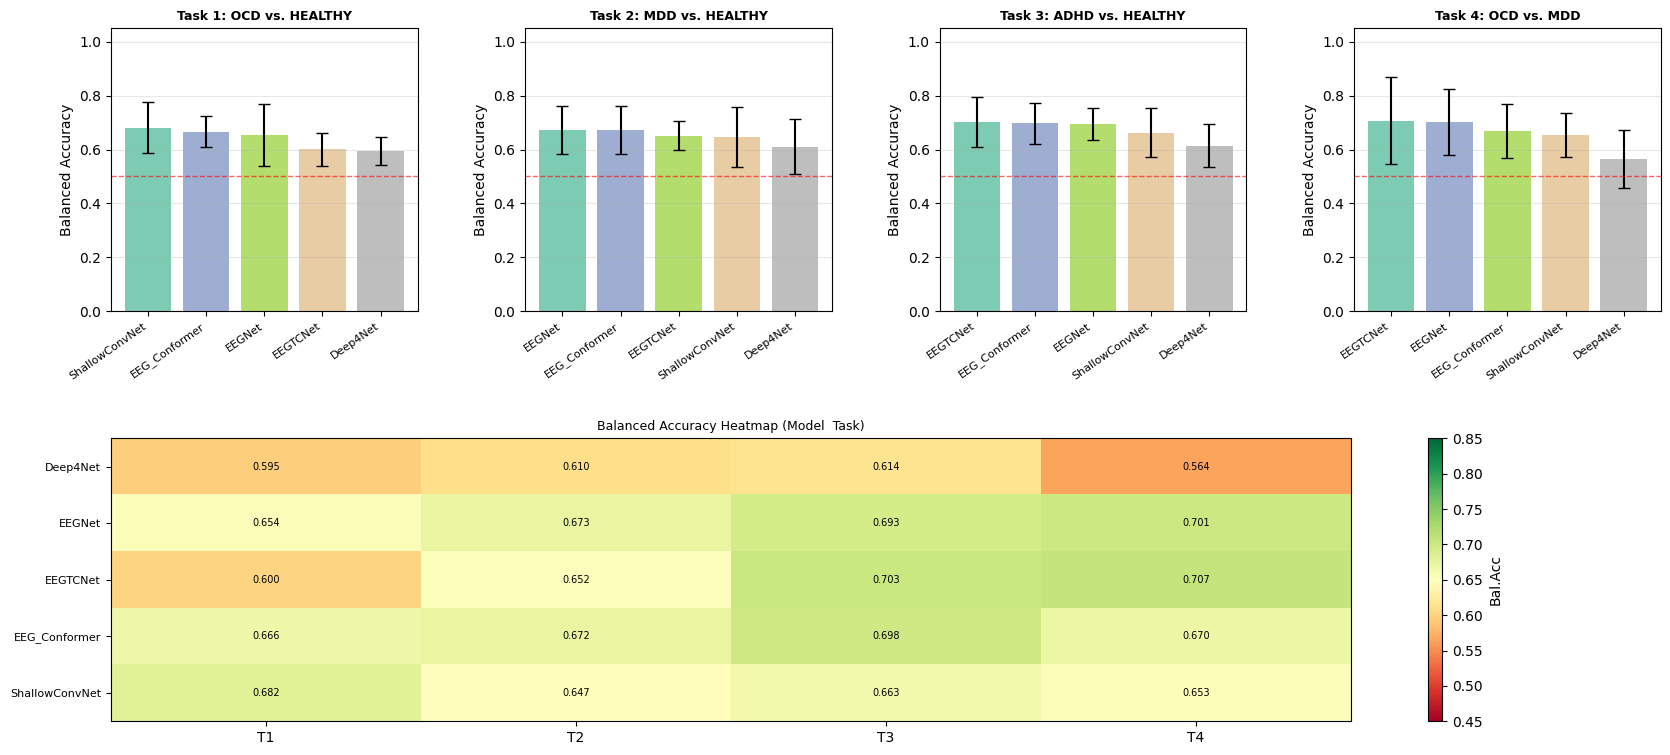


œ Report plot saved: /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/analysis_report_plot.png
œ HTML report saved  : /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/analysis_report.html
œ Markdown report    : /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/analysis_report.md

Analysis Report complete.
  Summary rows   : 20
  Fold rows      : 431
  LOSO rows      : 2


In [ ]:
# =============================================================================
# Cell 8: Cross-Model Analysis Report
#
# Loads the accumulated experiment_log.jsonl and produces:
#   SECTION A — Summary Table  : best model per task, all-model comparison
#   SECTION B — Detailed Diagnostics: per-model flags & corrective actions
#   SECTION C — Cross-Task Patterns: consistent winners / problem areas
#   SECTION D — HTML Report    : saved to OUTPUT_PATH for offline review
# =============================================================================

import json as _json, os, warnings, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

# —— Load accumulated log ──────────────────────────────────────────────────────
LOG_PATH   = os.path.join(OUTPUT_PATH, 'experiment_log.jsonl')
REPORT_HTML = os.path.join(OUTPUT_PATH, 'analysis_report.html')
REPORT_MD   = os.path.join(OUTPUT_PATH, 'analysis_report.md')

if not os.path.exists(LOG_PATH):
    print("š   No experiment_log.jsonl found. Run Cells 5—7 first.")
else:

    # —— Flatten log into DataFrames ───────────────────────────────────────────
    fold_rows, summary_rows, loso_rows = [], [], []

    with open(LOG_PATH) as fh:
        for line in fh:
            rec = _json.loads(line.strip())
            base = {k: rec[k] for k in
                    ['timestamp','task_id','task_name','imbalance_strategy',
                     'smoke_test','n_folds','max_epochs','n_subjects_per_cat']}

            for fr in rec.get('fold_results', []):
                fold_rows.append({**base, **fr})

            for ms in rec.get('model_summary', []):
                summary_rows.append({**base, **ms})

            if rec.get('loso_summary'):
                loso_rows.append({**base,
                                   'loso_model': rec.get('loso_model'),
                                   **rec['loso_summary']})

    df_folds   = pd.DataFrame(fold_rows)
    df_summary = pd.DataFrame(summary_rows)
    df_loso    = pd.DataFrame(loso_rows)

    # —— If multiple runs for same task/model, keep most recent ───────────────
    if not df_summary.empty:
        df_summary = (df_summary
                      .sort_values('timestamp')
                      .drop_duplicates(subset=['task_id','model'], keep='last')
                      .reset_index(drop=True))

    METRICS   = ['bal_acc_mean','roc_auc_mean','f1_mean','pr_auc_mean']
    METRIC_LBL = ['Bal.Acc','ROC-AUC','F1','PR-AUC']

    # =========================================================================
    # SECTION A — Summary Table
    # =========================================================================
    print("\n" + "="*78)
    print("SECTION A  CROSS-MODEL SUMMARY")
    print("="*78)

    if df_summary.empty:
        print("  No summary data available yet.")
    else:
        # Best model per task (by balanced accuracy)
        best_per_task = (df_summary
                         .sort_values('bal_acc_mean', ascending=False)
                         .drop_duplicates('task_id')[['task_id','task_name','model',
                                                       'bal_acc_mean','roc_auc_mean',
                                                       'f1_mean','pr_auc_mean']])

        print("\n¸ Best model per task (highest balanced accuracy):\n")
        hdr = f"  {'Task':>4}  {'Name':<30}  {'Model':<18}  {'Bal.Acc':>7}  {'ROC-AUC':>7}  {'F1':>7}  {'PR-AUC':>7}"
        print(hdr)
        print("  " + "-"*76)
        for _, r in best_per_task.iterrows():
            flag = " š " if r['bal_acc_mean'] < 0.55 else ("  œ" if r['bal_acc_mean'] >= 0.65 else "  ~")
            print(f"  {int(r['task_id']):>4}  {str(r['task_name']):<30}  {str(r['model']):<18}  "
                  f"{r['bal_acc_mean']:>7.4f}  {r['roc_auc_mean']:>7.4f}  "
                  f"{r['f1_mean']:>7.4f}  {r['pr_auc_mean']:>7.4f}{flag}")

        # Full pivot: model  task
        if df_summary['task_id'].nunique() > 1:
            print("\n¸ Balanced accuracy across all tasks  models:\n")
            pivot = df_summary.pivot_table(
                index='model', columns='task_id',
                values='bal_acc_mean', aggfunc='last'
            ).round(4)
            pivot.columns = [f"T{c}" for c in pivot.columns]
            pivot['avg'] = pivot.mean(axis=1)
            pivot = pivot.sort_values('avg', ascending=False)
            print(pivot.to_string())
        else:
            print(f"\n  (Only Task {df_summary['task_id'].iloc[0]} in log so far — "
                  "run more tasks to see cross-task pivot)")

        # LOSO summary
        if not df_loso.empty:
            print("\n¸ Subject-Level LOSO (clinical utility):\n")
            loso_hdr = f"  {'Task':>4}  {'Task Name':<30}  {'Model':<18}  {'Subj.Acc':>8}  {'Subj.n':>7}"
            print(loso_hdr)
            print("  " + "-"*68)
            for _, r in df_loso.iterrows():
                subj_acc = r.get('balanced_acc', r.get('subject_balanced_acc', float('nan')))
                n_subj   = int(r.get('n_subjects', 0))
                print(f"  {int(r['task_id']):>4}  {str(r['task_name']):<30}  "
                      f"{str(r.get('loso_model','?')):<18}  {subj_acc:>8.4f}  {n_subj:>7}")

    # =========================================================================
    # SECTION B — Detailed Diagnostics & Corrective Actions
    # =========================================================================
    print("\n" + "="*78)
    print("SECTION B  DETAILED DIAGNOSTICS & CORRECTIVE ACTIONS")
    print("="*78)

    # Threshold definitions
    THRESH = {
        'chance_warn'   : 0.55,   # bal_acc below this = near-chance
        'chance_ok'     : 0.65,   # bal_acc above this = acceptable
        'high_var'      : 0.10,   # bal_acc_std above = unstable
        'moderate_var'  : 0.06,
        'roc_warn'      : 0.57,
        'pr_warn'       : 0.57,
        'early_stop'    : 5,      # best_ep_mean below = not training
        'loso_gap'      : 0.12,   # |groupkfold_acc - loso_acc| > this = overfitting signal
    }

    FLAGS = {
        'NEAR_CHANCE'  : "› Near-chance balanced accuracy ({:.3f}). "
                         "Possible causes: wrong labels, bad preprocessing, "
                         "too few subjects. Actions: (1) verify label mapping in TASK_CATEGORIES, "
                         "(2) print class distribution, (3) check if channels match COMMON_CHANNELS.",
        'HIGH_VAR'     : "š   High cross-fold variance (std={:.3f}). Model unstable. "
                         "Actions: increase N_FOLDS, add dropout, reduce learning rate, "
                         "or check for subject-level confounds.",
        'MODERATE_VAR' : "~  Moderate variance (std={:.3f}). Monitor with more folds.",
        'LOW_ROC'      : "š   ROC-AUC {:.3f} near chance. Model is not separating classes. "
                         "Actions: (1) try SMOTE or class weighting, (2) increase window size, "
                         "(3) try ShallowConvNet (better for small samples).",
        'LOW_PR'       : "š   PR-AUC {:.3f} low — minority class poorly recalled. "
                         "Actions: switch IMBALANCE_STRATEGY to 'smote' or 'class_weight', "
                         "increase N_SUBJECTS_PER_CATEGORY for minority class.",
        'EARLY_STOP'   : "š   Best epoch {:.0f} very low — model not training. "
                         "Actions: lower LEARNING_RATE (try 5e-4†1e-4), increase BATCH_SIZE, "
                         "add batch norm, or check for NaN inputs.",
        'LOSO_GAP'     : "š   GroupKFold acc {:.3f} vs LOSO {:.3f} gap = {:.3f}. "
                         "Likely subject-level overfitting. Actions: (1) reduce model capacity, "
                         "(2) add L2 regularisation (WEIGHT_DECAY), (3) increase training subjects.",
        'HEALTHY'      : "œ  Good performance (bal_acc={:.3f}). Keep configuration.",
    }

    if df_summary.empty:
        print("  No data yet.")
    else:
        for task_id, grp in df_summary.groupby('task_id'):
            task_name = grp['task_name'].iloc[0]
            print(f"\n—— Task {task_id}: {task_name} {'—'*(50-len(str(task_name)))}")

            # Get LOSO for this task (most recent)
            loso_task = df_loso[df_loso['task_id'] == task_id] if 'task_id' in df_loso.columns else df_loso
            loso_acc  = None
            if not loso_task.empty:
                loso_acc = loso_task.iloc[-1].get(
                    'balanced_acc', loso_task.iloc[-1].get('subject_balanced_acc', None))

            for _, row in grp.sort_values('bal_acc_mean', ascending=False).iterrows():
                model     = row['model']
                bal_mean  = row.get('bal_acc_mean', float('nan'))
                bal_std   = row.get('bal_acc_std',  0.0)
                roc_mean  = row.get('roc_auc_mean', float('nan'))
                pr_mean   = row.get('pr_auc_mean',  float('nan'))
                best_ep   = row.get('best_ep_mean', float('nan'))

                print(f"\n  ¸ {model}")
                print(f"    Bal.Acc={bal_mean:.4f}{bal_std:.3f}  "
                      f"ROC={roc_mean:.4f}  PR={pr_mean:.4f}  "
                      f"BestEp={best_ep:.1f}")

                diagnostics = []

                if bal_mean < THRESH['chance_warn']:
                    diagnostics.append(('NEAR_CHANCE', FLAGS['NEAR_CHANCE'].format(bal_mean)))
                elif bal_mean >= THRESH['chance_ok']:
                    diagnostics.append(('HEALTHY',     FLAGS['HEALTHY'].format(bal_mean)))

                if bal_std > THRESH['high_var']:
                    diagnostics.append(('HIGH_VAR', FLAGS['HIGH_VAR'].format(bal_std)))
                elif bal_std > THRESH['moderate_var']:
                    diagnostics.append(('MODERATE_VAR', FLAGS['MODERATE_VAR'].format(bal_std)))

                if not np.isnan(roc_mean) and roc_mean < THRESH['roc_warn']:
                    diagnostics.append(('LOW_ROC', FLAGS['LOW_ROC'].format(roc_mean)))

                if not np.isnan(pr_mean) and pr_mean < THRESH['pr_warn']:
                    diagnostics.append(('LOW_PR', FLAGS['LOW_PR'].format(pr_mean)))

                if not np.isnan(best_ep) and best_ep < THRESH['early_stop']:
                    diagnostics.append(('EARLY_STOP', FLAGS['EARLY_STOP'].format(best_ep)))

                if loso_acc is not None and not np.isnan(bal_mean):
                    gap = abs(bal_mean - loso_acc)
                    if gap > THRESH['loso_gap']:
                        diagnostics.append(('LOSO_GAP',
                            FLAGS['LOSO_GAP'].format(bal_mean, loso_acc, gap)))

                if not diagnostics:
                    print("    (no flags)")
                for _key, msg in diagnostics:
                    # Word-wrap at 72 chars with indent
                    wrapped = textwrap.fill(msg, width=72,
                                            initial_indent='    ',
                                            subsequent_indent='      ')
                    print(wrapped)

    # =========================================================================
    # SECTION C — Cross-Task Patterns
    # =========================================================================
    print("\n" + "="*78)
    print("SECTION C  CROSS-TASK PATTERNS")
    print("="*78)

    if df_summary.empty or df_summary['task_id'].nunique() < 2:
        print("  Needs results from ‰¥2 tasks. Run more tasks and re-run this cell.")
    else:
        # Consistently best model (wins most tasks by bal_acc)
        winner_count = (df_summary
                        .sort_values('bal_acc_mean', ascending=False)
                        .drop_duplicates(['task_id'])
                        .groupby('model').size()
                        .sort_values(ascending=False))
        print(f"\n¸ Task wins per model (highest bal_acc wins task):")
        for m, n in winner_count.items():
            print(f"    {m:<20}: {n} task(s)")

        # Tasks where all models struggle (max bal_acc < 0.60)
        hard_tasks = (df_summary
                      .groupby('task_id')['bal_acc_mean'].max()
                      .loc[lambda s: s < 0.60])
        if not hard_tasks.empty:
            print(f"\n¸ Difficult tasks (all models < 0.60 bal_acc):")
            for tid, v in hard_tasks.items():
                tname = df_summary.loc[df_summary['task_id']==tid,'task_name'].iloc[0]
                print(f"    Task {tid} ({tname}): best={v:.4f}  "
                      f"† consider more subjects or different channels")
        else:
            print("\n¸ No task has all models below 0.60 œ")

        # Strategy comparison (if multiple strategies tested)
        if df_summary['imbalance_strategy'].nunique() > 1:
            strat_cmp = df_summary.groupby('imbalance_strategy')['bal_acc_mean'].mean()
            print(f"\n¸ Imbalance strategy comparison (mean bal_acc across all tasks):")
            for s, v in strat_cmp.sort_values(ascending=False).items():
                print(f"    {s:<20}: {v:.4f}")

    # =========================================================================
    # SECTION D — Visualisation + HTML / Markdown report
    # =========================================================================
    if not df_summary.empty:

        # —— Figure ────────────────────────────────────────────────────────────
        tasks   = sorted(df_summary['task_id'].unique())
        models  = df_summary['model'].unique()
        n_tasks = len(tasks)

        fig = plt.figure(figsize=(max(14, 5*n_tasks), 9))
        gs  = gridspec.GridSpec(2, max(n_tasks, 1), hspace=0.45, wspace=0.35)

        # Row 0: bar chart per task
        for ti, tid in enumerate(tasks):
            ax = fig.add_subplot(gs[0, ti])
            grp = df_summary[df_summary['task_id'] == tid].copy()
            grp = grp.sort_values('bal_acc_mean', ascending=False)
            x   = np.arange(len(grp))
            bars = ax.bar(x, grp['bal_acc_mean'],
                          yerr=grp.get('bal_acc_std', 0), capsize=4,
                          color=plt.cm.Set2(np.linspace(0,1,len(grp))),
                          alpha=0.85)
            ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.6)
            ax.set_xticks(x)
            ax.set_xticklabels(grp['model'], rotation=35, ha='right', fontsize=8)
            ax.set_ylim(0, 1.05)
            ax.set_ylabel('Balanced Accuracy')
            tname = str(grp['task_name'].iloc[0])[:22]
            ax.set_title(f"Task {tid}: {tname}", fontsize=9, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)

        # Row 1: multi-metric radar per model (only if single task in log)
        if n_tasks == 1 and not df_summary.empty:
            ax2 = fig.add_subplot(gs[1, :])
            grp = df_summary[df_summary['task_id'] == tasks[0]].copy()
            for col, lbl, clr in zip(
                ['bal_acc_mean','roc_auc_mean','f1_mean','pr_auc_mean'],
                ['Bal.Acc','ROC-AUC','F1','PR-AUC'],
                ['steelblue','darkorange','green','purple']
            ):
                if col in grp.columns:
                    ax2.plot(grp['model'], grp[col], marker='o', label=lbl, color=clr)
            ax2.axhline(0.5, color='red', ls='--', lw=1, alpha=0.5)
            ax2.set_ylim(0, 1.05)
            ax2.set_ylabel('Score')
            ax2.set_title('All Metrics by Model', fontsize=9, fontweight='bold')
            ax2.legend(fontsize=8, loc='lower right')
            ax2.grid(alpha=0.3)
            plt.setp(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=8)
        elif n_tasks > 1:
            # Row 1: heatmap of bal_acc (model  task)
            ax2 = fig.add_subplot(gs[1, :])
            pivot_heat = df_summary.pivot_table(
                index='model', columns='task_id',
                values='bal_acc_mean', aggfunc='last'
            )
            im = ax2.imshow(pivot_heat.values, aspect='auto',
                            cmap='RdYlGn', vmin=0.45, vmax=0.85)
            ax2.set_xticks(range(len(pivot_heat.columns)))
            ax2.set_xticklabels([f"T{c}" for c in pivot_heat.columns])
            ax2.set_yticks(range(len(pivot_heat.index)))
            ax2.set_yticklabels(pivot_heat.index, fontsize=8)
            ax2.set_title('Balanced Accuracy Heatmap (Model  Task)', fontsize=9)
            plt.colorbar(im, ax=ax2, label='Bal.Acc')
            for i in range(len(pivot_heat.index)):
                for j in range(len(pivot_heat.columns)):
                    v = pivot_heat.values[i, j]
                    if not np.isnan(v):
                        ax2.text(j, i, f"{v:.3f}", ha='center', va='center',
                                 fontsize=7, color='black')

        PLOT_PATH = os.path.join(OUTPUT_PATH, 'analysis_report_plot.png')
        plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\nœ Report plot saved: {PLOT_PATH}")

        # —— HTML report ───────────────────────────────────────────────────────
        import base64 as _b64
        with open(PLOT_PATH, 'rb') as _pf:
            _img_b64 = _b64.b64encode(_pf.read()).decode()

        _summary_html = df_summary[['task_name','model','imbalance_strategy',
                                     'bal_acc_mean','bal_acc_std',
                                     'roc_auc_mean','f1_mean','pr_auc_mean',
                                     'best_ep_mean']].round(4).to_html(
            index=False, border=0,
            classes='table',
            float_format='{:.4f}'.format
        )

        _style = """
        body{font-family:Arial,sans-serif;margin:30px;color:#333;}
        h1{color:#1a4a8a;} h2{color:#2d6a4f;border-bottom:2px solid #2d6a4f;padding-bottom:4px;}
        h3{color:#e76f51;} .table{border-collapse:collapse;width:100%;font-size:13px;}
        .table th{background:#1a4a8a;color:#fff;padding:6px 10px;text-align:left;}
        .table td{padding:5px 10px;border-bottom:1px solid #ddd;}
        .table tr:nth-child(even){background:#f5f8ff;}
        .flag-bad{color:#c1121f;font-weight:bold;}
        .flag-warn{color:#e76f51;}
        .flag-ok{color:#2d6a4f;}
        pre{background:#f4f4f4;padding:12px;border-radius:4px;font-size:12px;overflow-x:auto;}
        img{max-width:100%;border:1px solid #ddd;border-radius:4px;margin:10px 0;}
        """

        # Build diagnostic HTML
        _diag_html = ""
        for task_id, grp in df_summary.groupby('task_id'):
            task_name = grp['task_name'].iloc[0]
            _diag_html += f"<h3>Task {task_id}: {task_name}</h3>"
            loso_task = df_loso[df_loso['task_id'] == task_id] if 'task_id' in df_loso.columns else df_loso
            loso_acc_h = None
            if not loso_task.empty:
                loso_acc_h = loso_task.iloc[-1].get('balanced_acc',
                             loso_task.iloc[-1].get('subject_balanced_acc', None))

            for _, row in grp.sort_values('bal_acc_mean', ascending=False).iterrows():
                model    = row['model']
                bal_mean = row.get('bal_acc_mean', float('nan'))
                bal_std  = row.get('bal_acc_std', 0.0)
                roc_mean = row.get('roc_auc_mean', float('nan'))
                pr_mean  = row.get('pr_auc_mean',  float('nan'))
                best_ep  = row.get('best_ep_mean', float('nan'))

                _diag_html += f"<b>{model}</b> &nbsp; Bal.Acc={bal_mean:.4f}{bal_std:.3f}  ROC={roc_mean:.4f}  PR={pr_mean:.4f}<ul>"

                if bal_mean < THRESH['chance_warn']:
                    _diag_html += f"<li class='flag-bad'>› Near-chance bal_acc={bal_mean:.3f}. Verify labels, preprocessing, channel config.</li>"
                elif bal_mean >= THRESH['chance_ok']:
                    _diag_html += f"<li class='flag-ok'>œ Good performance.</li>"
                if bal_std > THRESH['high_var']:
                    _diag_html += f"<li class='flag-warn'>š  High variance (std={bal_std:.3f}). Increase folds or regularisation.</li>"
                if not np.isnan(roc_mean) and roc_mean < THRESH['roc_warn']:
                    _diag_html += f"<li class='flag-warn'>š  ROC-AUC={roc_mean:.3f} near chance. Try SMOTE or class_weight.</li>"
                if not np.isnan(pr_mean) and pr_mean < THRESH['pr_warn']:
                    _diag_html += f"<li class='flag-warn'>š  PR-AUC={pr_mean:.3f} low. Minority class poorly recalled.</li>"
                if not np.isnan(best_ep) and best_ep < THRESH['early_stop']:
                    _diag_html += f"<li class='flag-warn'>š  Best epoch {best_ep:.0f} — model may not be training. Lower LR.</li>"
                if loso_acc_h is not None and not np.isnan(bal_mean):
                    gap = abs(bal_mean - loso_acc_h)
                    if gap > THRESH['loso_gap']:
                        _diag_html += f"<li class='flag-warn'>š  GroupKFold {bal_mean:.3f} vs LOSO {loso_acc_h:.3f} gap={gap:.3f}. Possible overfitting.</li>"
                _diag_html += "</ul>"

        _html = f"""<!DOCTYPE html>
<html><head><meta charset='utf-8'>
<title>EEG Classification Analysis Report</title>
<style>{_style}</style></head><body>
<h1>EEG Classification — Analysis Report</h1>
<p>Generated: {_dt.datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')} &nbsp;|&nbsp;
   Log: {os.path.basename(LOG_PATH)} &nbsp;|&nbsp;
   Experiments: {len(df_folds)} fold records</p>

<h2>Section A — Cross-Model Summary</h2>
{_summary_html}
<img src="data:image/png;base64,{_img_b64}" alt="Results plot">

<h2>Section B — Detailed Diagnostics &amp; Corrective Actions</h2>
{_diag_html}

<h2>Section C — Cross-Task Patterns</h2>
<pre>
"""
        # append winner counts
        if df_summary['task_id'].nunique() >= 2:
            wc = (df_summary.sort_values('bal_acc_mean',ascending=False)
                  .drop_duplicates('task_id').groupby('model').size()
                  .sort_values(ascending=False))
            _html += "Task wins per model:\n"
            for m, n in wc.items():
                _html += f"  {m:<20}: {n}\n"
        else:
            _html += "Run ‰¥2 tasks for cross-task patterns.\n"
        _html += f"""</pre>
</body></html>"""

        with open(REPORT_HTML, 'w') as _rf:
            _rf.write(_html)
        print(f"œ HTML report saved  : {REPORT_HTML}")

        # —— Markdown summary ──────────────────────────────────────────────────
        _md_lines = [
            "# EEG Classification — Analysis Report",
            f"Generated: {_dt.datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}",
            "",
            "## Section A — Cross-Model Summary",
            "",
            df_summary[['task_name','model','imbalance_strategy',
                         'bal_acc_mean','bal_acc_std',
                         'roc_auc_mean','f1_mean','pr_auc_mean']].round(4).to_markdown(index=False),
            "",
            "## Section B — Corrective Action Flags",
            "",
        ]
        for task_id, grp in df_summary.groupby('task_id'):
            _md_lines.append(f"### Task {task_id}: {grp['task_name'].iloc[0]}")
            for _, row in grp.sort_values('bal_acc_mean', ascending=False).iterrows():
                _md_lines.append(f"**{row['model']}** bal_acc={row.get('bal_acc_mean',0):.4f}")
                flags_md = []
                if row.get('bal_acc_mean', 1) < THRESH['chance_warn']:
                    flags_md.append("- › Near-chance performance. Check labels and preprocessing.")
                if row.get('bal_acc_std', 0) > THRESH['high_var']:
                    flags_md.append(f"- š  High variance (std={row.get('bal_acc_std',0):.3f}).")
                if not flags_md:
                    flags_md.append("- œ No critical flags.")
                _md_lines.extend(flags_md)
                _md_lines.append("")
        with open(REPORT_MD, 'w') as _mf:
            _mf.write('\n'.join(_md_lines))
        print(f"œ Markdown report    : {REPORT_MD}")

        print(f"\n{'='*78}")
        print("Analysis Report complete.")
        print(f"  Summary rows   : {len(df_summary)}")
        print(f"  Fold rows      : {len(df_folds)}")
        print(f"  LOSO rows      : {len(df_loso)}")
        print(f"{'='*78}")


## Cell 8: Analysis Report — Summary, Diagnostics & Corrective Actions
Loads `experiment_log.jsonl` to produce a cross-model, cross-task report.
Re-run at any time to refresh after adding more results.

In [ ]:
!grep -rl "Pandas4Warning" /usr/local/lib/python3.12/dist-packages/*/ 2>/dev/null | head
import pandas as pd; print("pandas", pd.__version__)

pandas 2.2.3



SECTION A  CROSS-MODEL SUMMARY

¸ Best model per task (highest balanced accuracy):

  Task  Name                            Model               Bal.Acc  ROC-AUC       F1   PR-AUC
  ----------------------------------------------------------------------------
     3  ADHD vs. HEALTHY                EEGTCNet             0.7148   0.6565   0.6976   0.6095  œ
     1  OCD vs. HEALTHY                 ShallowConvNet       0.7084   0.6484   0.6842   0.6877  œ
     4  OCD vs. MDD                     EEG_Conformer        0.6898   0.6809   0.6396   0.6565  œ
     2  MDD vs. HEALTHY                 EEGTCNet             0.6567   0.6460   0.6485   0.5066  œ

¸ Balanced accuracy across all tasks  models:

                    T1      T2      T3      T4       avg
model                                                   
EEG_Conformer   0.6377  0.6552  0.6940  0.6898  0.669175
EEGTCNet        0.6386  0.6567  0.7148  0.6506  0.665175
EEGNet          0.6406  0.6422  0.7077  0.6518  0.660575
ShallowConvNet  

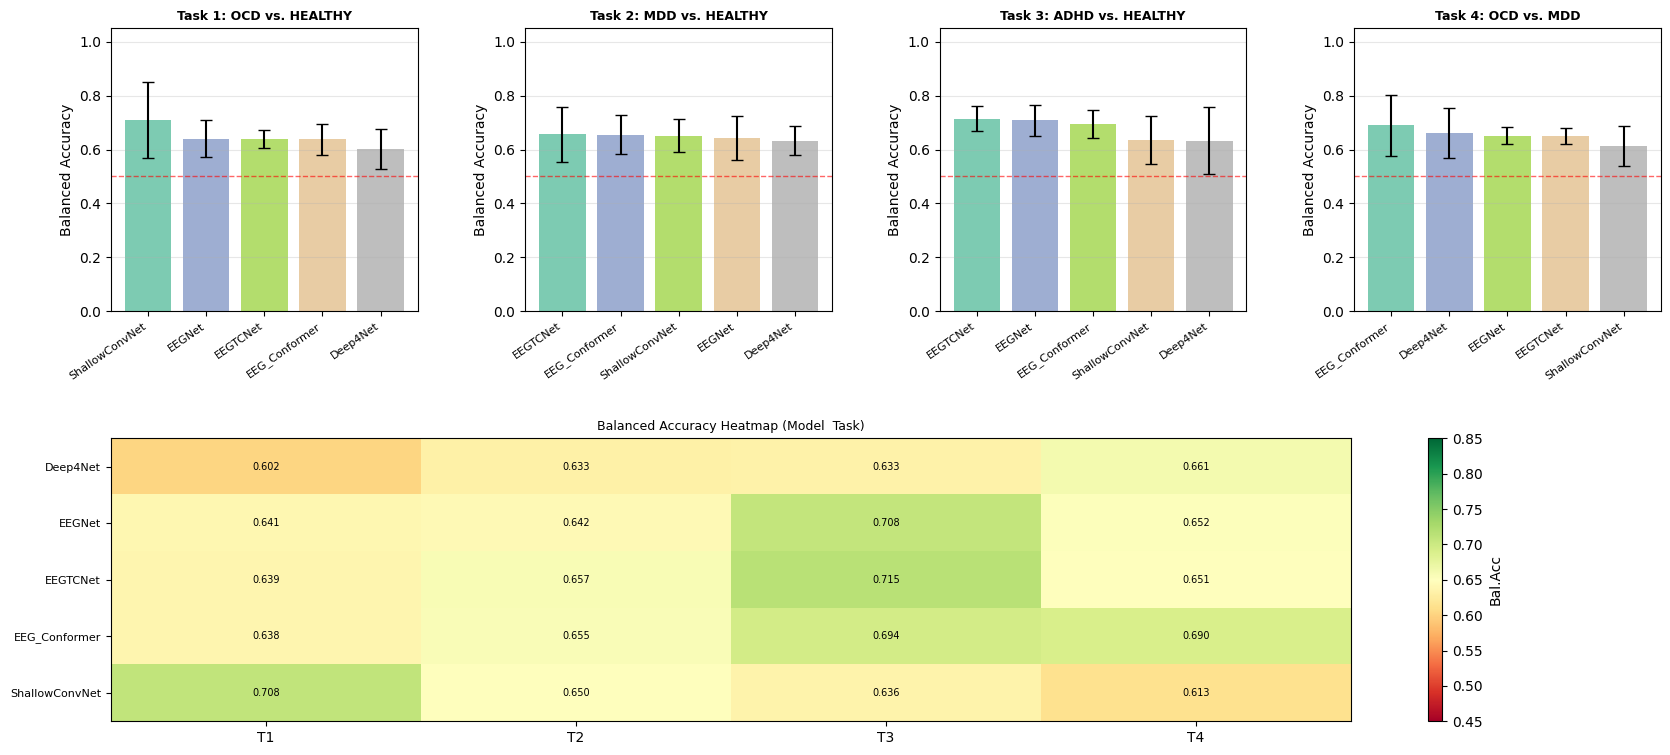


œ Report plot saved: /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/analysis_report_plot.png
œ HTML report saved  : /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/analysis_report.html
œ Markdown report    : /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/analysis_report.md

Analysis Report complete.
  Summary rows   : 20
  Fold rows      : 125
  LOSO rows      : 5


In [ ]:
# =============================================================================
# Cell 8: Cross-Model Analysis Report
#
# Loads the accumulated experiment_log.jsonl and produces:
#   SECTION A — Summary Table  : best model per task, all-model comparison
#   SECTION B — Detailed Diagnostics: per-model flags & corrective actions
#   SECTION C — Cross-Task Patterns: consistent winners / problem areas
#   SECTION D — HTML Report    : saved to OUTPUT_PATH for offline review
# =============================================================================

import json as _json, os, warnings, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

# —— Load accumulated log ──────────────────────────────────────────────────────
LOG_PATH   = os.path.join(OUTPUT_PATH, 'experiment_log.jsonl')
REPORT_HTML = os.path.join(OUTPUT_PATH, 'analysis_report.html')
REPORT_MD   = os.path.join(OUTPUT_PATH, 'analysis_report.md')

if not os.path.exists(LOG_PATH):
    print("š   No experiment_log.jsonl found. Run Cells 5—7 first.")
else:

    # —— Flatten log into DataFrames ───────────────────────────────────────────
    fold_rows, summary_rows, loso_rows = [], [], []

    with open(LOG_PATH) as fh:
        for line in fh:
            rec = _json.loads(line.strip())
            base = {k: rec[k] for k in
                    ['timestamp','task_id','task_name','imbalance_strategy',
                     'smoke_test','n_folds','max_epochs','n_subjects_per_cat']}

            for fr in rec.get('fold_results', []):
                fold_rows.append({**base, **fr})

            for ms in rec.get('model_summary', []):
                summary_rows.append({**base, **ms})

            if rec.get('loso_summary'):
                loso_rows.append({**base,
                                   'loso_model': rec.get('loso_model'),
                                   **rec['loso_summary']})

    df_folds   = pd.DataFrame(fold_rows)
    df_summary = pd.DataFrame(summary_rows)
    df_loso    = pd.DataFrame(loso_rows)

    # —— If multiple runs for same task/model, keep most recent ───────────────
    if not df_summary.empty:
        df_summary = (df_summary
                      .sort_values('timestamp')
                      .drop_duplicates(subset=['task_id','model'], keep='last')
                      .reset_index(drop=True))

    METRICS   = ['bal_acc_mean','roc_auc_mean','f1_mean','pr_auc_mean']
    METRIC_LBL = ['Bal.Acc','ROC-AUC','F1','PR-AUC']

    # =========================================================================
    # SECTION A — Summary Table
    # =========================================================================
    print("\n" + "="*78)
    print("SECTION A  CROSS-MODEL SUMMARY")
    print("="*78)

    if df_summary.empty:
        print("  No summary data available yet.")
    else:
        # Best model per task (by balanced accuracy)
        best_per_task = (df_summary
                         .sort_values('bal_acc_mean', ascending=False)
                         .drop_duplicates('task_id')[['task_id','task_name','model',
                                                       'bal_acc_mean','roc_auc_mean',
                                                       'f1_mean','pr_auc_mean']])

        print("\n¸ Best model per task (highest balanced accuracy):\n")
        hdr = f"  {'Task':>4}  {'Name':<30}  {'Model':<18}  {'Bal.Acc':>7}  {'ROC-AUC':>7}  {'F1':>7}  {'PR-AUC':>7}"
        print(hdr)
        print("  " + "-"*76)
        for _, r in best_per_task.iterrows():
            flag = " š " if r['bal_acc_mean'] < 0.55 else ("  œ" if r['bal_acc_mean'] >= 0.65 else "  ~")
            print(f"  {int(r['task_id']):>4}  {str(r['task_name']):<30}  {str(r['model']):<18}  "
                  f"{r['bal_acc_mean']:>7.4f}  {r['roc_auc_mean']:>7.4f}  "
                  f"{r['f1_mean']:>7.4f}  {r['pr_auc_mean']:>7.4f}{flag}")

        # Full pivot: model  task
        if df_summary['task_id'].nunique() > 1:
            print("\n¸ Balanced accuracy across all tasks  models:\n")
            pivot = df_summary.pivot_table(
                index='model', columns='task_id',
                values='bal_acc_mean', aggfunc='last'
            ).round(4)
            pivot.columns = [f"T{c}" for c in pivot.columns]
            pivot['avg'] = pivot.mean(axis=1)
            pivot = pivot.sort_values('avg', ascending=False)
            print(pivot.to_string())
        else:
            print(f"\n  (Only Task {df_summary['task_id'].iloc[0]} in log so far — "
                  "run more tasks to see cross-task pivot)")

        # LOSO summary
        if not df_loso.empty:
            print("\n¸ Subject-Level LOSO (clinical utility):\n")
            loso_hdr = f"  {'Task':>4}  {'Task Name':<30}  {'Model':<18}  {'Subj.Acc':>8}  {'Subj.n':>7}"
            print(loso_hdr)
            print("  " + "-"*68)
            for _, r in df_loso.iterrows():
                subj_acc = r.get('balanced_acc', r.get('subject_balanced_acc', float('nan')))
                n_subj   = int(r.get('n_subjects', 0))
                print(f"  {int(r['task_id']):>4}  {str(r['task_name']):<30}  "
                      f"{str(r.get('loso_model','?')):<18}  {subj_acc:>8.4f}  {n_subj:>7}")

    # =========================================================================
    # SECTION B — Detailed Diagnostics & Corrective Actions
    # =========================================================================
    print("\n" + "="*78)
    print("SECTION B  DETAILED DIAGNOSTICS & CORRECTIVE ACTIONS")
    print("="*78)

    # Threshold definitions
    THRESH = {
        'chance_warn'   : 0.55,   # bal_acc below this = near-chance
        'chance_ok'     : 0.65,   # bal_acc above this = acceptable
        'high_var'      : 0.10,   # bal_acc_std above = unstable
        'moderate_var'  : 0.06,
        'roc_warn'      : 0.57,
        'pr_warn'       : 0.57,
        'early_stop'    : 5,      # best_ep_mean below = not training
        'loso_gap'      : 0.12,   # |groupkfold_acc - loso_acc| > this = overfitting signal
    }

    FLAGS = {
        'NEAR_CHANCE'  : "› Near-chance balanced accuracy ({:.3f}). "
                         "Possible causes: wrong labels, bad preprocessing, "
                         "too few subjects. Actions: (1) verify label mapping in TASK_CATEGORIES, "
                         "(2) print class distribution, (3) check if channels match COMMON_CHANNELS.",
        'HIGH_VAR'     : "š   High cross-fold variance (std={:.3f}). Model unstable. "
                         "Actions: increase N_FOLDS, add dropout, reduce learning rate, "
                         "or check for subject-level confounds.",
        'MODERATE_VAR' : "~  Moderate variance (std={:.3f}). Monitor with more folds.",
        'LOW_ROC'      : "š   ROC-AUC {:.3f} near chance. Model is not separating classes. "
                         "Actions: (1) try SMOTE or class weighting, (2) increase window size, "
                         "(3) try ShallowConvNet (better for small samples).",
        'LOW_PR'       : "š   PR-AUC {:.3f} low — minority class poorly recalled. "
                         "Actions: switch IMBALANCE_STRATEGY to 'smote' or 'class_weight', "
                         "increase N_SUBJECTS_PER_CATEGORY for minority class.",
        'EARLY_STOP'   : "š   Best epoch {:.0f} very low — model not training. "
                         "Actions: lower LEARNING_RATE (try 5e-4†1e-4), increase BATCH_SIZE, "
                         "add batch norm, or check for NaN inputs.",
        'LOSO_GAP'     : "š   GroupKFold acc {:.3f} vs LOSO {:.3f} gap = {:.3f}. "
                         "Likely subject-level overfitting. Actions: (1) reduce model capacity, "
                         "(2) add L2 regularisation (WEIGHT_DECAY), (3) increase training subjects.",
        'HEALTHY'      : "œ  Good performance (bal_acc={:.3f}). Keep configuration.",
    }

    if df_summary.empty:
        print("  No data yet.")
    else:
        for task_id, grp in df_summary.groupby('task_id'):
            task_name = grp['task_name'].iloc[0]
            print(f"\n—— Task {task_id}: {task_name} {'—'*(50-len(str(task_name)))}")

            # Get LOSO for this task (most recent)
            loso_task = df_loso[df_loso['task_id'] == task_id] if 'task_id' in df_loso.columns else df_loso
            loso_acc  = None
            if not loso_task.empty:
                loso_acc = loso_task.iloc[-1].get(
                    'balanced_acc', loso_task.iloc[-1].get('subject_balanced_acc', None))

            for _, row in grp.sort_values('bal_acc_mean', ascending=False).iterrows():
                model     = row['model']
                bal_mean  = row.get('bal_acc_mean', float('nan'))
                bal_std   = row.get('bal_acc_std',  0.0)
                roc_mean  = row.get('roc_auc_mean', float('nan'))
                pr_mean   = row.get('pr_auc_mean',  float('nan'))
                best_ep   = row.get('best_ep_mean', float('nan'))

                print(f"\n  ¸ {model}")
                print(f"    Bal.Acc={bal_mean:.4f}{bal_std:.3f}  "
                      f"ROC={roc_mean:.4f}  PR={pr_mean:.4f}  "
                      f"BestEp={best_ep:.1f}")

                diagnostics = []

                if bal_mean < THRESH['chance_warn']:
                    diagnostics.append(('NEAR_CHANCE', FLAGS['NEAR_CHANCE'].format(bal_mean)))
                elif bal_mean >= THRESH['chance_ok']:
                    diagnostics.append(('HEALTHY',     FLAGS['HEALTHY'].format(bal_mean)))

                if bal_std > THRESH['high_var']:
                    diagnostics.append(('HIGH_VAR', FLAGS['HIGH_VAR'].format(bal_std)))
                elif bal_std > THRESH['moderate_var']:
                    diagnostics.append(('MODERATE_VAR', FLAGS['MODERATE_VAR'].format(bal_std)))

                if not np.isnan(roc_mean) and roc_mean < THRESH['roc_warn']:
                    diagnostics.append(('LOW_ROC', FLAGS['LOW_ROC'].format(roc_mean)))

                if not np.isnan(pr_mean) and pr_mean < THRESH['pr_warn']:
                    diagnostics.append(('LOW_PR', FLAGS['LOW_PR'].format(pr_mean)))

                if not np.isnan(best_ep) and best_ep < THRESH['early_stop']:
                    diagnostics.append(('EARLY_STOP', FLAGS['EARLY_STOP'].format(best_ep)))

                if loso_acc is not None and not np.isnan(bal_mean):
                    gap = abs(bal_mean - loso_acc)
                    if gap > THRESH['loso_gap']:
                        diagnostics.append(('LOSO_GAP',
                            FLAGS['LOSO_GAP'].format(bal_mean, loso_acc, gap)))

                if not diagnostics:
                    print("    (no flags)")
                for _key, msg in diagnostics:
                    # Word-wrap at 72 chars with indent
                    wrapped = textwrap.fill(msg, width=72,
                                            initial_indent='    ',
                                            subsequent_indent='      ')
                    print(wrapped)

    # =========================================================================
    # SECTION C — Cross-Task Patterns
    # =========================================================================
    print("\n" + "="*78)
    print("SECTION C  CROSS-TASK PATTERNS")
    print("="*78)

    if df_summary.empty or df_summary['task_id'].nunique() < 2:
        print("  Needs results from ‰¥2 tasks. Run more tasks and re-run this cell.")
    else:
        # Consistently best model (wins most tasks by bal_acc)
        winner_count = (df_summary
                        .sort_values('bal_acc_mean', ascending=False)
                        .drop_duplicates(['task_id'])
                        .groupby('model').size()
                        .sort_values(ascending=False))
        print(f"\n¸ Task wins per model (highest bal_acc wins task):")
        for m, n in winner_count.items():
            print(f"    {m:<20}: {n} task(s)")

        # Tasks where all models struggle (max bal_acc < 0.60)
        hard_tasks = (df_summary
                      .groupby('task_id')['bal_acc_mean'].max()
                      .loc[lambda s: s < 0.60])
        if not hard_tasks.empty:
            print(f"\n¸ Difficult tasks (all models < 0.60 bal_acc):")
            for tid, v in hard_tasks.items():
                tname = df_summary.loc[df_summary['task_id']==tid,'task_name'].iloc[0]
                print(f"    Task {tid} ({tname}): best={v:.4f}  "
                      f"† consider more subjects or different channels")
        else:
            print("\n¸ No task has all models below 0.60 œ")

        # Strategy comparison (if multiple strategies tested)
        if df_summary['imbalance_strategy'].nunique() > 1:
            strat_cmp = df_summary.groupby('imbalance_strategy')['bal_acc_mean'].mean()
            print(f"\n¸ Imbalance strategy comparison (mean bal_acc across all tasks):")
            for s, v in strat_cmp.sort_values(ascending=False).items():
                print(f"    {s:<20}: {v:.4f}")

    # =========================================================================
    # SECTION D — Visualisation + HTML / Markdown report
    # =========================================================================
    if not df_summary.empty:

        # —— Figure ────────────────────────────────────────────────────────────
        tasks   = sorted(df_summary['task_id'].unique())
        models  = df_summary['model'].unique()
        n_tasks = len(tasks)

        fig = plt.figure(figsize=(max(14, 5*n_tasks), 9))
        gs  = gridspec.GridSpec(2, max(n_tasks, 1), hspace=0.45, wspace=0.35)

        # Row 0: bar chart per task
        for ti, tid in enumerate(tasks):
            ax = fig.add_subplot(gs[0, ti])
            grp = df_summary[df_summary['task_id'] == tid].copy()
            grp = grp.sort_values('bal_acc_mean', ascending=False)
            x   = np.arange(len(grp))
            bars = ax.bar(x, grp['bal_acc_mean'],
                          yerr=grp.get('bal_acc_std', 0), capsize=4,
                          color=plt.cm.Set2(np.linspace(0,1,len(grp))),
                          alpha=0.85)
            ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.6)
            ax.set_xticks(x)
            ax.set_xticklabels(grp['model'], rotation=35, ha='right', fontsize=8)
            ax.set_ylim(0, 1.05)
            ax.set_ylabel('Balanced Accuracy')
            tname = str(grp['task_name'].iloc[0])[:22]
            ax.set_title(f"Task {tid}: {tname}", fontsize=9, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)

        # Row 1: multi-metric radar per model (only if single task in log)
        if n_tasks == 1 and not df_summary.empty:
            ax2 = fig.add_subplot(gs[1, :])
            grp = df_summary[df_summary['task_id'] == tasks[0]].copy()
            for col, lbl, clr in zip(
                ['bal_acc_mean','roc_auc_mean','f1_mean','pr_auc_mean'],
                ['Bal.Acc','ROC-AUC','F1','PR-AUC'],
                ['steelblue','darkorange','green','purple']
            ):
                if col in grp.columns:
                    ax2.plot(grp['model'], grp[col], marker='o', label=lbl, color=clr)
            ax2.axhline(0.5, color='red', ls='--', lw=1, alpha=0.5)
            ax2.set_ylim(0, 1.05)
            ax2.set_ylabel('Score')
            ax2.set_title('All Metrics by Model', fontsize=9, fontweight='bold')
            ax2.legend(fontsize=8, loc='lower right')
            ax2.grid(alpha=0.3)
            plt.setp(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=8)
        elif n_tasks > 1:
            # Row 1: heatmap of bal_acc (model  task)
            ax2 = fig.add_subplot(gs[1, :])
            pivot_heat = df_summary.pivot_table(
                index='model', columns='task_id',
                values='bal_acc_mean', aggfunc='last'
            )
            im = ax2.imshow(pivot_heat.values, aspect='auto',
                            cmap='RdYlGn', vmin=0.45, vmax=0.85)
            ax2.set_xticks(range(len(pivot_heat.columns)))
            ax2.set_xticklabels([f"T{c}" for c in pivot_heat.columns])
            ax2.set_yticks(range(len(pivot_heat.index)))
            ax2.set_yticklabels(pivot_heat.index, fontsize=8)
            ax2.set_title('Balanced Accuracy Heatmap (Model  Task)', fontsize=9)
            plt.colorbar(im, ax=ax2, label='Bal.Acc')
            for i in range(len(pivot_heat.index)):
                for j in range(len(pivot_heat.columns)):
                    v = pivot_heat.values[i, j]
                    if not np.isnan(v):
                        ax2.text(j, i, f"{v:.3f}", ha='center', va='center',
                                 fontsize=7, color='black')

        PLOT_PATH = os.path.join(OUTPUT_PATH, 'analysis_report_plot.png')
        plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\nœ Report plot saved: {PLOT_PATH}")

        # —— HTML report ───────────────────────────────────────────────────────
        import base64 as _b64
        with open(PLOT_PATH, 'rb') as _pf:
            _img_b64 = _b64.b64encode(_pf.read()).decode()

        _summary_html = df_summary[['task_name','model','imbalance_strategy',
                                     'bal_acc_mean','bal_acc_std',
                                     'roc_auc_mean','f1_mean','pr_auc_mean',
                                     'best_ep_mean']].round(4).to_html(
            index=False, border=0,
            classes='table',
            float_format='{:.4f}'.format
        )

        _style = """
        body{font-family:Arial,sans-serif;margin:30px;color:#333;}
        h1{color:#1a4a8a;} h2{color:#2d6a4f;border-bottom:2px solid #2d6a4f;padding-bottom:4px;}
        h3{color:#e76f51;} .table{border-collapse:collapse;width:100%;font-size:13px;}
        .table th{background:#1a4a8a;color:#fff;padding:6px 10px;text-align:left;}
        .table td{padding:5px 10px;border-bottom:1px solid #ddd;}
        .table tr:nth-child(even){background:#f5f8ff;}
        .flag-bad{color:#c1121f;font-weight:bold;}
        .flag-warn{color:#e76f51;}
        .flag-ok{color:#2d6a4f;}
        pre{background:#f4f4f4;padding:12px;border-radius:4px;font-size:12px;overflow-x:auto;}
        img{max-width:100%;border:1px solid #ddd;border-radius:4px;margin:10px 0;}
        """

        # Build diagnostic HTML
        _diag_html = ""
        for task_id, grp in df_summary.groupby('task_id'):
            task_name = grp['task_name'].iloc[0]
            _diag_html += f"<h3>Task {task_id}: {task_name}</h3>"
            loso_task = df_loso[df_loso['task_id'] == task_id] if 'task_id' in df_loso.columns else df_loso
            loso_acc_h = None
            if not loso_task.empty:
                loso_acc_h = loso_task.iloc[-1].get('balanced_acc',
                             loso_task.iloc[-1].get('subject_balanced_acc', None))

            for _, row in grp.sort_values('bal_acc_mean', ascending=False).iterrows():
                model    = row['model']
                bal_mean = row.get('bal_acc_mean', float('nan'))
                bal_std  = row.get('bal_acc_std', 0.0)
                roc_mean = row.get('roc_auc_mean', float('nan'))
                pr_mean  = row.get('pr_auc_mean',  float('nan'))
                best_ep  = row.get('best_ep_mean', float('nan'))

                _diag_html += f"<b>{model}</b> &nbsp; Bal.Acc={bal_mean:.4f}{bal_std:.3f}  ROC={roc_mean:.4f}  PR={pr_mean:.4f}<ul>"

                if bal_mean < THRESH['chance_warn']:
                    _diag_html += f"<li class='flag-bad'>› Near-chance bal_acc={bal_mean:.3f}. Verify labels, preprocessing, channel config.</li>"
                elif bal_mean >= THRESH['chance_ok']:
                    _diag_html += f"<li class='flag-ok'>œ Good performance.</li>"
                if bal_std > THRESH['high_var']:
                    _diag_html += f"<li class='flag-warn'>š  High variance (std={bal_std:.3f}). Increase folds or regularisation.</li>"
                if not np.isnan(roc_mean) and roc_mean < THRESH['roc_warn']:
                    _diag_html += f"<li class='flag-warn'>š  ROC-AUC={roc_mean:.3f} near chance. Try SMOTE or class_weight.</li>"
                if not np.isnan(pr_mean) and pr_mean < THRESH['pr_warn']:
                    _diag_html += f"<li class='flag-warn'>š  PR-AUC={pr_mean:.3f} low. Minority class poorly recalled.</li>"
                if not np.isnan(best_ep) and best_ep < THRESH['early_stop']:
                    _diag_html += f"<li class='flag-warn'>š  Best epoch {best_ep:.0f} — model may not be training. Lower LR.</li>"
                if loso_acc_h is not None and not np.isnan(bal_mean):
                    gap = abs(bal_mean - loso_acc_h)
                    if gap > THRESH['loso_gap']:
                        _diag_html += f"<li class='flag-warn'>š  GroupKFold {bal_mean:.3f} vs LOSO {loso_acc_h:.3f} gap={gap:.3f}. Possible overfitting.</li>"
                _diag_html += "</ul>"

        _html = f"""<!DOCTYPE html>
<html><head><meta charset='utf-8'>
<title>EEG Classification Analysis Report</title>
<style>{_style}</style></head><body>
<h1>EEG Classification — Analysis Report</h1>
<p>Generated: {_dt.datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')} &nbsp;|&nbsp;
   Log: {os.path.basename(LOG_PATH)} &nbsp;|&nbsp;
   Experiments: {len(df_folds)} fold records</p>

<h2>Section A — Cross-Model Summary</h2>
{_summary_html}
<img src="data:image/png;base64,{_img_b64}" alt="Results plot">

<h2>Section B — Detailed Diagnostics &amp; Corrective Actions</h2>
{_diag_html}

<h2>Section C — Cross-Task Patterns</h2>
<pre>
"""
        # append winner counts
        if df_summary['task_id'].nunique() >= 2:
            wc = (df_summary.sort_values('bal_acc_mean',ascending=False)
                  .drop_duplicates('task_id').groupby('model').size()
                  .sort_values(ascending=False))
            _html += "Task wins per model:\n"
            for m, n in wc.items():
                _html += f"  {m:<20}: {n}\n"
        else:
            _html += "Run ‰¥2 tasks for cross-task patterns.\n"
        _html += f"""</pre>
</body></html>"""

        with open(REPORT_HTML, 'w') as _rf:
            _rf.write(_html)
        print(f"œ HTML report saved  : {REPORT_HTML}")

        # —— Markdown summary ──────────────────────────────────────────────────
        _md_lines = [
            "# EEG Classification — Analysis Report",
            f"Generated: {_dt.datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}",
            "",
            "## Section A — Cross-Model Summary",
            "",
            df_summary[['task_name','model','imbalance_strategy',
                         'bal_acc_mean','bal_acc_std',
                         'roc_auc_mean','f1_mean','pr_auc_mean']].round(4).to_markdown(index=False),
            "",
            "## Section B — Corrective Action Flags",
            "",
        ]
        for task_id, grp in df_summary.groupby('task_id'):
            _md_lines.append(f"### Task {task_id}: {grp['task_name'].iloc[0]}")
            for _, row in grp.sort_values('bal_acc_mean', ascending=False).iterrows():
                _md_lines.append(f"**{row['model']}** bal_acc={row.get('bal_acc_mean',0):.4f}")
                flags_md = []
                if row.get('bal_acc_mean', 1) < THRESH['chance_warn']:
                    flags_md.append("- › Near-chance performance. Check labels and preprocessing.")
                if row.get('bal_acc_std', 0) > THRESH['high_var']:
                    flags_md.append(f"- š  High variance (std={row.get('bal_acc_std',0):.3f}).")
                if not flags_md:
                    flags_md.append("- œ No critical flags.")
                _md_lines.extend(flags_md)
                _md_lines.append("")
        with open(REPORT_MD, 'w') as _mf:
            _mf.write('\n'.join(_md_lines))
        print(f"œ Markdown report    : {REPORT_MD}")

        print(f"\n{'='*78}")
        print("Analysis Report complete.")
        print(f"  Summary rows   : {len(df_summary)}")
        print(f"  Fold rows      : {len(df_folds)}")
        print(f"  LOSO rows      : {len(df_loso)}")
        print(f"{'='*78}")


In [ ]:
import pandas as pd
import os

log_path = os.path.join(OUTPUT_PATH, 'experiment_log.jsonl')

if os.path.exists(log_path):
    df_log = pd.read_json(log_path, lines=True)
    display(df_log)
else:
    print(f"The file {log_path} does not exist.")

,timestamp,task_id,task_name,imbalance_strategy,smoke_test,n_folds,max_epochs,target_sfreq,n_channels,n_times,n_subjects_per_cat,random_state,software_versions,hardware,hyperparams,fold_results,model_summary,loso_model,loso_summary,loso_subject_detail
0,2026-09-01 14:11:37+00:00,4,OCD vs. MDD,class_weight,False,5,60,250,26,500,75,42,"{'torch': '2.11.0+cu128', 'braindecode': '1.8....",NVIDIA L4,{'per_model_overrides': {'EEGNet': {'lr': 0.00...,"[{'task': 'OCD vs. MDD', 'model': 'EEGNet', 'i...","[{'model': 'Deep4Net', 'bal_acc_mean': 0.65133...",EEGTCNet+EEG_Conformer,"{'balanced_acc': 0.861111111111111, 'balanced_...","[{'subject': 'A_sub-88011157', 'true_label': 0..."
1,2026-09-03 04:12:17+00:00,4,OCD vs. MDD,class_weight,False,5,60,250,26,500,75,42,"{'torch': '2.11.0+cu128', 'braindecode': '1.8....",NVIDIA L4,{'per_model_overrides': {'EEGNet': {'lr': 0.00...,"[{'task': 'OCD vs. MDD', 'model': 'EEGNet', 'i...","[{'model': 'Deep4Net', 'bal_acc_mean': 0.66107...",EEGTCNet+EEG_Conformer,"{'balanced_acc': 0.861111111111111, 'balanced_...","[{'subject': 'A_sub-88011157', 'true_label': 0..."
2,2026-09-04 06:54:07+00:00,1,OCD vs. HEALTHY,class_weight,False,5,60,250,26,500,75,42,"{'torch': '2.11.0+cu128', 'braindecode': '1.8....",NVIDIA L4,{'per_model_overrides': {'EEGNet': {'lr': 0.00...,"[{'task': 'OCD vs. HEALTHY', 'model': 'EEGNet'...","[{'model': 'Deep4Net', 'bal_acc_mean': 0.60168...",EEGTCNet+EEG_Conformer,"{'balanced_acc': 0.7670772676371781, 'balanced...","[{'subject': 'A_sub-88011157', 'true_label': 0..."
3,2026-09-04 10:30:24+00:00,2,MDD vs. HEALTHY,class_weight,False,5,60,250,26,500,75,42,"{'torch': '2.11.0+cu128', 'braindecode': '1.8....",NVIDIA L4,{'per_model_overrides': {'EEGNet': {'lr': 0.00...,"[{'task': 'MDD vs. HEALTHY', 'model': 'EEGNet'...","[{'model': 'Deep4Net', 'bal_acc_mean': 0.63260...",EEGTCNet+EEG_Conformer,"{'balanced_acc': 0.8721985815602831, 'balanced...","[{'subject': 'A_sub-88005893', 'true_label': 0..."
4,2026-09-04 14:14:33+00:00,3,ADHD vs. HEALTHY,class_weight,False,5,60,250,26,500,75,42,"{'torch': '2.11.0+cu128', 'braindecode': '1.8....",NVIDIA L4,{'per_model_overrides': {'EEGNet': {'lr': 0.00...,"[{'task': 'ADHD vs. HEALTHY', 'model': 'EEGNet...","[{'model': 'Deep4Net', 'bal_acc_mean': 0.63326...",EEGTCNet+EEG_Conformer,"{'balanced_acc': 0.8096453900709221, 'balanced...","[{'subject': 'A_sub-88015117', 'true_label': 0..."


In [ ]:
# @title 📋 Reviewer metrics — model params (Issue 10) + medication check (Issue 11)
# Run AFTER the Pipeline Functions cell (needs build_model in scope).
import pandas as pd

# Issue 10: parameter counts for all models
_MODELS = ['EEGNet', 'ShallowConvNet', 'Deep4Net', 'EEG_Conformer', 'EEGTCNet']
_NCH, _NT = 26, 500
print(f'Model parameter counts  (n_chans={_NCH}, n_times={_NT}, n_classes=2):')
print(f"  {'Model':16} {'Total':>14} {'Trainable':>14}")
for _mn in _MODELS:
    try:
        _m = build_model(_mn, _NCH, _NT)
        _tot = sum(p.numel() for p in _m.parameters())
        _tr = sum(p.numel() for p in _m.parameters() if p.requires_grad)
        print(f"  {_mn:16} {_tot:>14,} {_tr:>14,}")
        del _m
    except Exception as _e:
        print(f"  {_mn:16} ERROR: {_e}")

# Issue 11: medication metadata check
_TSV = '/content/gdrive/MyDrive/TD_Brain_Dataset/participants.tsv'
try:
    _pt = pd.read_csv(_TSV, sep='\t')
    print(f'\nparticipants.tsv  ({_pt.shape[0]} rows, {_pt.shape[1]} cols). Columns:')
    for _c in _pt.columns:
        print('  -', _c)
    _keys = ('medic', 'drug', 'ssri', 'snri', 'treatment', 'antidep', 'benzo', 'dose')
    _medcols = [c for c in _pt.columns if any(k in c.lower() for k in _keys)]
    if _medcols:
        print(f'\n  Candidate medication columns: {_medcols}')
        for _c in _medcols:
            print(f"\n  Value counts for '{_c}':")
            print(_pt[_c].value_counts(dropna=False).to_string())
    else:
        print('\n  No obvious medication column in participants.tsv.')
        print('  -> Issue 11 likely needs the extended TDBRAIN clinical/questionnaire metadata.')
except Exception as _e:
    print(f'\nmedication check failed: {_e}')


In [ ]:
import pandas as pd

# Mount Google Drive to access files (if not already mounted)
from google.colab import drive
if not os.path.exists('/content/gdrive/MyDrive'):
    drive.mount('/content/gdrive')

# Update this path to the correct location of your Excel file in Google Drive
# Example: '/content/gdrive/MyDrive/path/to/your/TDBRAIN_participants_V2.xlsx'
file_path = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/TDBRAIN_participants_V2.xlsx' # Adjust this path

try:
    p = pd.read_excel(file_path)
    print(p.groupby('indication')['age'].agg(['count','mean','std']).round(1))
    print(p['indication'].value_counts())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please verify the path to your Excel file in Google Drive.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Error: The file '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/TDBRAIN_participants_V2.xlsx' was not found. Please verify the path to your Excel file in Google Drive.



=== Task 1 (OCD vs HEALTHY) — 5 model checkpoint(s) ===
  Deep4Net         checkpoint fold=3 bal_acc=0.707


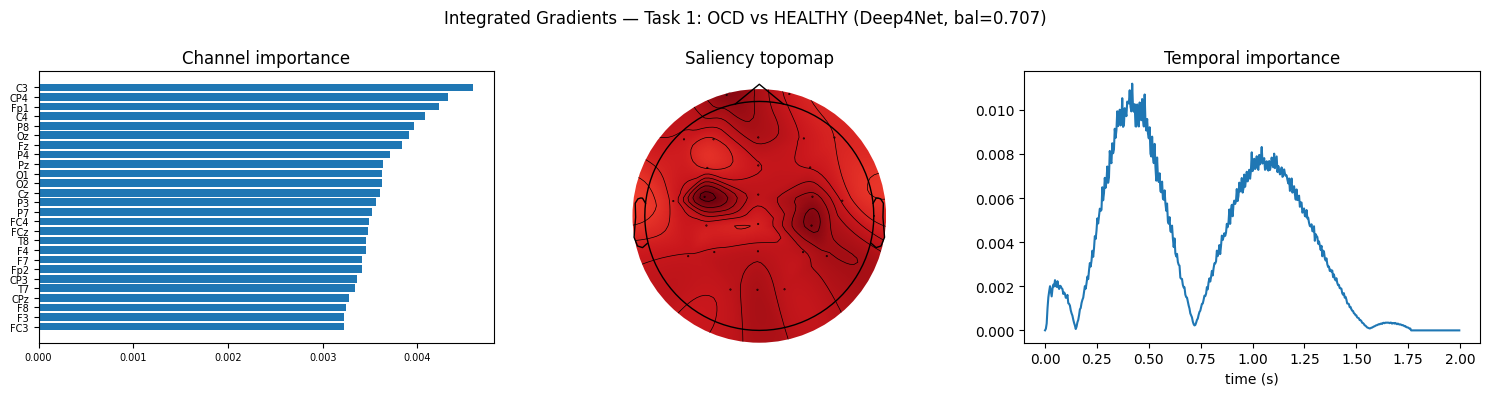

    saved saliency_task1_Deep4Net.png  top-5 channels: [np.str_('C3'), np.str_('CP4'), np.str_('Fp1'), np.str_('C4'), np.str_('P8')]
  EEGNet           checkpoint fold=3 bal_acc=0.664


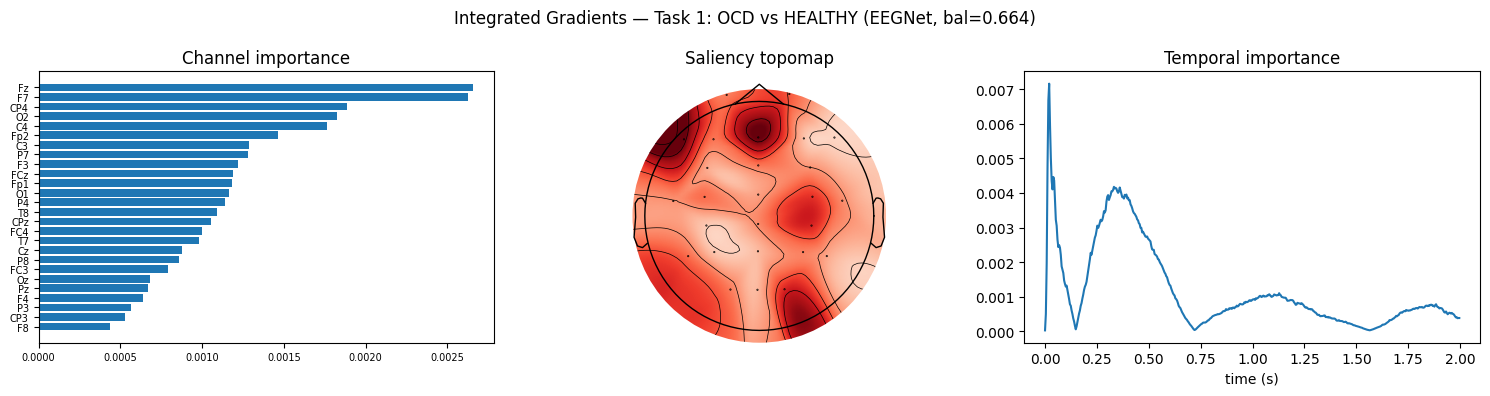

    saved saliency_task1_EEGNet.png  top-5 channels: [np.str_('Fz'), np.str_('F7'), np.str_('CP4'), np.str_('O2'), np.str_('C4')]
  EEGTCNet         checkpoint fold=4 bal_acc=0.867


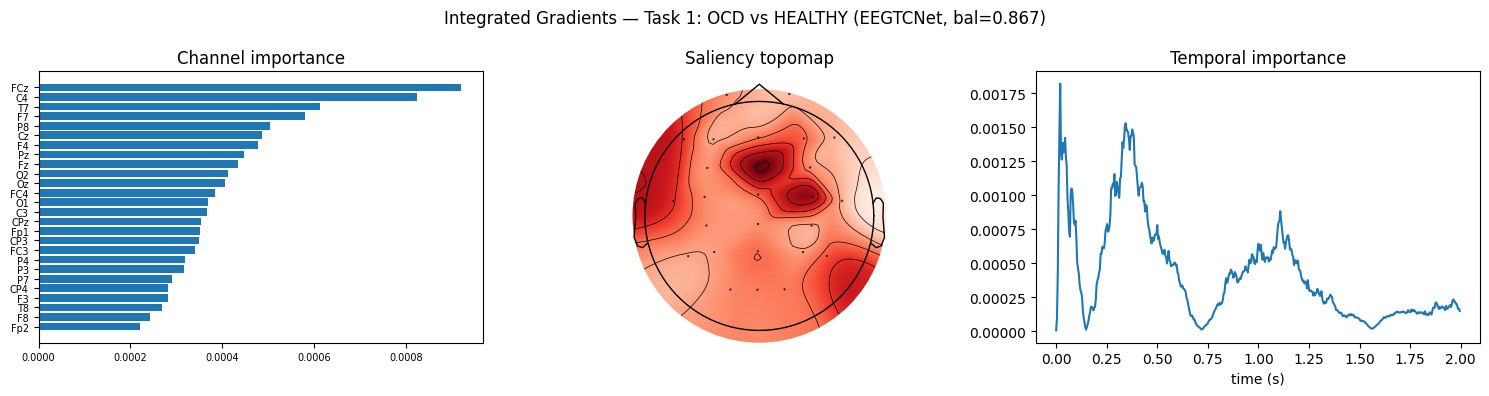

    saved saliency_task1_EEGTCNet.png  top-5 channels: [np.str_('FCz'), np.str_('C4'), np.str_('T7'), np.str_('F7'), np.str_('P8')]
  EEG_Conformer    checkpoint fold=4 bal_acc=0.693
  task1_EEG_Conformer.pt FAILED: CUDA out of memory. Tried to allocate 11.80 GiB. GPU 0 has a total capacity of 22.03 GiB of which 9.14 GiB is free. Including non-PyTorch memory, this process has 12.88 GiB memory in use. Of the allocated memory 12.60 GiB is allocated by PyTorch, and 33.05 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)
  ShallowConvNet   checkpoint fold=1 bal_acc=0.869


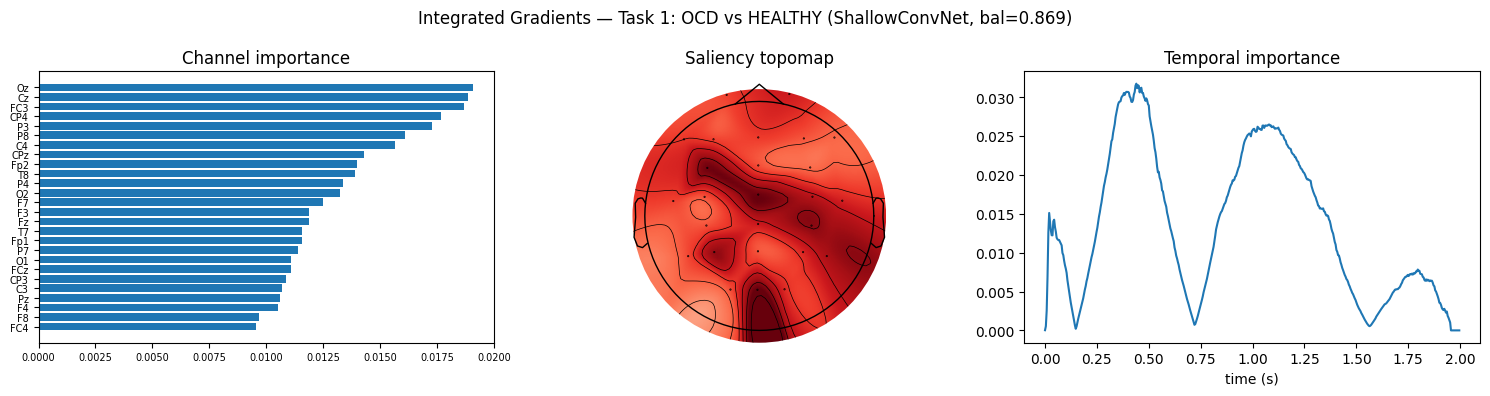

    saved saliency_task1_ShallowConvNet.png  top-5 channels: [np.str_('Oz'), np.str_('Cz'), np.str_('FC3'), np.str_('CP4'), np.str_('P3')]

=== Task 2 (MDD vs HEALTHY) — 5 model checkpoint(s) ===
  Deep4Net         checkpoint fold=5 bal_acc=0.798


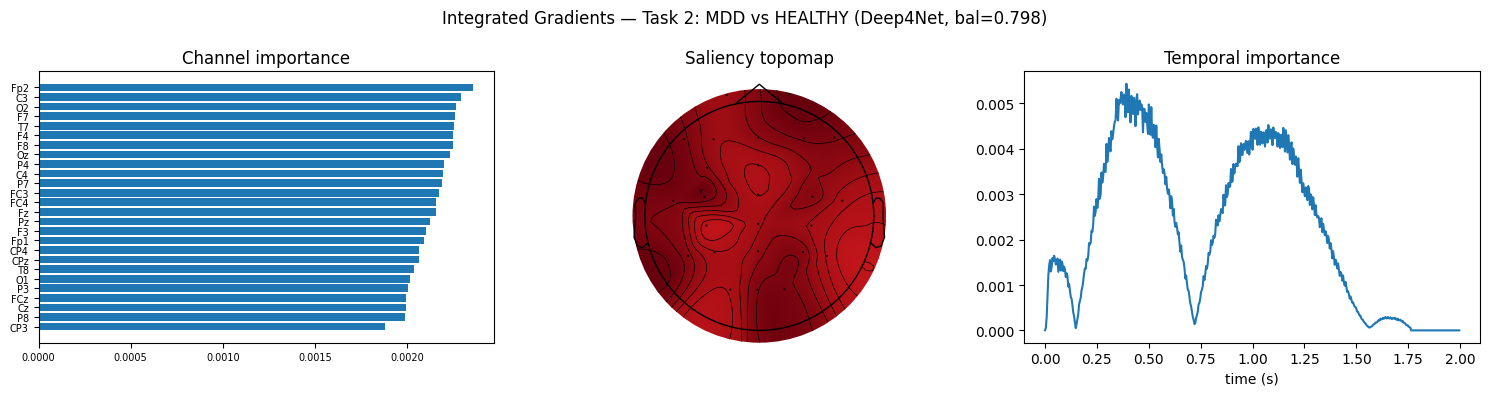

    saved saliency_task2_Deep4Net.png  top-5 channels: [np.str_('Fp2'), np.str_('C3'), np.str_('O2'), np.str_('F7'), np.str_('T7')]
  EEGNet           checkpoint fold=5 bal_acc=0.793


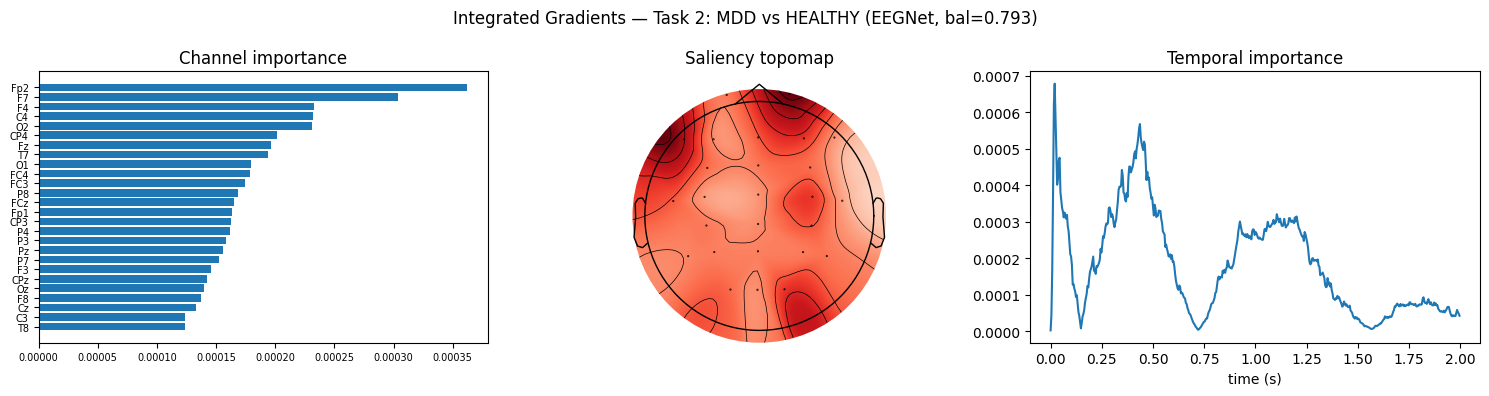

    saved saliency_task2_EEGNet.png  top-5 channels: [np.str_('Fp2'), np.str_('F7'), np.str_('F4'), np.str_('C4'), np.str_('O2')]
  EEGTCNet         checkpoint fold=5 bal_acc=0.832


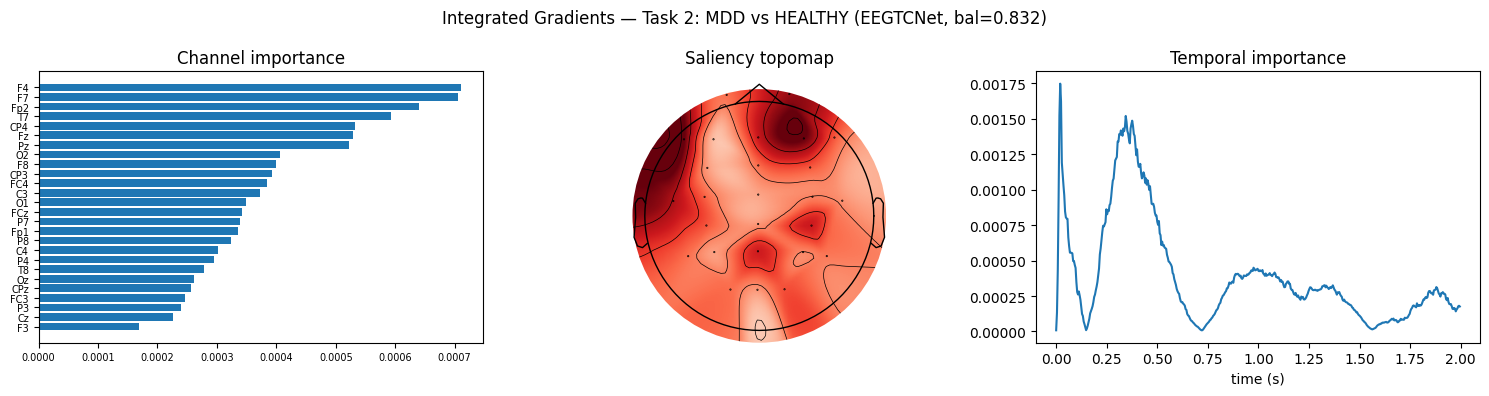

    saved saliency_task2_EEGTCNet.png  top-5 channels: [np.str_('F4'), np.str_('F7'), np.str_('Fp2'), np.str_('T7'), np.str_('CP4')]
  EEG_Conformer    checkpoint fold=5 bal_acc=0.762
  task2_EEG_Conformer.pt FAILED: CUDA out of memory. Tried to allocate 11.80 GiB. GPU 0 has a total capacity of 22.03 GiB of which 9.14 GiB is free. Including non-PyTorch memory, this process has 12.88 GiB memory in use. Of the allocated memory 12.60 GiB is allocated by PyTorch, and 33.04 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)
  ShallowConvNet   checkpoint fold=1 bal_acc=0.752


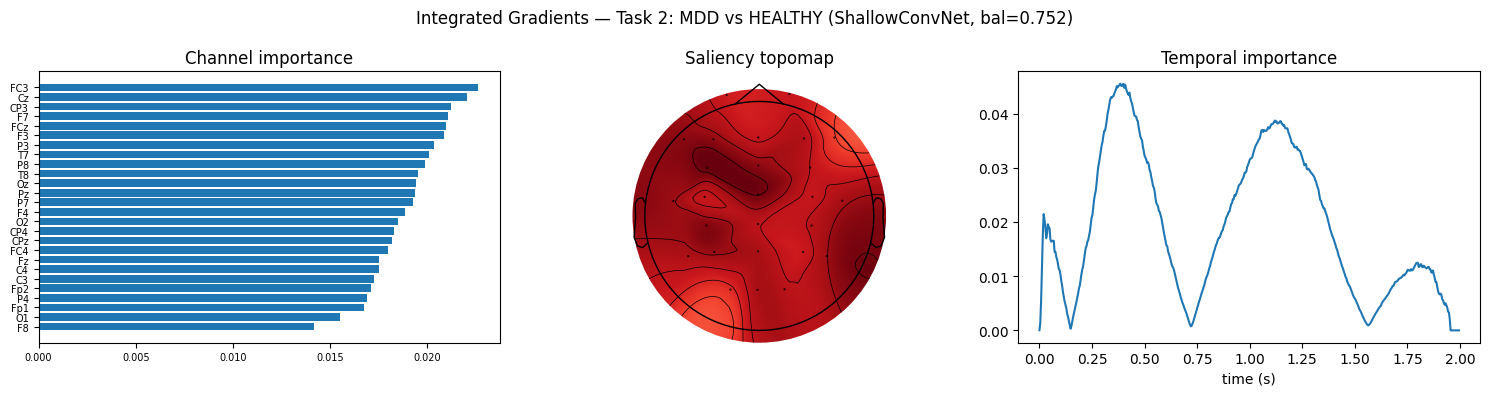

    saved saliency_task2_ShallowConvNet.png  top-5 channels: [np.str_('FC3'), np.str_('Cz'), np.str_('CP3'), np.str_('F7'), np.str_('FCz')]

=== Task 3 (ADHD vs HEALTHY) — 5 model checkpoint(s) ===
  Deep4Net         checkpoint fold=3 bal_acc=0.662


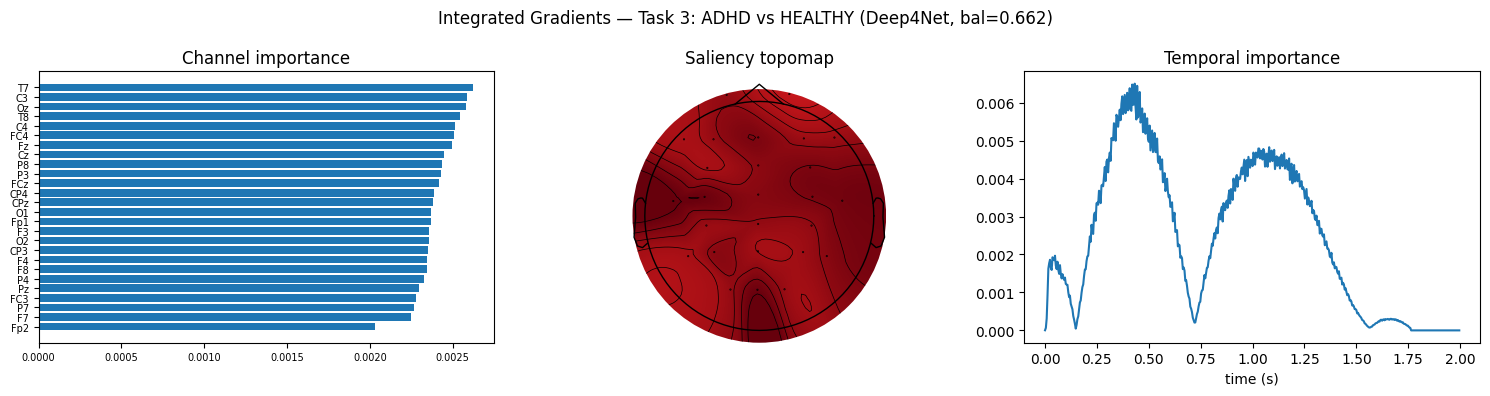

    saved saliency_task3_Deep4Net.png  top-5 channels: [np.str_('T7'), np.str_('C3'), np.str_('Oz'), np.str_('T8'), np.str_('C4')]
  EEGNet           checkpoint fold=2 bal_acc=0.826


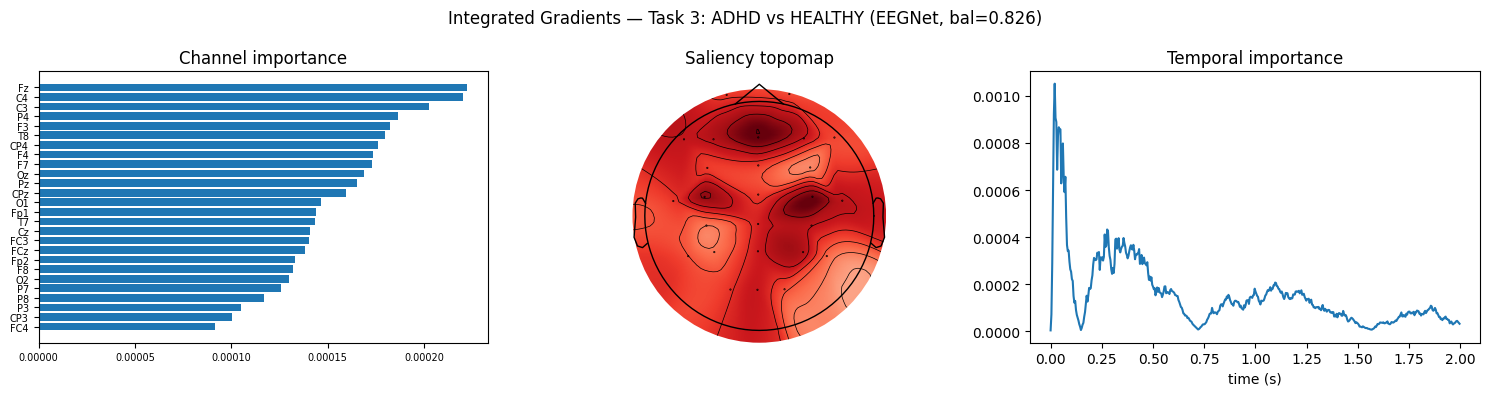

    saved saliency_task3_EEGNet.png  top-5 channels: [np.str_('Fz'), np.str_('C4'), np.str_('C3'), np.str_('P4'), np.str_('F3')]
  EEGTCNet         checkpoint fold=3 bal_acc=0.718


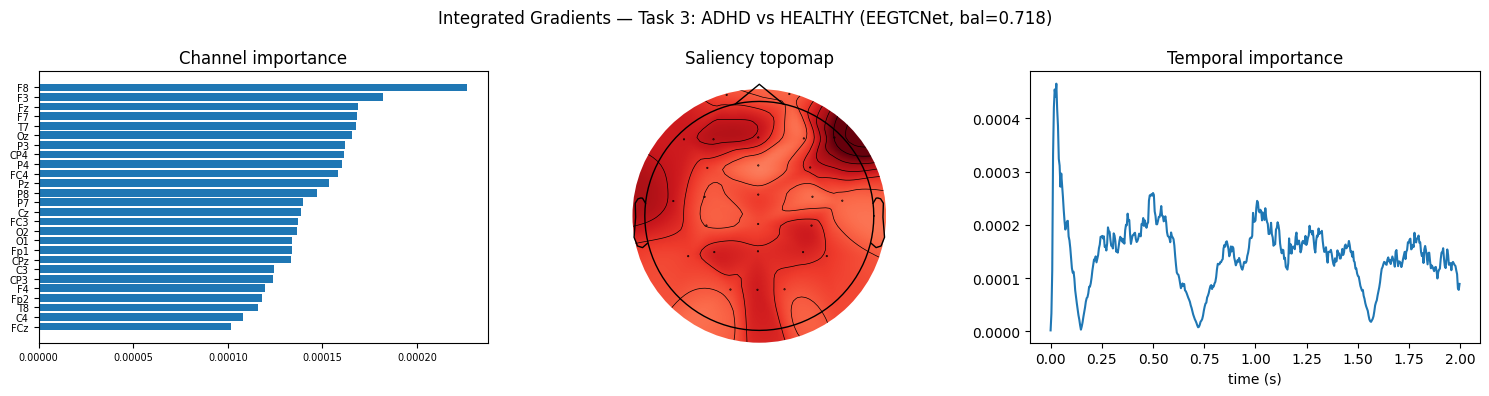

    saved saliency_task3_EEGTCNet.png  top-5 channels: [np.str_('F8'), np.str_('F3'), np.str_('Fz'), np.str_('F7'), np.str_('T7')]
  EEG_Conformer    checkpoint fold=2 bal_acc=0.812
  task3_EEG_Conformer.pt FAILED: CUDA out of memory. Tried to allocate 11.80 GiB. GPU 0 has a total capacity of 22.03 GiB of which 9.00 GiB is free. Including non-PyTorch memory, this process has 13.03 GiB memory in use. Of the allocated memory 12.60 GiB is allocated by PyTorch, and 181.66 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)
  ShallowConvNet   checkpoint fold=1 bal_acc=0.746


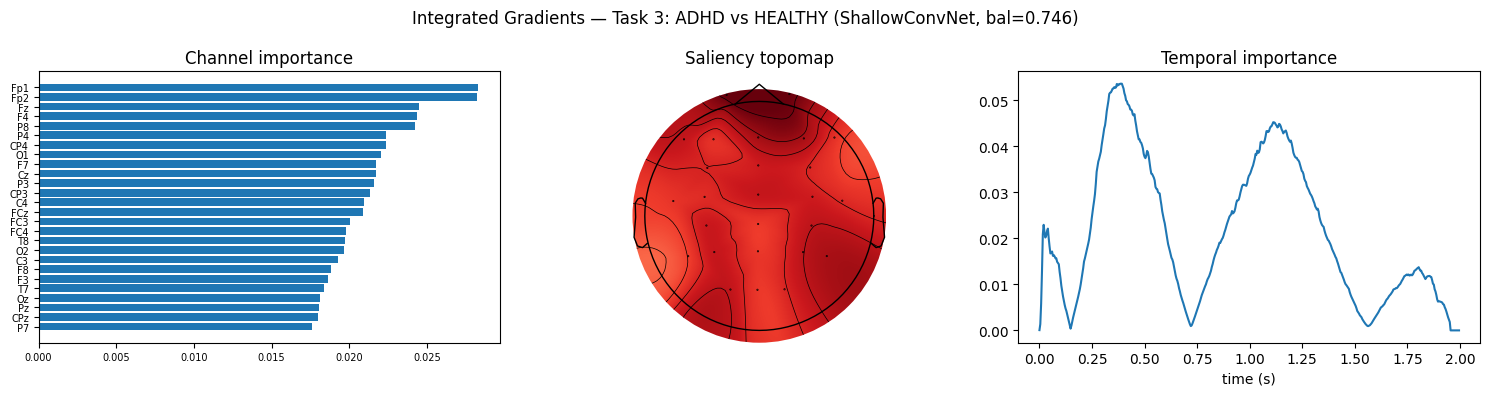

    saved saliency_task3_ShallowConvNet.png  top-5 channels: [np.str_('Fp1'), np.str_('Fp2'), np.str_('Fz'), np.str_('F4'), np.str_('P8')]

=== Task 4 (OCD vs MDD) — 5 model checkpoint(s) ===
  Deep4Net         checkpoint fold=2 bal_acc=0.750


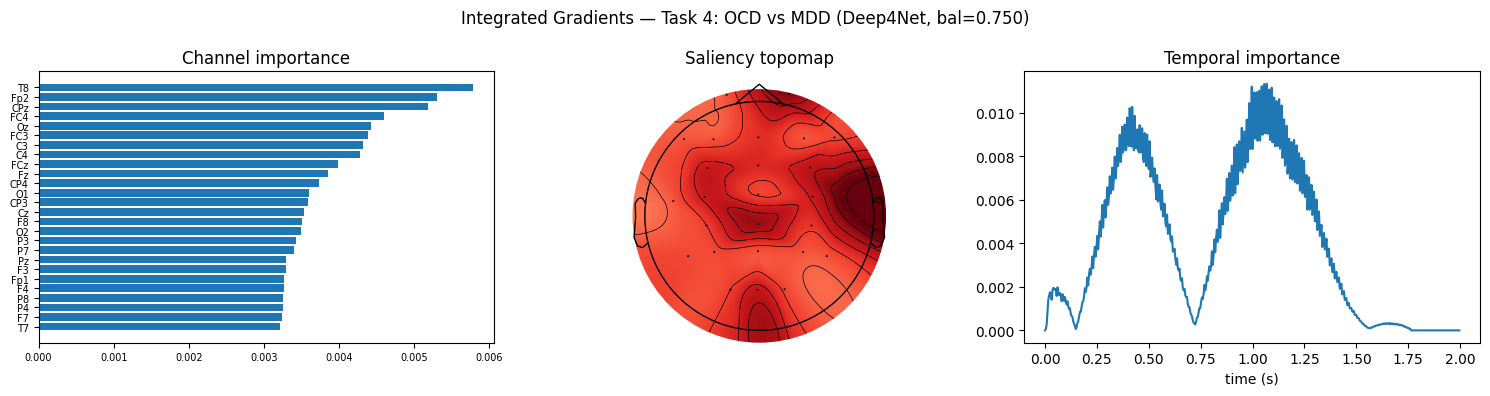

    saved saliency_task4_Deep4Net.png  top-5 channels: [np.str_('T8'), np.str_('Fp2'), np.str_('CPz'), np.str_('FC4'), np.str_('Oz')]
  EEGNet           checkpoint fold=1 bal_acc=0.739


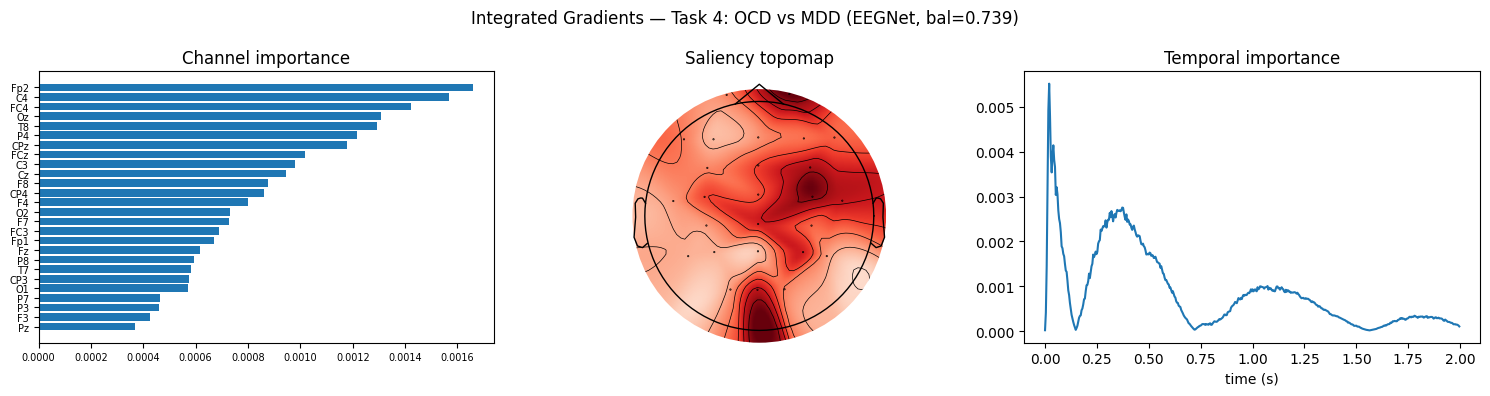

    saved saliency_task4_EEGNet.png  top-5 channels: [np.str_('Fp2'), np.str_('C4'), np.str_('FC4'), np.str_('Oz'), np.str_('T8')]
  EEGTCNet         checkpoint fold=3 bal_acc=0.687


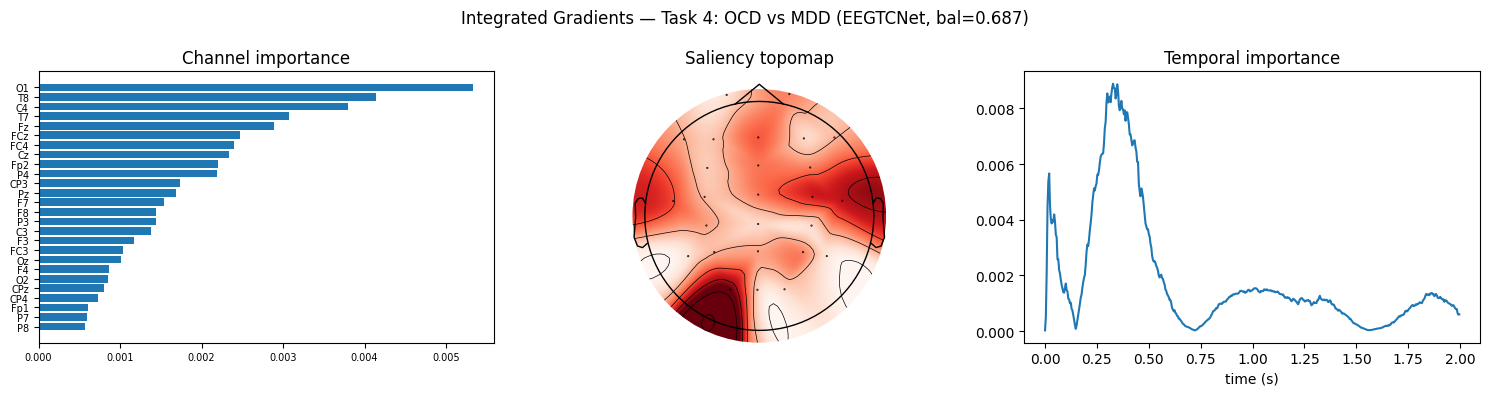

    saved saliency_task4_EEGTCNet.png  top-5 channels: [np.str_('O1'), np.str_('T8'), np.str_('C4'), np.str_('T7'), np.str_('Fz')]
  EEG_Conformer    checkpoint fold=2 bal_acc=0.744
  task4_EEG_Conformer.pt FAILED: CUDA out of memory. Tried to allocate 11.80 GiB. GPU 0 has a total capacity of 22.03 GiB of which 9.00 GiB is free. Including non-PyTorch memory, this process has 13.03 GiB memory in use. Of the allocated memory 12.60 GiB is allocated by PyTorch, and 181.66 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)
  ShallowConvNet   checkpoint fold=1 bal_acc=0.805


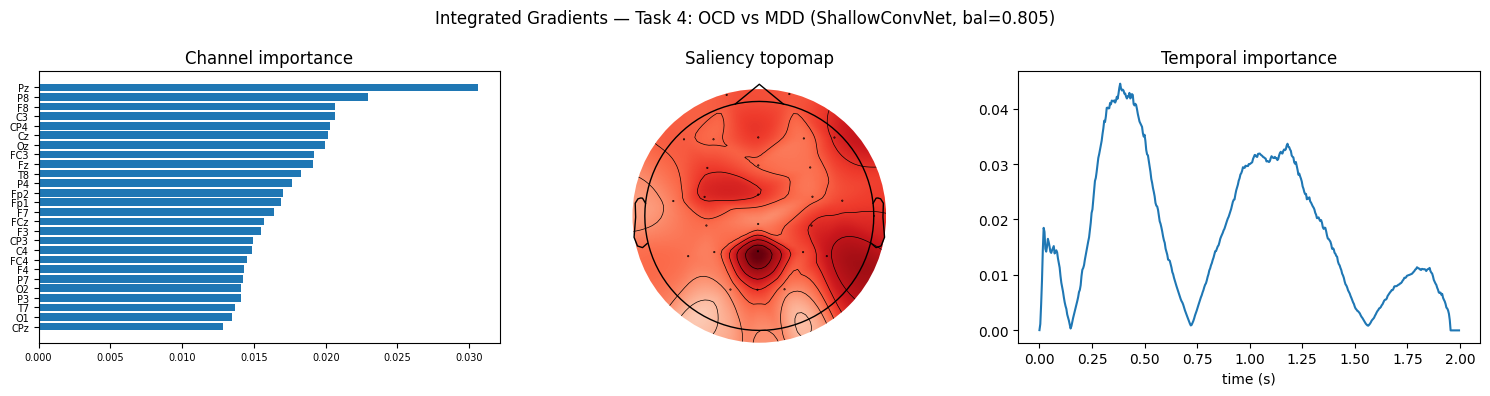

    saved saliency_task4_ShallowConvNet.png  top-5 channels: [np.str_('Pz'), np.str_('P8'), np.str_('F8'), np.str_('C3'), np.str_('CP4')]

=== Saliency summary ===
  task 1  Deep4Net         bal=0.707  top5=[np.str_('C3'), np.str_('CP4'), np.str_('Fp1'), np.str_('C4'), np.str_('P8')]
  task 1  EEGNet           bal=0.664  top5=[np.str_('Fz'), np.str_('F7'), np.str_('CP4'), np.str_('O2'), np.str_('C4')]
  task 1  EEGTCNet         bal=0.867  top5=[np.str_('FCz'), np.str_('C4'), np.str_('T7'), np.str_('F7'), np.str_('P8')]
  task 1  ShallowConvNet   bal=0.869  top5=[np.str_('Oz'), np.str_('Cz'), np.str_('FC3'), np.str_('CP4'), np.str_('P3')]
  task 2  Deep4Net         bal=0.798  top5=[np.str_('Fp2'), np.str_('C3'), np.str_('O2'), np.str_('F7'), np.str_('T7')]
  task 2  EEGNet           bal=0.793  top5=[np.str_('Fp2'), np.str_('F7'), np.str_('F4'), np.str_('C4'), np.str_('O2')]
  task 2  EEGTCNet         bal=0.832  top5=[np.str_('F4'), np.str_('F7'), np.str_('Fp2'), np.str_('T7'), np.str_('

In [8]:
# @title 🧠 Saliency (Integrated Gradients) — feature attribution per task (Issue 14)
# Run AFTER a training pass (needs checkpoints in OUTPUT_PATH/checkpoints/) and
# AFTER the Pipeline Functions cell (needs build_model + globals in scope).
SALIENCY_TASK_IDS = [1, 2, 3, 4]   # which tasks to explain
SALIENCY_MODEL    = None           # None = ALL models per task; or a model name for just one
SALIENCY_N_WIN    = 200            # number of windows sampled for attribution

import os, glob, numpy as np, torch
import matplotlib.pyplot as plt
try:
    from captum.attr import IntegratedGradients
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'captum'])
    from captum.attr import IntegratedGradients


class _LogitWrap(torch.nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        o = self.m(x)
        return o[0] if isinstance(o, (tuple, list)) else o


def _attribute_one(pick, X, chn, catA, catB, task_id):
    ckpt = torch.load(pick, map_location='cpu')
    mname, nch, nt = ckpt['model_name'], ckpt['n_channels'], ckpt['n_times']
    ba = ckpt.get('balanced_acc')
    ba_str = f'{ba:.3f}' if isinstance(ba, (int, float)) else 'n/a'
    print(f"  {mname:16} checkpoint fold={ckpt.get('fold')} bal_acc={ba_str}")

    model = build_model(mname, nch, nt).to(DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    wrapped = _LogitWrap(model).to(DEVICE).eval()

    xt = torch.from_numpy(X).to(DEVICE)
    with torch.no_grad():
        tgt = wrapped(xt).argmax(1)
    ig = IntegratedGradients(wrapped)
    attr = ig.attribute(xt, target=tgt, n_steps=32)
    A = attr.detach().abs().cpu().numpy()
    ch_imp = A.mean(axis=(0, 2))
    t_imp = A.mean(axis=(0, 1))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    order = np.argsort(ch_imp)
    axes[0].barh([chn[i] for i in order], ch_imp[order])
    axes[0].set_title('Channel importance')
    axes[0].tick_params(labelsize=7)
    try:
        import mne
        info = mne.create_info(chn, sfreq=250.0, ch_types='eeg')
        info.set_montage(mne.channels.make_standard_montage('standard_1020'),
                         match_case=False, on_missing='ignore')
        mne.viz.plot_topomap(ch_imp, info, axes=axes[1], show=False, cmap='Reds')
        axes[1].set_title('Saliency topomap')
    except Exception as te:
        axes[1].text(0.5, 0.5, f'topomap unavailable:{te}', ha='center', va='center', wrap=True)
        axes[1].set_axis_off()
    axes[2].plot(np.arange(nt) / 250.0, t_imp)
    axes[2].set_title('Temporal importance')
    axes[2].set_xlabel('time (s)')
    fig.suptitle(f'Integrated Gradients — Task {task_id}: {catA} vs {catB} ({mname}, bal={ba_str})')
    fig.tight_layout()
    out = os.path.join(OUTPUT_PATH, f'saliency_task{task_id}_{mname}.png')
    fig.savefig(out, dpi=120)
    plt.show()
    plt.close(fig)
    top = [chn[i] for i in np.argsort(ch_imp)[::-1][:5]]
    print(f'    saved {os.path.basename(out)}  top-5 channels: {top}')
    return {'task': task_id, 'model': mname, 'balanced_acc': ba, 'top5_channels': top, 'png': out}


def _load_cat(cat, n):
    d = np.load(os.path.join(NPZ_CACHE_DIR, f'{cat}_cache.npz'), allow_pickle=True)
    Xc = d['X']
    idx = np.random.RandomState(0).choice(len(Xc), size=min(n, len(Xc)), replace=False)
    return Xc[idx].astype('float32'), list(d['ch_names'].astype(str))


def _run_saliency_task(task_id):
    _ck_dir = os.path.join(OUTPUT_PATH, 'checkpoints')
    cands = sorted(glob.glob(os.path.join(_ck_dir, f'task{task_id}_*.pt')))
    if not cands:
        print(f'No checkpoints for task {task_id} in {_ck_dir} — skipping.')
        return []
    if SALIENCY_MODEL:
        cands = [c for c in cands if os.path.basename(c) == f'task{task_id}_{SALIENCY_MODEL}.pt']
        if not cands:
            print(f'No checkpoint for model "{SALIENCY_MODEL}" on task {task_id} — skipping.')
            return []

    catA, catB = TASK_CATEGORIES[task_id]
    XA, chn = _load_cat(catA, SALIENCY_N_WIN // 2)
    XB, _   = _load_cat(catB, SALIENCY_N_WIN // 2)
    X = np.concatenate([XA, XB], axis=0)

    print(f'\n=== Task {task_id} ({catA} vs {catB}) — {len(cands)} model checkpoint(s) ===')
    rows = []
    for pick in cands:
        try:
            r = _attribute_one(pick, X, chn, catA, catB, task_id)
            if r:
                rows.append(r)
        except Exception as e:
            print(f'  {os.path.basename(pick)} FAILED: {e}')
    return rows


def _run_saliency():
    all_rows = []
    for task_id in SALIENCY_TASK_IDS:
        if task_id not in TASK_CATEGORIES:
            print(f'Task {task_id} not in TASK_CATEGORIES — skipping.')
            continue
        try:
            all_rows += _run_saliency_task(task_id)
        except Exception as e:
            print(f'Task {task_id} FAILED: {e}')

    if all_rows:
        print('\n=== Saliency summary ===')
        for r in all_rows:
            ba = r['balanced_acc']
            ba_str = f"{ba:.3f}" if isinstance(ba, (int, float)) else 'n/a'
            print(f"  task{r['task']:>2}  {r['model']:16} bal={ba_str}  top5={r['top5_channels']}")
        try:
            import pandas as pd
            csv = os.path.join(OUTPUT_PATH, 'saliency_summary.csv')
            pd.DataFrame([{**r, 'top5_channels': ','.join(r['top5_channels'])} for r in all_rows]).to_csv(csv, index=False)
            print(f'  wrote {csv}')
        except Exception as e:
            print(f'  summary CSV skipped: {e}')
    else:
        print('\nNo attributions produced. Run a training pass first, then re-run this cell.')


try:
    _run_saliency()
except NameError as _ne:
    print(f'Missing dependency in scope ({_ne}). Run the Config + Pipeline Functions cells first.')
except Exception as _e:
    print(f'Saliency failed: {_e}')

In [ ]:
# @title DeLong pairwise model significance (Major Issue 8) - post-hoc, no retrain
# Reads OUTPUT_PATH/cv_scores/task{T}_{model}.npz (saved by stage_train, one
# out-of-fold prob vector per model on identical samples) and runs DeLong's test
# on ROC-AUC for every model pair, with Holm-Bonferroni correction.
# Requires a fresh 5-fold run AFTER this notebook update (to produce cv_scores/).
DELONG_TASK_ID = 3     # which task's cv_scores to test

import os, glob, numpy as np
from scipy.stats import norm

def _compute_midrank(x):
    J = np.argsort(x); Z = x[J]; N = len(x); T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    T2 = np.empty(N, dtype=float); T2[J] = T
    return T2

def _fast_delong(preds_sorted, m):
    # preds_sorted: [k, n] with the m positive samples first
    k = preds_sorted.shape[0]; n = preds_sorted.shape[1] - m
    pos = preds_sorted[:, :m]; neg = preds_sorted[:, m:]
    tx = np.empty([k, m]); ty = np.empty([k, n]); tz = np.empty([k, m + n])
    for r in range(k):
        tx[r, :] = _compute_midrank(pos[r, :])
        ty[r, :] = _compute_midrank(neg[r, :])
        tz[r, :] = _compute_midrank(preds_sorted[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01); sy = np.cov(v10)
    cov = sx / m + sy / n
    return aucs, cov

def _delong_pair(y_true, s1, s2):
    order = np.argsort(-y_true)          # positives (label 1) first
    m = int(y_true.sum())
    preds = np.vstack((s1, s2))[:, order]
    aucs, cov = _fast_delong(preds, m)
    l = np.array([[1.0, -1.0]])
    var = float(l.dot(cov).dot(l.T))
    if var <= 0:
        return aucs[0], aucs[1], 0.0, 1.0
    z = (aucs[0] - aucs[1]) / np.sqrt(var)
    p = 2.0 * norm.sf(abs(z))
    return float(aucs[0]), float(aucs[1]), float(z), float(p)

def _run_delong():
    d = os.path.join(OUTPUT_PATH, 'cv_scores')
    files = sorted(glob.glob(os.path.join(d, f'task{DELONG_TASK_ID}_*.npz')))
    if not files:
        print(f'No cv_scores for task {DELONG_TASK_ID} in {d}.')
        print('Run a fresh 5-fold pass with the updated notebook first.')
        return
    data = {}
    ref_idx = None
    for f in files:
        mn = os.path.basename(f)[len(f'task{DELONG_TASK_ID}_'):-4]
        z = np.load(f)
        idx, true, score = z['idx'], z['true'], z['score']
        data[mn] = {'idx': idx, 'true': true.astype(int), 'score': score}
        ref_idx = idx if ref_idx is None else ref_idx
    # align all models to the common sample index
    common = set(map(int, ref_idx))
    for m in data:
        common &= set(map(int, data[m]['idx']))
    common = np.array(sorted(common))
    def _aligned(m):
        pos = {int(i): k for k, i in enumerate(data[m]['idx'])}
        sel = [pos[i] for i in common]
        return data[m]['true'][sel], data[m]['score'][sel]
    models = sorted(data.keys())
    y_true, _ = _aligned(models[0])
    scores = {m: _aligned(m)[1] for m in models}
    print(f'Task {DELONG_TASK_ID}: DeLong on {len(common)} aligned OOF windows, models={models}')
    pairs = []
    for a in range(len(models)):
        for b in range(a + 1, len(models)):
            ma, mb = models[a], models[b]
            au_a, au_b, zz, p = _delong_pair(y_true.astype(float), scores[ma], scores[mb])
            pairs.append((ma, mb, au_a, au_b, p))
    # Holm-Bonferroni
    order = np.argsort([p for *_, p in pairs])
    N = len(pairs); sig = {}
    for rank, oi in enumerate(order):
        thr = 0.05 / (N - rank)
        sig[oi] = pairs[oi][4] < thr
    print(f'\n{"model A":16} {"model B":16} {"AUC A":>7} {"AUC B":>7} {"p":>9}  Holm(.05)')
    for i, (ma, mb, aa, ab, p) in enumerate(pairs):
        print(f'{ma:16} {mb:16} {aa:7.3f} {ab:7.3f} {p:9.4f}  {"SIG" if sig[i] else "ns"}')

try:
    _run_delong()
except NameError as e:
    print(f'Missing dependency in scope ({e}). Run Config + Pipeline Functions first.')
except Exception as e:
    print(f'DeLong failed: {e}')

In [ ]:
# @title Learning curves - balanced accuracy vs training-subject count (Major Issue 5)
# Self-contained: loads the preprocessed cache, holds out a FIXED subject-level
# test set, then trains one model on increasing numbers of training subjects and
# plots balanced accuracy vs N. Uses build_model + train_one_fold (Pipeline cell).
LC_TASK_ID   = 2                 # task to profile
LC_MODEL     = 'EEG_Conformer'   # model to profile (pick the task's strongest)
LC_TEST_FRAC = 0.25              # fraction of subjects held out for evaluation
LC_STEPS     = 20                 # number of points on the curve
LC_SEED      = 42

import os, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt

def _load_task_cache(task_id):
    ca, cb = TASK_CATEGORIES[task_id]
    def _load(cat):
        z = np.load(os.path.join(NPZ_CACHE_DIR, f'{cat}_cache.npz'), allow_pickle=True)
        return z['X'].astype('float32'), np.array([f'{cat}_{s}' for s in z['subject_ids'].astype(str)])
    Xa, sa = _load(ca); Xb, sb = _load(cb)
    X = np.concatenate([Xa, Xb], 0)
    y = np.concatenate([np.zeros(len(Xa), int), np.ones(len(Xb), int)])
    sid = np.concatenate([sa, sb])
    return X, y, sid, ca, cb

def _subj_labels(sid, y):
    d = {}
    for s, yy in zip(sid, y):
        d.setdefault(s, yy)
    return d

def _run_lc():
    X, y, sid, ca, cb = _load_task_cache(LC_TASK_ID)
    n_ch, n_t = X.shape[1], X.shape[2]
    slab = _subj_labels(sid, y)
    subs = np.array(sorted(slab.keys())); rng = np.random.RandomState(LC_SEED)
    # stratified subject-level test split
    test = []
    for c in (0, 1):
        cl = np.array([s for s in subs if slab[s] == c]); rng.shuffle(cl)
        test.extend(cl[:max(1, int(round(len(cl) * LC_TEST_FRAC)))])
    test = set(test)
    train_pool = np.array([s for s in subs if s not in test]); rng.shuffle(train_pool)
    te_mask = np.array([s in test for s in sid])
    Xte, yte = X[te_mask], y[te_mask]
    counts = np.unique(np.linspace(max(4, len(train_pool)//LC_STEPS), len(train_pool), LC_STEPS).astype(int))
    xs, ys = [], []
    for n in counts:
        keep = set(train_pool[:n]); tr_mask = np.array([s in keep for s in sid])
        Xtr, ytr = X[tr_mask], y[tr_mask]
        if len(np.unique(ytr)) < 2:
            continue
        cw = torch.tensor([len(ytr)/(2*max(1,(ytr==0).sum())), len(ytr)/(2*max(1,(ytr==1).sum()))], dtype=torch.float32).to(DEVICE)
        crit = nn.CrossEntropyLoss(weight=cw)
        model = build_model(LC_MODEL, n_ch, n_t)
        metrics, _, _ = train_one_fold(model, Xtr, ytr, Xte, yte, crit, max_epochs=60, patience=8)
        ba = metrics.get('balanced_acc', float('nan'))
        xs.append(n); ys.append(ba)
        print(f'  train_subjects={n:3d}  test_bal_acc={ba:.4f}')
        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    plt.figure(figsize=(6, 4))
    plt.plot(xs, ys, 'o-')
    plt.axhline(0.5, ls=':', c='gray', label='chance')
    plt.xlabel('training subjects'); plt.ylabel('test balanced accuracy')
    plt.title(f'Learning curve - Task {LC_TASK_ID} ({ca} vs {cb}), {LC_MODEL}')
    plt.ylim(0.4, 1.0); plt.legend(); plt.tight_layout()
    out = os.path.join(OUTPUT_PATH, f'learning_curve_task{LC_TASK_ID}_{LC_MODEL}.png')
    plt.savefig(out, dpi=120); plt.show()
    print(f'  saved {os.path.basename(out)}  (test subjects held out: {len(test)})')

try:
    _run_lc()
except NameError as e:
    print(f'Missing dependency in scope ({e}). Run Config + Pipeline Functions first.')
except Exception as e:
    print(f'Learning curve failed: {e}')

MULTI-TASK / MULTI-MODEL LEARNING CURVES
Tasks:  [1, 2, 3, 4]
Models: ['Deep4Net', 'EEGNet', 'EEGTCNet', 'EEG_Conformer', 'ShallowConvNet']
Test fraction=0.25, steps=20, seed=42, max_epochs=60, patience=8

STARTING TASK 1
Task 1: OCD vs HEALTHY
  Data shape: (10164, 26, 500)
  Subjects: total=85, train_pool=63, test=22
  Fixed test split: class 0=10, class 1=12
  Training-subject counts: [4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 35, 38, 41, 44, 47, 50, 53, 56, 59, 63]

Task 1: OCD vs HEALTHY | Model: Deep4Net
  Fixed test set: 22 subjects, 2630 trials
      Early stop @ epoch 17  (best epoch 8  bal_acc=0.5829)
  train_subjects=  4 | train_trials= 479 | test_bal_acc=0.5829
      Early stop @ epoch 17  (best epoch 6  bal_acc=0.5574)
  train_subjects=  7 | train_trials= 837 | test_bal_acc=0.5574
      Early stop @ epoch 17  (best epoch 2  bal_acc=0.5658)
  train_subjects= 10 | train_trials=1196 | test_bal_acc=0.5658
      Early stop @ epoch 17  (best epoch 2  bal_acc=0.5000)
  train_subjects

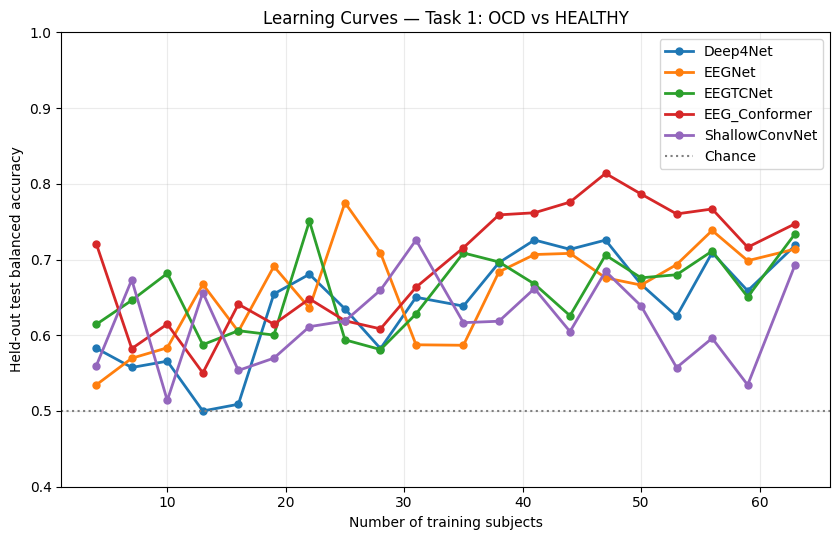

  Saved comparison plot: learning_curves_task1_OCD_vs_HEALTHY.png
  Saved task results: learning_curve_results_task1.csv

STARTING TASK 2
Task 2: MDD vs HEALTHY
  Data shape: (31112, 26, 500)
  Subjects: total=260, train_pool=195, test=65
  Fixed test split: class 0=53, class 1=12
  Training-subject counts: [4, 14, 24, 34, 44, 54, 64, 74, 84, 94, 104, 114, 124, 134, 144, 154, 164, 174, 184, 195]

Task 2: MDD vs HEALTHY | Model: Deep4Net
  Fixed test set: 65 subjects, 7791 trials
  train_subjects=  4 | skipped (only one class present)
      Early stop @ epoch 17  (best epoch 3  bal_acc=0.6201)
  train_subjects= 14 | train_trials=1674 | test_bal_acc=0.6201
      Early stop @ epoch 17  (best epoch 1  bal_acc=0.5000)
  train_subjects= 24 | train_trials=2872 | test_bal_acc=0.5000
      Early stop @ epoch 17  (best epoch 1  bal_acc=0.5000)
  train_subjects= 34 | train_trials=4070 | test_bal_acc=0.5000
      Early stop @ epoch 17  (best epoch 3  bal_acc=0.5474)
  train_subjects= 44 | train_tr

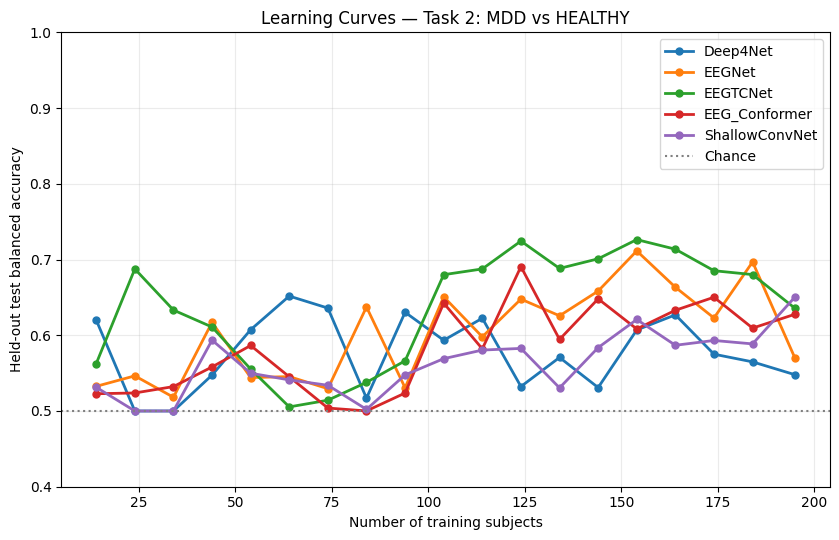

  Saved comparison plot: learning_curves_task2_MDD_vs_HEALTHY.png
  Saved task results: learning_curve_results_task2.csv

STARTING TASK 3
Task 3: ADHD vs HEALTHY
  Data shape: (28503, 26, 500)
  Subjects: total=238, train_pool=178, test=60
  Fixed test split: class 0=48, class 1=12
  Training-subject counts: [4, 13, 22, 31, 40, 49, 58, 68, 77, 86, 95, 104, 113, 123, 132, 141, 150, 159, 168, 178]

Task 3: ADHD vs HEALTHY | Model: Deep4Net
  Fixed test set: 60 subjects, 7188 trials
  train_subjects=  4 | skipped (only one class present)
      Early stop @ epoch 17  (best epoch 1  bal_acc=0.5132)
  train_subjects= 13 | train_trials=1557 | test_bal_acc=0.5132
      Early stop @ epoch 17  (best epoch 4  bal_acc=0.5210)
  train_subjects= 22 | train_trials=2635 | test_bal_acc=0.5210
      Early stop @ epoch 17  (best epoch 2  bal_acc=0.6192)
  train_subjects= 31 | train_trials=3714 | test_bal_acc=0.6192
      Early stop @ epoch 17  (best epoch 1  bal_acc=0.6322)
  train_subjects= 40 | train_t

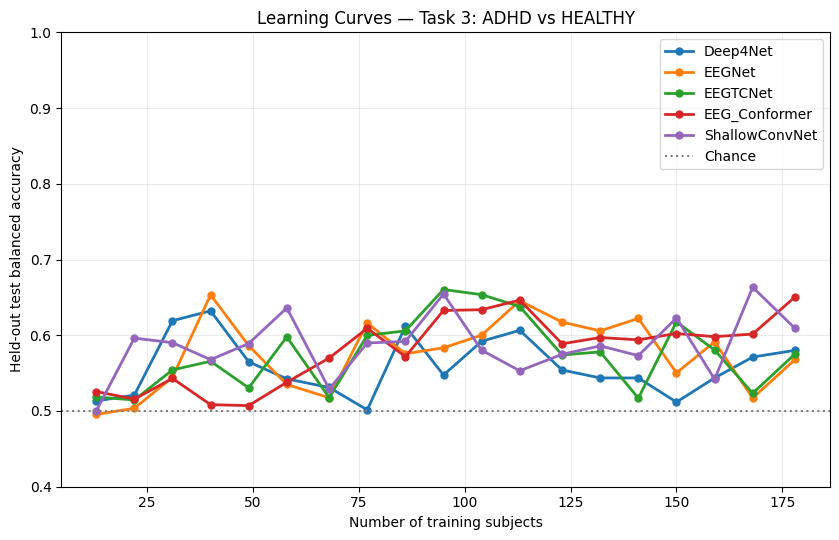

  Saved comparison plot: learning_curves_task3_ADHD_vs_HEALTHY.png
  Saved task results: learning_curve_results_task3.csv

STARTING TASK 4
Task 4: OCD vs MDD
  Data shape: (30016, 26, 500)
  Subjects: total=251, train_pool=188, test=63
  Fixed test split: class 0=10, class 1=53
  Training-subject counts: [4, 13, 23, 33, 42, 52, 62, 71, 81, 91, 100, 110, 120, 129, 139, 149, 158, 168, 178, 188]

Task 4: OCD vs MDD | Model: Deep4Net
  Fixed test set: 63 subjects, 7514 trials
      Early stop @ epoch 17  (best epoch 5  bal_acc=0.4963)
  train_subjects=  4 | train_trials= 478 | test_bal_acc=0.4963
      Early stop @ epoch 17  (best epoch 2  bal_acc=0.5000)
  train_subjects= 13 | train_trials=1556 | test_bal_acc=0.5000
      Early stop @ epoch 17  (best epoch 5  bal_acc=0.5454)
  train_subjects= 23 | train_trials=2754 | test_bal_acc=0.5454
      Early stop @ epoch 17  (best epoch 5  bal_acc=0.5346)
  train_subjects= 33 | train_trials=3950 | test_bal_acc=0.5346
      Early stop @ epoch 17  (b

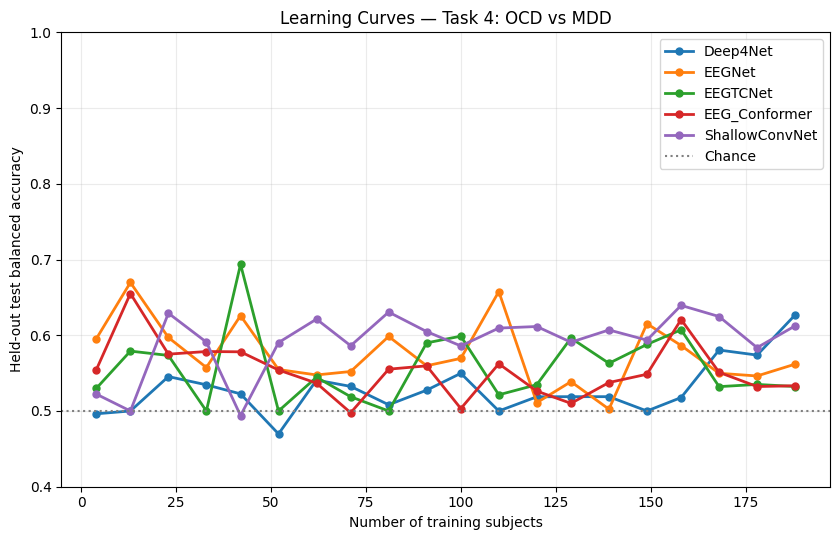

  Saved comparison plot: learning_curves_task4_OCD_vs_MDD.png
  Saved task results: learning_curve_results_task4.csv

COMPLETE
Saved all learning-curve rows: learning_curve_results_all_tasks_all_models.csv
Saved final-point summary:    learning_curve_final_points_summary.csv

Best final balanced-accuracy result per task:
  Task 1 | OCD vs HEALTHY | EEG_Conformer | N=63 | balanced_acc=0.7472
  Task 2 | MDD vs HEALTHY | ShallowConvNet | N=195 | balanced_acc=0.6506
  Task 3 | ADHD vs HEALTHY | EEG_Conformer | N=178 | balanced_acc=0.6506
  Task 4 | OCD vs MDD | Deep4Net | N=188 | balanced_acc=0.6268


,task_id,comparison,model,train_subjects,train_trials,test_subjects,balanced_acc,accuracy,f1,auc
0,1,OCD vs HEALTHY,Deep4Net,4,479,22,0.582904,NaN,NaN,NaN
1,1,OCD vs HEALTHY,Deep4Net,7,837,22,0.557437,NaN,NaN,NaN
2,1,OCD vs HEALTHY,Deep4Net,10,1196,22,0.565784,NaN,NaN,NaN
3,1,OCD vs HEALTHY,Deep4Net,13,1554,22,0.500000,NaN,NaN,NaN
4,1,OCD vs HEALTHY,Deep4Net,16,1913,22,0.508887,NaN,NaN,NaN
5,1,OCD vs HEALTHY,Deep4Net,19,2272,22,0.654553,NaN,NaN,NaN
6,1,OCD vs HEALTHY,Deep4Net,22,2631,22,0.680570,NaN,NaN,NaN
7,1,OCD vs HEALTHY,Deep4Net,25,2990,22,0.634855,NaN,NaN,NaN
8,1,OCD vs HEALTHY,Deep4Net,28,3349,22,0.582429,NaN,NaN,NaN
9,1,OCD vs HEALTHY,Deep4Net,31,3709,22,0.650168,NaN,NaN,NaN


In [ ]:
# @title Learning curves - multiple tasks and models
# Self-contained: loads each task cache, holds out a FIXED subject-level
# test set per task, trains each selected model on increasing numbers of
# training subjects, and plots balanced accuracy vs. training-subject count.
#
# Dependencies expected from earlier notebook cells:
#   TASK_CATEGORIES, NPZ_CACHE_DIR, OUTPUT_PATH, DEVICE
#   build_model(model_name, n_ch, n_t)
#   train_one_fold(model, Xtr, ytr, Xte, yte, criterion, max_epochs, patience)

import os
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# -------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------

LC_TASK_IDS = [1, 2, 3, 4]

LC_MODELS = [
    'Deep4Net',
    'EEGNet',
    'EEGTCNet',
    'EEG_Conformer',
    'ShallowConvNet',
]

LC_TEST_FRAC = 0.25       # Fraction of subjects held out per task
LC_STEPS = 20             # Requested points along each learning curve
LC_SEED = 42              # Fixed split/order seed
LC_MAX_EPOCHS = 60
LC_PATIENCE = 8

# Optional:
# Set True to generate individual task-model figure files in addition
# to the combined per-task comparison figure.
LC_SAVE_INDIVIDUAL_PLOTS = False

# If training many models/tasks is expensive, use a smaller temporary setting:
# LC_STEPS = 10
# LC_MAX_EPOCHS = 40


# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------

def _safe_filename(text):
    """Return a filesystem-friendly representation of a model name."""
    return (
        str(text)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
    )


def _load_task_cache(task_id):
    """
    Load cached EEG data for one binary task.

    Returns:
        X    : trials, channels, timepoints
        y    : binary labels, 0 for first category and 1 for second category
        sid  : subject identifier per trial
        ca   : first category name
        cb   : second category name
    """
    ca, cb = TASK_CATEGORIES[task_id]

    def _load(category):
        path = os.path.join(NPZ_CACHE_DIR, f"{category}_cache.npz")
        z = np.load(path, allow_pickle=True)

        Xcat = z["X"].astype("float32")
        scat = np.array([
            f"{category}_{subject}"
            for subject in z["subject_ids"].astype(str)
        ])
        return Xcat, scat

    Xa, sa = _load(ca)
    Xb, sb = _load(cb)

    X = np.concatenate([Xa, Xb], axis=0)
    y = np.concatenate([
        np.zeros(len(Xa), dtype=int),
        np.ones(len(Xb), dtype=int),
    ])
    sid = np.concatenate([sa, sb])

    return X, y, sid, ca, cb


def _subject_labels(sid, y):
    """
    Map each subject ID to its class label.

    This assumes each subject belongs to one category/class, which is
    consistent with category-prefixed subject IDs in _load_task_cache().
    """
    labels = {}
    for subject_id, label in zip(sid, y):
        if subject_id not in labels:
            labels[subject_id] = int(label)
    return labels


def _make_subject_split_and_order(sid, y, test_frac, seed):
    """
    Create a stratified subject-level fixed test split.

    Returns:
        test_subjects: set of held-out subject IDs
        train_pool   : randomized training subjects; prefixes define N points
        subject_info : counts useful for reporting
    """
    subject_to_label = _subject_labels(sid, y)
    subjects = np.array(sorted(subject_to_label.keys()))
    rng = np.random.RandomState(seed)

    test_subjects = []

    for class_id in (0, 1):
        class_subjects = np.array([
            s for s in subjects
            if subject_to_label[s] == class_id
        ])
        rng.shuffle(class_subjects)

        # At least one test subject from each class, but do not consume
        # all subjects if there are multiple available.
        n_test = max(1, int(round(len(class_subjects) * test_frac)))
        if len(class_subjects) > 1:
            n_test = min(n_test, len(class_subjects) - 1)

        test_subjects.extend(class_subjects[:n_test])

    test_subjects = set(test_subjects)

    train_pool = np.array([
        subject for subject in subjects
        if subject not in test_subjects
    ])
    rng.shuffle(train_pool)

    info = {
        "n_subjects_total": len(subjects),
        "n_subjects_test": len(test_subjects),
        "n_subjects_train_pool": len(train_pool),
        "n_test_class0": sum(subject_to_label[s] == 0 for s in test_subjects),
        "n_test_class1": sum(subject_to_label[s] == 1 for s in test_subjects),
    }

    return test_subjects, train_pool, info


def _make_training_counts(train_pool, steps):
    """
    Generate increasing training-subject counts.

    Starts at a minimum of four subjects when possible and finishes at
    the complete non-test training pool.
    """
    n_pool = len(train_pool)

    if n_pool < 2:
        return np.array([], dtype=int)

    min_subjects = min(4, n_pool)

    counts = np.unique(
        np.linspace(min_subjects, n_pool, min(steps, n_pool)).astype(int)
    )

    # Ensure the full training pool is always included.
    if counts[-1] != n_pool:
        counts = np.append(counts, n_pool)

    return counts


def _class_weights(y_train):
    """Create balanced CrossEntropyLoss weights from the current training set."""
    n_total = len(y_train)
    n_class0 = max(1, int((y_train == 0).sum()))
    n_class1 = max(1, int((y_train == 1).sum()))

    weights = torch.tensor(
        [
            n_total / (2 * n_class0),
            n_total / (2 * n_class1),
        ],
        dtype=torch.float32,
        device=DEVICE,
    )
    return weights


def _clear_memory():
    """Release Python and CUDA memory between individual model fits."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# -------------------------------------------------------------------
# One model's learning curve for one task
# -------------------------------------------------------------------

def _run_model_learning_curve(
    task_id,
    model_name,
    X,
    y,
    sid,
    test_subjects,
    train_pool,
    counts,
    category_a,
    category_b,
):
    """
    Train one model at increasing training-subject counts.

    The test_subjects and train_pool are supplied by the caller so every
    model in the same task uses identical held-out data and identical
    subject-addition order.
    """
    n_channels, n_times = X.shape[1], X.shape[2]

    test_mask = np.array([subject_id in test_subjects for subject_id in sid])
    X_test = X[test_mask]
    y_test = y[test_mask]

    rows = []

    print(f"\nTask {task_id}: {category_a} vs {category_b} | Model: {model_name}")
    print(
        f"  Fixed test set: {len(test_subjects)} subjects, "
        f"{len(y_test)} trials"
    )

    for n_subjects in counts:
        current_train_subjects = set(train_pool[:n_subjects])
        train_mask = np.array([
            subject_id in current_train_subjects
            for subject_id in sid
        ])

        X_train = X[train_mask]
        y_train = y[train_mask]

        # A valid binary training subset requires both classes.
        if len(np.unique(y_train)) < 2:
            print(
                f"  train_subjects={n_subjects:3d} | skipped "
                f"(only one class present)"
            )
            continue

        criterion = nn.CrossEntropyLoss(weight=_class_weights(y_train))
        model = None

        try:
            model = build_model(model_name, n_channels, n_times)

            metrics, _, _ = train_one_fold(
                model,
                X_train,
                y_train,
                X_test,
                y_test,
                criterion,
                max_epochs=LC_MAX_EPOCHS,
                patience=LC_PATIENCE,
            )

            balanced_acc = metrics.get("balanced_acc", float("nan"))
            accuracy = metrics.get("accuracy", float("nan"))
            f1 = metrics.get("f1", float("nan"))
            auc = metrics.get("auc", float("nan"))

            row = {
                "task_id": task_id,
                "category_a": category_a,
                "category_b": category_b,
                "comparison": f"{category_a} vs {category_b}",
                "model": model_name,
                "train_subjects": int(n_subjects),
                "train_trials": int(len(y_train)),
                "test_subjects": int(len(test_subjects)),
                "test_trials": int(len(y_test)),
                "balanced_acc": balanced_acc,
                "accuracy": accuracy,
                "f1": f1,
                "auc": auc,
                "seed": LC_SEED,
                "test_fraction": LC_TEST_FRAC,
            }
            rows.append(row)

            print(
                f"  train_subjects={n_subjects:3d} | "
                f"train_trials={len(y_train):4d} | "
                f"test_bal_acc={balanced_acc:.4f}"
            )

        except Exception as e:
            print(
                f"  train_subjects={n_subjects:3d} | "
                f"FAILED for {model_name}: {e}"
            )

        finally:
            if model is not None:
                del model
            _clear_memory()

    return rows


# -------------------------------------------------------------------
# Plotting
# -------------------------------------------------------------------

def _plot_task_learning_curves(task_id, task_results, category_a, category_b):
    """
    Plot all successful models for a task on one comparable figure.
    """
    if task_results.empty:
        print(f"No successful learning-curve results for Task {task_id}.")
        return None

    plt.figure(figsize=(8.5, 5.5))

    for model_name in LC_MODELS:
        subset = task_results[task_results["model"] == model_name]
        if subset.empty:
            continue

        subset = subset.sort_values("train_subjects")
        plt.plot(
            subset["train_subjects"],
            subset["balanced_acc"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=model_name,
        )

    plt.axhline(
        0.5,
        linestyle=":",
        color="gray",
        linewidth=1.5,
        label="Chance",
    )

    plt.xlabel("Number of training subjects")
    plt.ylabel("Held-out test balanced accuracy")
    plt.title(
        f"Learning Curves — Task {task_id}: "
        f"{category_a} vs {category_b}"
    )
    plt.ylim(0.4, 1.0)
    plt.grid(alpha=0.25)
    plt.legend(loc="best", frameon=True)
    plt.tight_layout()

    filename = (
        f"learning_curves_task{task_id}_"
        f"{_safe_filename(category_a)}_vs_{_safe_filename(category_b)}.png"
    )
    output_file = os.path.join(OUTPUT_PATH, filename)

    plt.savefig(output_file, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"  Saved comparison plot: {os.path.basename(output_file)}")
    return output_file


def _plot_individual_learning_curve(task_id, model_name, model_results, category_a, category_b):
    """Optional plot: one task/model figure."""
    if model_results.empty:
        return None

    model_results = model_results.sort_values("train_subjects")

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(
        model_results["train_subjects"],
        model_results["balanced_acc"],
        "o-",
        linewidth=2,
        label=model_name,
    )
    plt.axhline(0.5, linestyle=":", color="gray", label="Chance")
    plt.xlabel("Number of training subjects")
    plt.ylabel("Held-out test balanced accuracy")
    plt.title(
        f"Task {task_id}: {category_a} vs {category_b}\n"
        f"{model_name}"
    )
    plt.ylim(0.4, 1.0)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()

    filename = (
        f"learning_curve_task{task_id}_"
        f"{_safe_filename(model_name)}.png"
    )
    output_file = os.path.join(OUTPUT_PATH, filename)

    plt.savefig(output_file, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

    return output_file


# -------------------------------------------------------------------
# Main multi-task / multi-model runner
# -------------------------------------------------------------------

def run_multi_task_learning_curves():
    """
    Run all requested task/model learning curves and save one CSV table.

    Returns:
        results_df: Long-form pandas DataFrame, one row per:
                    task x model x training-subject count.
    """
    os.makedirs(OUTPUT_PATH, exist_ok=True)

    all_rows = []

    print("=" * 80)
    print("MULTI-TASK / MULTI-MODEL LEARNING CURVES")
    print(f"Tasks:  {LC_TASK_IDS}")
    print(f"Models: {LC_MODELS}")
    print(
        f"Test fraction={LC_TEST_FRAC}, steps={LC_STEPS}, "
        f"seed={LC_SEED}, max_epochs={LC_MAX_EPOCHS}, "
        f"patience={LC_PATIENCE}"
    )
    print("=" * 80)

    for task_id in LC_TASK_IDS:
        print("\n" + "=" * 80)
        print(f"STARTING TASK {task_id}")
        print("=" * 80)

        try:
            X, y, sid, category_a, category_b = _load_task_cache(task_id)

            test_subjects, train_pool, split_info = _make_subject_split_and_order(
                sid=sid,
                y=y,
                test_frac=LC_TEST_FRAC,
                seed=LC_SEED + task_id,
            )

            counts = _make_training_counts(train_pool, LC_STEPS)

            if len(counts) == 0:
                print(
                    f"Task {task_id} skipped: fewer than two available "
                    f"training subjects after test split."
                )
                continue

            print(
                f"Task {task_id}: {category_a} vs {category_b}\n"
                f"  Data shape: {X.shape}\n"
                f"  Subjects: total={split_info['n_subjects_total']}, "
                f"train_pool={split_info['n_subjects_train_pool']}, "
                f"test={split_info['n_subjects_test']}\n"
                f"  Fixed test split: class 0={split_info['n_test_class0']}, "
                f"class 1={split_info['n_test_class1']}\n"
                f"  Training-subject counts: {counts.tolist()}"
            )

            task_rows = []

            for model_name in LC_MODELS:
                model_rows = _run_model_learning_curve(
                    task_id=task_id,
                    model_name=model_name,
                    X=X,
                    y=y,
                    sid=sid,
                    test_subjects=test_subjects,
                    train_pool=train_pool,
                    counts=counts,
                    category_a=category_a,
                    category_b=category_b,
                )

                task_rows.extend(model_rows)
                all_rows.extend(model_rows)

                if LC_SAVE_INDIVIDUAL_PLOTS and model_rows:
                    model_df = pd.DataFrame(model_rows)
                    _plot_individual_learning_curve(
                        task_id=task_id,
                        model_name=model_name,
                        model_results=model_df,
                        category_a=category_a,
                        category_b=category_b,
                    )

            if task_rows:
                task_df = pd.DataFrame(task_rows)

                _plot_task_learning_curves(
                    task_id=task_id,
                    task_results=task_df,
                    category_a=category_a,
                    category_b=category_b,
                )

                # Save a task-specific CSV as well.
                task_csv = os.path.join(
                    OUTPUT_PATH,
                    f"learning_curve_results_task{task_id}.csv",
                )
                task_df.to_csv(task_csv, index=False)
                print(f"  Saved task results: {os.path.basename(task_csv)}")

            # Release the task data before moving to the next task.
            del X, y, sid
            _clear_memory()

        except KeyError:
            print(
                f"Task {task_id} skipped: TASK_CATEGORIES does not contain "
                f"an entry for this task ID."
            )
        except FileNotFoundError as e:
            print(f"Task {task_id} skipped: cache file not found: {e}")
        except Exception as e:
            print(f"Task {task_id} failed: {type(e).__name__}: {e}")
            _clear_memory()

    # Consolidated CSV across all tasks and models.
    results_df = pd.DataFrame(all_rows)

    if results_df.empty:
        print("\nNo learning-curve results were generated.")
        return results_df

    results_df = results_df.sort_values(
        ["task_id", "model", "train_subjects"]
    ).reset_index(drop=True)

    all_csv = os.path.join(
        OUTPUT_PATH,
        "learning_curve_results_all_tasks_all_models.csv",
    )
    results_df.to_csv(all_csv, index=False)

    # Summary based on the largest available training subset per task/model.
    final_points = (
        results_df
        .sort_values("train_subjects")
        .groupby(["task_id", "comparison", "model"], as_index=False)
        .tail(1)
        .sort_values(["task_id", "balanced_acc"], ascending=[True, False])
    )

    summary_csv = os.path.join(
        OUTPUT_PATH,
        "learning_curve_final_points_summary.csv",
    )
    final_points.to_csv(summary_csv, index=False)

    print("\n" + "=" * 80)
    print("COMPLETE")
    print(f"Saved all learning-curve rows: {os.path.basename(all_csv)}")
    print(f"Saved final-point summary:    {os.path.basename(summary_csv)}")
    print("\nBest final balanced-accuracy result per task:")

    for task_id, group in final_points.groupby("task_id"):
        best = group.iloc[0]
        print(
            f"  Task {task_id} | {best['comparison']} | "
            f"{best['model']} | "
            f"N={int(best['train_subjects'])} | "
            f"balanced_acc={best['balanced_acc']:.4f}"
        )

    return results_df


# -------------------------------------------------------------------
# Run
# -------------------------------------------------------------------

try:
    learning_curve_results = run_multi_task_learning_curves()

    # Optional notebook view:
    display(
        learning_curve_results[
            [
                "task_id",
                "comparison",
                "model",
                "train_subjects",
                "train_trials",
                "test_subjects",
                "balanced_acc",
                "accuracy",
                "f1",
                "auc",
            ]
        ].head(20)
    )

except NameError as e:
    print(
        f"Missing dependency in scope ({e}). "
        f"Run Config + Pipeline Functions first."
    )
except Exception as e:
    print(f"Multi-task learning curve run failed: {type(e).__name__}: {e}")

## Cell 9: Save Updated Modules Back to Google Drive
Run after any module updates to persist changes for future sessions.

In [ ]:
loso = df[df['eval_type'] == 'loso'].groupby('task_id')[['balanced_accuracy','roc_auc']].mean().round(3)
print(loso.to_string())

In [ ]:
import pandas as pd, os
df = pd.read_csv(os.path.join(OUTPUT_PATH, 'all_results.csv'))
print(df.columns.tolist())
print(df.head(2))

In [ ]:
import os
files = os.listdir(OUTPUT_PATH)
loso_files = [f for f in files if 'loso' in f.lower()]
print(loso_files)

In [ ]:
# =============================================================================
# Cell 9: Save updated modules back to Google Drive Colab Notebooks folder
# Run this after any module edits to persist changes for future sessions.
# =============================================================================

modules_to_save = [
    # Add other modules here if you edited them:
    # 'eeg_braindecode_improved.py',
    # 'train_all_models_enhanced.py',
]

print("Saving updated modules to Google Drive...")
copy_modules_to_gdrive_colab_path(GDRIVE_COLAB_PATH, modules_to_save)
print("\nœ Modules saved. Future sessions will load the latest versions.")
print(f"\nLocation: {GDRIVE_COLAB_PATH}")

In [ ]:
import os
print("OUTPUT_PATH =", OUTPUT_PATH)
print("\nFiles saved:")
for f in sorted(os.listdir(OUTPUT_PATH)):
    print(" ", f)

In [ ]:
import pandas as pd, os

# Redefine OUTPUT_PATH for standalone execution
GDRIVE_PATH = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/'
OUTPUT_PATH = GDRIVE_PATH + 'EEG_Analysis_Output/'

# Main results
df = pd.read_csv(os.path.join(OUTPUT_PATH, 'all_results.csv'))
print(df.to_string())

print("\n--- TASK 1 ---")
print(pd.read_csv(os.path.join(OUTPUT_PATH, 'task1_model_comparison.csv')).to_string())

print("\n--- TASK 2 ---")
print(pd.read_csv(os.path.join(OUTPUT_PATH, 'task2_model_comparison.csv')).to_string())

print("\n--- TASK 3 ---")
print(pd.read_csv(os.path.join(OUTPUT_PATH, 'task3_model_comparison.csv')).to_string())

In [ ]:
import shutil, os

GDRIVE_PATH         = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/'
GDRIVE_OUTPUT_PATH  = GDRIVE_PATH + 'EEG_Analysis_Output/'
OUTPUT_PATH         = GDRIVE_OUTPUT_PATH

dest = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/00_Final_Results/run_2026_08_21'
os.makedirs(dest, exist_ok=True)

copied = 0
for f in os.listdir(OUTPUT_PATH):
    src = os.path.join(OUTPUT_PATH, f)
    # Skip .gsheet files as they are Google Drive shortcuts and cannot be copied directly
    if os.path.isfile(src) and not f.endswith('.gsheet'):
        shutil.copy2(src, dest)
        print(f"Copied: {f}")
        copied += 1
    elif f.endswith('.gsheet'):
        print(f"Skipped Google Sheet shortcut: {f}")

print(f"\nTotal copied: {copied} files")
print(f"Dest path: {dest}")


Total copied: 0 files
Dest path: /content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/00_Final_Results/run_2026_08_21


In [ ]:
import os
folder = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/00_Final_Results/run_2026_08_21'
print(os.listdir(folder))

[]


In [ ]:
import os
dest = '/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/00_Final_Results/run_2026_08_21'
print(os.listdir(dest))

[]


In [ ]:
from braindecode.models import EEGConformer
import torch
model = EEGConformer(n_chans=26, n_outputs=2, n_times=500)
total = sum(p.numel() for p in model.parameters())
print(f'EEG-Conformer parameters: {total:,}')

ModuleNotFoundError: No module named 'braindecode'

In [ ]:
import pandas as pd
df = pd.read_csv('/content/gdrive/MyDrive/01_Research/01_Neuro_EEG/EEG_Analysis_Output/)
print(df.to_string())

In [ ]:
import glob, os
files = sorted(glob.glob('/content/executed_notebooks/*'))
print(files)
for f in files:
    if os.path.isfile(f):
        print(f"\n{'='*50}\n{f}")
        with open(f) as fh:
            print(fh.read()[-4000:])